# 🗓️ ENSIA Timetable Generation Pipeline

**Full pipeline in one notebook:**
1. **Data Loading** — load rooms, sessions, sections, groups, context
2. **CSP Solver** — backtracking search with MRV + LCV + Forward Checking
3. **CSP Validation** — verify zero hard-constraint violations
4. **CSP Visualizer** — interactive timetable grid
5. **SA Optimizer** — Simulated Annealing soft-cost optimisation
6. **SA Validation** — verify hard constraints still hold
7. **SA Visualizer** — timetable grid after SA
8. **Hill Climbing Optimizer** — Randomised-Restart Hill Climbing
9. **HC Validation** — verify hard constraints still hold
10. **HC Visualizer** — timetable grid after Hill Climbing
11. **Three-Way Comparison** — soft cost comparison across all three outputs

> **Data files expected in the same directory as this notebook:**  
> `sessions.json`, `rooms.json`, `sections.json`, `groups.json`, `context.json`

---
## 📦 Cell 1 — Imports & Configuration

In [29]:
from __future__ import annotations

# ── Standard library ──────────────────────────────────────────────────────────
import json
import math
import random
import time
import copy
from collections import defaultdict, deque
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
import matplotlib.gridspec as gridspec
import numpy as np

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# ── File paths ────────────────────────────────────────────────────────────────
SESSIONS_PATH  = "sessions.json"
ROOMS_PATH     = "rooms.json"
SECTIONS_PATH  = "sections.json"
GROUPS_PATH    = "groups.json"
CONTEXT_PATH   = "context.json"

CSP_OUTPUT     = "schedule_output.json"
SA_OUTPUT      = "schedule_sa_output.json"
HC_OUTPUT      = "hc_schedule_output.json"

# ── Day / period labels ───────────────────────────────────────────────────────
DAY_NAMES    = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday"]
PERIOD_TIMES = ["08:00", "09:30", "11:00", "13:00", "14:30", "16:00"]

print("✅ Imports complete.")

✅ Imports complete.


---
## 🗄️ Cell 2 — Data Loader (data_loader.py)

In [30]:
# ═══════════════════════════════════════════════════════════════════════
#  DATA LOADER  (from data_loader.py)
# ═══════════════════════════════════════════════════════════════════════

@dataclass
class Room:
    room_id: str
    capacity: int
    room_type: str
    building: Optional[str] = None
    floor: Optional[str] = None
    room_number: Optional[str] = None
    location: Optional[str] = None

    def __repr__(self):
        return f"Room({self.room_id!r}, {self.room_type}, cap={self.capacity})"


@dataclass
class Section:
    section_id: str
    cohort_id: str
    n_students: int

    def __repr__(self):
        return f"Section({self.section_id!r}, cohort={self.cohort_id}, n={self.n_students})"


@dataclass
class Group:
    group_id: str
    section_id: str
    n_students: int

    def __repr__(self):
        return f"Group({self.group_id!r}, section={self.section_id}, n={self.n_students})"


@dataclass
class Session:
    session_id: str
    module_id: str
    module_name: str
    teacher_id: str
    session_type: str
    section_id: str
    group_id: Optional[str]
    required_room_type: str
    allowed_rooms: list
    min_working_days: int
    duration_slots: int = 1

    def __repr__(self):
        audience = self.group_id if self.group_id else self.section_id
        return f"Session({self.session_id!r}, {self.session_type}, audience={audience!r})"


@dataclass
class TimeSlot:
    day: int
    period: int
    day_name: str
    start_time: str
    end_time: str
    session_duration: int
    break_duration: int

    def as_tuple(self):
        return (self.day, self.period)


@dataclass
class TimetableContext:
    days: int
    periods_per_day: int
    forbidden_set: set
    preferred_set: set
    section_of: dict
    group_of: dict
    teacher_schedule: dict
    teacher_off_days: dict
    teacher_preferences: dict
    valid_slots: list
    room_map: dict
    section_map: dict
    group_map: dict
    session_map: dict
    timeslot_map: dict

    def is_forbidden(self, session_id, day, period):
        return (session_id, day, period) in self.forbidden_set

    def is_preferred(self, session_id, day, period):
        return (session_id, day, period) in self.preferred_set

    def get_room(self, room_id):
        return self.room_map[room_id]

    def get_section(self, section_id):
        return self.section_map[section_id]

    def get_group(self, group_id):
        return self.group_map[group_id]

    def get_session(self, session_id):
        return self.session_map[session_id]

    def get_timeslot(self, day, period):
        return self.timeslot_map.get((day, period))

    def get_n_students(self, session):
        if session.group_id:
            grp = self.group_map.get(session.group_id)
            if grp is None:
                raise KeyError(f"Group not found: {session.group_id}")
            return grp.n_students
        else:
            sec = self.section_map.get(session.section_id)
            if sec is None:
                raise KeyError(f"Section not found: {session.section_id}")
            return sec.n_students

    def summary(self):
        return (
            f"TimetableContext: {self.days}d × {self.periods_per_day}p, "
            f"{len(self.session_map)} sessions, "
            f"{len(self.room_map)} rooms, "
            f"{len(self.section_map)} sections, "
            f"{len(self.group_map)} groups"
        )


# ── Loaders ───────────────────────────────────────────────────────────

def _load_rooms(path):
    with open(path, encoding="utf-8") as f:
        raw = json.load(f)
    return [
        Room(
            room_id=r["room_id"], capacity=r["capacity"],
            room_type=r["room_type"], building=r.get("building"),
            floor=r.get("floor"), room_number=r.get("room_number"),
            location=r.get("location"),
        ) for r in raw
    ]

def _load_sections(path):
    with open(path, encoding="utf-8") as f:
        raw = json.load(f)
    return [Section(section_id=s["section_id"], cohort_id=s["cohort_id"],
                    n_students=s["n_students"]) for s in raw]

def _load_groups(path):
    with open(path, encoding="utf-8") as f:
        raw = json.load(f)
    return [Group(group_id=g["group_id"], section_id=g["section_id"],
                  n_students=g["n_students"]) for g in raw]

def _load_sessions(path):
    with open(path, encoding="utf-8") as f:
        raw = json.load(f)
    return [
        Session(
            session_id=s["session_id"], module_id=s["module_id"],
            module_name=s["module_name"], teacher_id=s["teacher_id"],
            session_type=s["session_type"], section_id=s["section_id"],
            group_id=s.get("group_id"), required_room_type=s["required_room_type"],
            allowed_rooms=s.get("allowed_rooms", []),
            min_working_days=s["min_working_days"],
            duration_slots=s.get("duration_slots", 1),
        ) for s in raw
    ]

def _load_context(path, rooms, sections, groups, sessions):
    with open(path, encoding="utf-8") as f:
        raw = json.load(f)

    forbidden_set = {(e[0], e[1], e[2]) for e in raw["forbidden"]}
    preferred_set = {(e[0], e[1], e[2]) for e in raw["preferred"]}
    section_of    = dict(raw["section_of"])
    group_of      = dict(raw["group_of"])
    teacher_schedule = {
        tid: [tuple(slot) for slot in slots]
        for tid, slots in raw["teacher_schedule"].items()
    }
    teacher_off_days    = dict(raw["teacher_off_days"])
    teacher_preferences = dict(raw["teacher_preferences"])
    valid_slots = [(slot[0], slot[1]) for slot in raw["valid_slots"]]

    timeslot_map = {}
    for ts in raw["timeslots"]:
        key = (ts["day"], ts["period"])
        timeslot_map[key] = TimeSlot(
            day=ts["day"], period=ts["period"], day_name=ts["day_name"],
            start_time=ts["start_time"], end_time=ts["end_time"],
            session_duration=ts["session_duration"], break_duration=ts["break_duration"],
        )

    return TimetableContext(
        days=raw["days"], periods_per_day=raw["periods_per_day"],
        forbidden_set=forbidden_set, preferred_set=preferred_set,
        section_of=section_of, group_of=group_of,
        teacher_schedule=teacher_schedule, teacher_off_days=teacher_off_days,
        teacher_preferences=teacher_preferences, valid_slots=valid_slots,
        room_map={r.room_id: r for r in rooms},
        section_map={s.section_id: s for s in sections},
        group_map={g.group_id: g for g in groups},
        session_map={s.session_id: s for s in sessions},
        timeslot_map=timeslot_map,
    )


def load_timetable_data(
    sessions_path=SESSIONS_PATH, rooms_path=ROOMS_PATH,
    sections_path=SECTIONS_PATH, groups_path=GROUPS_PATH,
    context_path=CONTEXT_PATH,
):
    """Load all five dataset files and return ready-to-use objects."""
    for p in [sessions_path, rooms_path, sections_path, groups_path, context_path]:
        if not Path(p).exists():
            raise FileNotFoundError(f"Dataset file not found: {Path(p).resolve()}")
    rooms    = _load_rooms(rooms_path)
    sections = _load_sections(sections_path)
    groups   = _load_groups(groups_path)
    sessions = _load_sessions(sessions_path)
    context  = _load_context(context_path, rooms, sections, groups, sessions)
    return sessions, rooms, sections, groups, context


print("✅ Data loader defined.")

✅ Data loader defined.


---
## 🔢 Cell 3 — Load Data

In [31]:
print("Loading timetable data...")
sessions, rooms, sections, groups, context = load_timetable_data()

print(context.summary())
print(f"\n  Sessions  : {len(sessions)}")
print(f"  Rooms     : {len(rooms)}")
print(f"  Sections  : {len(sections)}")
print(f"  Groups    : {len(groups)}")
print(f"  Days      : {context.days}")
print(f"  Periods   : {context.periods_per_day}")

from collections import Counter
stype = Counter(s.session_type for s in sessions)
rtype = Counter(r.room_type for r in rooms)
print(f"\n  Session types : {dict(stype)}")
print(f"  Room types    : {dict(rtype)}")
print("\n✅ Data loaded successfully.")

Loading timetable data...
TimetableContext: 5d × 6p, 459 sessions, 34 rooms, 8 sections, 41 groups

  Sessions  : 459
  Rooms     : 34
  Sections  : 8
  Groups    : 41
  Days      : 5
  Periods   : 6

  Session types : {'lecture': 62, 'tuto': 203, 'lab': 194}
  Room types    : {'amphi': 8, 'lab': 15, 'tuto': 11}

✅ Data loaded successfully.


---
## 🧩 Cell 4 — Soft Constraints (soft_constraints.py)

In [32]:
# ═══════════════════════════════════════════════════════════════════════
#  SOFT CONSTRAINTS  (from soft_constraints.py)
# ═══════════════════════════════════════════════════════════════════════

AFTERNOON_START      = 3
INTER_BUILDING_DIST  = 10
ALPHA_CAPACITY_WASTE = 0.05
ALPHA_ROOM_CHANGE    = 8.0
ALPHA_TRAVEL         = 3.0
ALPHA_COMPACTNESS    = 15.0
ALPHA_TEACHER_PREFERENCE = 10.0


def build_audience_index(context):
    sections = sorted(context.section_map.keys())
    groups   = sorted(context.group_map.keys())
    audience_list = sections + groups
    audience_idx  = {a: i for i, a in enumerate(audience_list)}
    return audience_list, audience_idx


def _iter_slots(timetable, context, num_audiences):
    for d in range(context.days):
        for p in range(context.periods_per_day):
            for a in range(num_audiences):
                room_id, session_id = timetable[d][p][a]
                if room_id is not None and session_id is not None:
                    yield d, p, a, room_id, session_id


def _room_distance(room_a, room_b, context):
    if room_a == room_b:
        return 0.0
    ra = context.room_map.get(room_a)
    rb = context.room_map.get(room_b)
    if ra is None or rb is None:
        return 0.0
    if ra.building != rb.building:
        return float(INTER_BUILDING_DIST)
    try:
        return float(abs(int(ra.room_number) - int(rb.room_number)))
    except (TypeError, ValueError):
        return 0.0


def penalty_capacity_waste(timetable, context, num_audiences):
    total = 0.0
    for d, p, a, room_id, sid in _iter_slots(timetable, context, num_audiences):
        room    = context.room_map.get(room_id)
        session = context.session_map.get(sid)
        if room is None or session is None:
            continue
        try:
            n_stud = context.get_n_students(session)
        except (KeyError, ValueError):
            continue
        waste = room.capacity - n_stud
        if waste > 0:
            total += ALPHA_CAPACITY_WASTE * waste
    return total


def penalty_teacher_room_change(timetable, context, num_audiences):
    teacher_rooms = defaultdict(lambda: defaultdict(set))
    for d, p, a, room_id, sid in _iter_slots(timetable, context, num_audiences):
        session = context.session_map.get(sid)
        if session is None:
            continue
        teacher_rooms[session.teacher_id][d].add(room_id)
    total = 0.0
    for teacher, days in teacher_rooms.items():
        for day, rooms_set in days.items():
            if len(rooms_set) > 1:
                total += ALPHA_ROOM_CHANGE * (len(rooms_set) - 1)
    return total


def penalty_travel_distance(timetable, context, num_audiences):
    _, audience_idx_map = build_audience_index(context)
    total = 0.0
    for group_id, group in context.group_map.items():
        g_idx = audience_idx_map[group_id]
        s_idx = audience_idx_map[group.section_id]
        for d in range(context.days):
            busy = []
            for p in range(context.periods_per_day):
                for idx in [g_idx, s_idx]:
                    cell = timetable[d][p][idx]
                    if cell is not None:
                        room_id, _ = cell
                        if room_id is not None:
                            busy.append((p, room_id))
            if len(busy) < 2:
                continue
            busy.sort(key=lambda x: x[0])
            for i in range(len(busy) - 1):
                p_a, room_a = busy[i]
                p_b, room_b = busy[i + 1]
                dist = _room_distance(room_a, room_b, context)
                if dist == 0.0:
                    continue
                gap = p_b - p_a
                total += ALPHA_TRAVEL * dist / gap
    return total


def penalty_curriculum_compactness(timetable, context, num_audiences):
    _, audience_idx_map = build_audience_index(context)
    total = 0.0
    for group_id, group in context.group_map.items():
        g_idx = audience_idx_map[group_id]
        s_idx = audience_idx_map[group.section_id]
        for d in range(context.days):
            busy_periods = []
            for p in range(context.periods_per_day):
                cell_g = timetable[d][p][g_idx]
                cell_s = timetable[d][p][s_idx]
                g_occ  = cell_g is not None and cell_g[0] is not None
                s_occ  = cell_s is not None and cell_s[0] is not None
                if g_occ or s_occ:
                    busy_periods.append(p)
            if not busy_periods:
                continue
            has_morning   = any(p < AFTERNOON_START for p in busy_periods)
            all_afternoon = all(p >= AFTERNOON_START for p in busy_periods)
            if all_afternoon and not has_morning:
                total += ALPHA_COMPACTNESS * 1.0
                continue
            sp = sorted(busy_periods)
            for i in range(len(sp) - 1):
                if sp[i + 1] - sp[i] >= 3:
                    total += ALPHA_COMPACTNESS * 0.5
    return total


def penalty_teacher_preference(timetable, context, num_audiences):
    prefs = getattr(context, 'teacher_preferences', {})
    if not prefs:
        return 0.0
    total = 0.0
    for d, p, a, room_id, sid in _iter_slots(timetable, context, num_audiences):
        session = context.session_map.get(sid)
        if session is None:
            continue
        pref = prefs.get(session.teacher_id)
        if pref is None:
            continue
        is_afternoon = (p >= AFTERNOON_START)
        if pref == 'morning' and is_afternoon:
            total += ALPHA_TEACHER_PREFERENCE
        elif pref == 'afternoon' and not is_afternoon:
            total += ALPHA_TEACHER_PREFERENCE
    return total


def total_soft_cost(timetable, context):
    num_audiences = len(context.section_map) + len(context.group_map)
    return (
        penalty_capacity_waste(timetable, context, num_audiences)
      + penalty_teacher_room_change(timetable, context, num_audiences)
      + penalty_travel_distance(timetable, context, num_audiences)
      + penalty_curriculum_compactness(timetable, context, num_audiences)
      + penalty_teacher_preference(timetable, context, num_audiences)
    )


def soft_cost_breakdown(timetable, context):
    num_audiences = len(context.section_map) + len(context.group_map)
    s1 = penalty_capacity_waste(timetable, context, num_audiences)
    s2 = penalty_teacher_room_change(timetable, context, num_audiences)
    s3 = penalty_travel_distance(timetable, context, num_audiences)
    s4 = penalty_curriculum_compactness(timetable, context, num_audiences)
    s5 = penalty_teacher_preference(timetable, context, num_audiences)
    return {
        'capacity_waste'     : round(s1, 4),
        'teacher_room_change': round(s2, 4),
        'travel_distance'    : round(s3, 4),
        'compactness'        : round(s4, 4),
        'teacher_preference' : round(s5, 4),
        'total'              : round(s1 + s2 + s3 + s4 + s5, 4),
    }


print("✅ Soft constraints defined.")

✅ Soft constraints defined.


---
## 🔍 Cell 5 — Hard Constraint Validator (schedule_validator.py)

In [33]:
# ═══════════════════════════════════════════════════════════════════════
#  HARD CONSTRAINT VALIDATOR  (from schedule_validator.py / sa_validator.py)
# ═══════════════════════════════════════════════════════════════════════

def validate_schedule(schedule_path):
    """Load schedule JSON and verify all four hard constraints."""
    with open(schedule_path, encoding="utf-8") as fh:
        sessions_data = json.load(fh)

    slot_rooms    = defaultdict(list)
    slot_teachers = defaultdict(list)
    slot_sections = defaultdict(list)
    slot_groups   = defaultdict(list)

    for s in sessions_data:
        d   = s["day"]
        p   = s["period"]
        sid = s["session_id"]
        slot_rooms   [(d, p, s["room"])   ].append(sid)
        slot_teachers[(d, p, s["teacher"])].append(sid)
        if s.get("section") and not s.get("group"):
            slot_sections[(d, p, s["section"])].append(sid)
        if s.get("group"):
            slot_groups[(d, p, s["group"])].append(sid)

    def _find_conflicts(index, entity_label):
        conflicts = []
        for (day, period, entity), sids in index.items():
            if len(sids) > 1:
                conflicts.append({
                    "day": day, "period": period,
                    entity_label: entity, "sessions": sids,
                    "n_collisions": len(sids) - 1,
                })
        return conflicts

    violations = {
        "room_double_booking": _find_conflicts(slot_rooms,    "room"),
        "teacher_conflict":    _find_conflicts(slot_teachers, "teacher"),
        "section_conflict":    _find_conflicts(slot_sections, "section"),
        "group_conflict":      _find_conflicts(slot_groups,   "group"),
    }
    total  = sum(len(v) for v in violations.values())
    passed = (total == 0)

    if passed:
        message = (
            f"✅  SCHEDULE VALID\n"
            f"    {len(sessions_data)} sessions checked — no hard constraint violations found."
        )
    else:
        lines = [
            f"❌  SCHEDULE INVALID",
            f"    {total} violation(s) across {len(sessions_data)} sessions:\n",
        ]
        for cname, clist in violations.items():
            label = cname.replace("_", " ").title()
            lines.append(f"  [{len(clist):>3}]  {label:30s}")
            for c in clist[:3]:
                entity_key   = list(c.keys())[2]
                entity_value = list(c.values())[2]
                lines.append(
                    f"         ↳  day={c['day']}, period={c['period']},"
                    f" {entity_key}='{entity_value}'"
                )
        message = "\n".join(lines)

    return dict(
        passed=passed, message=message, violations=violations,
        total_violations=total, sessions_checked=len(sessions_data),
    )


def validate_schedule_rows(rows):
    """Same validator but accepts a list of dicts directly (no file I/O)."""
    slot_rooms    = defaultdict(list)
    slot_teachers = defaultdict(list)
    slot_sections = defaultdict(list)
    slot_groups   = defaultdict(list)

    for s in rows:
        d   = s["day"]; p = s["period"]; sid = s["session_id"]
        slot_rooms   [(d, p, s["room"])   ].append(sid)
        slot_teachers[(d, p, s["teacher"])].append(sid)
        if s.get("section") and not s.get("group"):
            slot_sections[(d, p, s["section"])].append(sid)
        if s.get("group"):
            slot_groups[(d, p, s["group"])].append(sid)

    def _find_conflicts(index, entity_label):
        return [
            {"day": d, "period": p, entity_label: e, "sessions": sids, "n_collisions": len(sids)-1}
            for (d, p, e), sids in index.items() if len(sids) > 1
        ]

    violations = {
        "room_double_booking": _find_conflicts(slot_rooms,    "room"),
        "teacher_conflict":    _find_conflicts(slot_teachers, "teacher"),
        "section_conflict":    _find_conflicts(slot_sections, "section"),
        "group_conflict":      _find_conflicts(slot_groups,   "group"),
    }
    total  = sum(len(v) for v in violations.values())
    return dict(passed=(total == 0), violations=violations,
                total_violations=total, sessions_checked=len(rows))


print("✅ Hard constraint validator defined.")

✅ Hard constraint validator defined.


---
## ⚙️ Cell 6 — CSP Solver (csp_solver.py)

In [34]:
# ═══════════════════════════════════════════════════════════════════════
#  CSP SOLVER  (from csp_solver.py)
# ═══════════════════════════════════════════════════════════════════════

class TimetableCSP:
    def __init__(self, sessions_data, days=5, periods=6):
        self.days    = days
        self.periods = periods
        # Period-first ordering for balanced day distribution
        self.all_slots = [(d, p) for p in range(periods) for d in range(days)]
        self.session_data = {s["session_id"]: s for s in sessions_data}
        self.sessions     = [s["session_id"] for s in sessions_data]
        self.session_room = {sid: data["allowed_rooms"]
                             for sid, data in self.session_data.items()}
        self.forbidden      = set()
        self.conflict_graph = defaultdict(set)
        self._build_conflict_graph()
        self._build_initial_domains()

    def _build_conflict_graph(self):
        by_room          = defaultdict(list)
        by_teacher       = defaultdict(list)
        by_section_wide  = defaultdict(list)
        by_group         = defaultdict(list)
        section_tutolab  = defaultdict(list)

        for sid, data in self.session_data.items():
            for r in data["allowed_rooms"]:
                by_room[r].append(sid)
            by_teacher[data["teacher_id"]].append(sid)
            if not data["group_id"]:
                by_section_wide[data["section_id"]].append(sid)
            else:
                by_group[data["group_id"]].append(sid)
                section_tutolab[data["section_id"]].append(sid)

        def add_conflict(a, b):
            self.conflict_graph[a].add(b)
            self.conflict_graph[b].add(a)

        def add_all_pairs(sids):
            for i in range(len(sids)):
                for j in range(i + 1, len(sids)):
                    add_conflict(sids[i], sids[j])

        for sids in by_room.values():         add_all_pairs(sids)
        for sids in by_teacher.values():      add_all_pairs(sids)
        for sids in by_section_wide.values(): add_all_pairs(sids)
        for sids in by_group.values():        add_all_pairs(sids)

        for sec, wide_sids in by_section_wide.items():
            tl_sids = section_tutolab.get(sec, [])
            for wide in wide_sids:
                for tl in tl_sids:
                    add_conflict(wide, tl)

    def _build_initial_domains(self):
        self.initial_domains = {
            sid: [(d, p) for d, p in self.all_slots
                  if (sid, d, p) not in self.forbidden]
            for sid in self.sessions
        }
        self.domains = {sid: list(vals) for sid, vals in self.initial_domains.items()}

    def add_forbidden(self, forbidden_set):
        self.forbidden = forbidden_set
        self._build_initial_domains()

    def reset_domains(self):
        self.domains = {sid: list(vals) for sid, vals in self.initial_domains.items()}

    def is_consistent(self, sid, slot, assignment):
        for peer in self.conflict_graph[sid]:
            if peer in assignment and assignment[peer] == slot:
                return False
        return True

    def degree(self, sid):
        return len(self.conflict_graph[sid])


def mrv_select(csp, assignment):
    best = None; best_domain = float("inf"); best_degree = -1
    for sid in csp.sessions:
        if sid in assignment:
            continue
        d   = len(csp.domains[sid])
        deg = csp.degree(sid)
        if d < best_domain or (d == best_domain and deg > best_degree):
            best = sid; best_domain = d; best_degree = deg
    return best


def lcv_order(csp, sid, assignment):
    domain = csp.domains[sid]
    if len(domain) > 15:
        return domain
    peers = [p for p in csp.conflict_graph[sid] if p not in assignment]
    def elim(slot):
        return sum(1 for peer in peers if slot in csp.domains[peer])
    return sorted(domain, key=elim)


class ForwardChecker:
    def prune(self, csp, sid, slot, assignment):
        pruned = {}
        for peer in csp.conflict_graph[sid]:
            if peer in assignment:
                continue
            if slot in csp.domains[peer]:
                pruned.setdefault(peer, []).append(slot)
                csp.domains[peer].remove(slot)
                if not csp.domains[peer]:
                    self.restore(csp, pruned)
                    return None
        return pruned

    @staticmethod
    def restore(csp, pruned):
        for peer, vals in pruned.items():
            for v in vals:
                if v not in csp.domains[peer]:
                    csp.domains[peer].append(v)


class AC3:
    def propagate(self, csp, sid, assignment, pruned):
        all_pruned = dict(pruned)
        queue = deque()
        for peer in csp.conflict_graph[sid]:
            if peer not in assignment:
                queue.append((peer, sid))
        seen = set()
        while queue:
            xi, xj = queue.popleft()
            if (xi, xj) in seen:
                continue
            seen.add((xi, xj))
            removed = self._revise(csp, xi, xj, assignment)
            if removed is None:
                return None
            if removed:
                all_pruned.setdefault(xi, []).extend(removed)
                for xk in csp.conflict_graph[xi]:
                    if xk not in assignment and xk != xj:
                        queue.append((xk, xi))
        return all_pruned

    @staticmethod
    def _revise(csp, xi, xj, assignment):
        if len(csp.domains[xj]) != 1:
            return []
        forced = csp.domains[xj][0]
        if forced not in csp.domains[xi]:
            return []
        csp.domains[xi] = [v for v in csp.domains[xi] if v != forced]
        if not csp.domains[xi]:
            return None
        return [forced]


class Backtracker:
    def __init__(self, use_ac3=False, timeout=300.0, max_backtracks=1_000_000):
        self.use_ac3        = use_ac3
        self.timeout        = timeout
        self.max_backtracks = max_backtracks
        self.fc             = ForwardChecker()
        self.ac3            = AC3()
        self.nodes          = 0
        self.backtracks     = 0
        self.t0             = 0.0

    def search(self, csp, assignment):
        if len(assignment) == len(csp.sessions):
            return assignment
        if time.time() - self.t0 > self.timeout:
            return None
        if self.backtracks >= self.max_backtracks:
            return None

        sid     = mrv_select(csp, assignment)
        if sid is None:
            return assignment
        ordered = lcv_order(csp, sid, assignment)

        for slot in ordered:
            self.nodes += 1
            if self.nodes % 10_000 == 0:
                elapsed = time.time() - self.t0
                print(f"  [nodes={self.nodes:,}, bt={self.backtracks:,}, "
                      f"assigned={len(assignment)}/{len(csp.sessions)}, "
                      f"elapsed={elapsed:.1f}s]")

            if not csp.is_consistent(sid, slot, assignment):
                continue
            assignment[sid] = slot
            pruned = self.fc.prune(csp, sid, slot, assignment)
            if pruned is None:
                del assignment[sid]
                self.backtracks += 1
                continue
            if self.use_ac3:
                full = self.ac3.propagate(csp, sid, assignment, pruned)
                if full is None:
                    ForwardChecker.restore(csp, pruned)
                    del assignment[sid]
                    self.backtracks += 1
                    continue
                pruned = full
            result = self.search(csp, assignment)
            if result is not None:
                return result
            ForwardChecker.restore(csp, pruned)
            del assignment[sid]
            self.backtracks += 1
        return None

    def run(self, csp):
        self.nodes = 0; self.backtracks = 0; self.t0 = time.time()
        csp.reset_domains()
        n_pairs  = sum(len(v) for v in csp.conflict_graph.values()) // 2
        d_sizes  = [len(csp.domains[s]) for s in csp.sessions]
        print(f"\n{'='*60}")
        print("CSP Backtracking Search")
        print(f"{'='*60}")
        print(f"  Sessions       : {len(csp.sessions)}")
        print(f"  Grid           : {csp.days}d x {csp.periods}p = {csp.days*csp.periods} slots")
        print(f"  Conflict pairs : {n_pairs}")
        print(f"  Domain sizes   : min={min(d_sizes)}, avg={sum(d_sizes)/len(d_sizes):.1f}")
        print(f"  AC-3 enabled   : {self.use_ac3}")
        print(f"  Timeout        : {self.timeout}s")
        print(f"{'='*60}\n")
        result  = self.search(csp, {})
        elapsed = time.time() - self.t0
        status  = "SOLUTION FOUND" if result else "NO SOLUTION FOUND"
        print(f"\n{status}")
        print(f"  Time       : {elapsed:.2f}s")
        print(f"  Nodes      : {self.nodes:,}")
        print(f"  Backtracks : {self.backtracks:,}")
        if result:
            print(f"  Assigned   : {len(result)}/{len(csp.sessions)} sessions")
        return result


def assignment_to_timetable(assignment, csp, days=5, periods=6):
    sections = sorted(set(d["section_id"] for d in csp.session_data.values()))
    groups   = sorted(set(d["group_id"]   for d in csp.session_data.values() if d["group_id"]))
    audience_idx = {a: i for i, a in enumerate(sections + groups)}
    n_aud        = len(sections) + len(groups)
    timetable    = [[[(None, None)] * n_aud for _ in range(periods)] for _ in range(days)]
    for sid, (day, period) in assignment.items():
        data     = csp.session_data[sid]
        room     = csp.session_room[sid][0]
        audience = data["group_id"] if data["group_id"] else data["section_id"]
        timetable[day][period][audience_idx[audience]] = (room, sid)
    return timetable


def assignment_to_json(assignment, csp):
    DAYS = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday"]
    rows = []
    for sid, (d, p) in assignment.items():
        data = csp.session_data[sid]
        rows.append({
            "session_id": sid,
            "module"    : data["module_name"],
            "type"      : data["session_type"],
            "teacher"   : data["teacher_id"],
            "section"   : data["section_id"],
            "group"     : data["group_id"],
            "room"      : csp.session_room[sid][0],
            "day"       : d,
            "day_name"  : DAYS[d],
            "period"    : p,
        })
    return sorted(rows, key=lambda x: (x["day"], x["period"], x["room"]))


def csp_solve(
    sessions_data,
    forbidden_set=None,
    use_ac3=False,
    timeout=300.0,
    max_backtracks=1_000_000,
    days=5,
    periods=6,
):
    csp    = TimetableCSP(sessions_data, days=days, periods=periods)
    if forbidden_set:
        csp.add_forbidden(forbidden_set)
    solver = Backtracker(use_ac3=use_ac3, timeout=timeout, max_backtracks=max_backtracks)
    return solver.run(csp), csp


print("✅ CSP solver defined.")

✅ CSP solver defined.


---
## 🚀 Cell 7 — Run CSP Solver

> ⏱️ This can take a few minutes depending on the problem size. Watch progress below.

In [35]:
# Prepare sessions data in the format CSP expects
with open(SESSIONS_PATH, encoding="utf-8") as f:
    raw_sessions = json.load(f)

print(f"Loaded {len(raw_sessions)} sessions from '{SESSIONS_PATH}'")

# Run the CSP solver
csp_assignment, csp_obj = csp_solve(
    raw_sessions,
    forbidden_set=context.forbidden_set,
    use_ac3=False,
    timeout=300.0,
    max_backtracks=1_000_000,
)

if csp_assignment:
    csp_rows = assignment_to_json(csp_assignment, csp_obj)
    with open(CSP_OUTPUT, "w", encoding="utf-8") as f:
        json.dump(csp_rows, f, indent=2, ensure_ascii=False)
    print(f"\n✅ CSP solution saved to '{CSP_OUTPUT}' ({len(csp_rows)} sessions)")
else:
    print("\n❌ No CSP solution found. Try increasing timeout or max_backtracks.")

Loaded 459 sessions from 'sessions.json'

CSP Backtracking Search
  Sessions       : 459
  Grid           : 5d x 6p = 30 slots
  Conflict pairs : 9476
  Domain sizes   : min=24, avg=24.0
  AC-3 enabled   : False
  Timeout        : 300.0s


SOLUTION FOUND
  Time       : 0.20s
  Nodes      : 459
  Backtracks : 0
  Assigned   : 459/459 sessions

✅ CSP solution saved to 'schedule_output.json' (459 sessions)


---
## ✅ Cell 8 — Validate CSP Output

In [36]:
print("=" * 60)
print("HARD CONSTRAINT VALIDATION — CSP OUTPUT")
print("=" * 60)

csp_validation = validate_schedule(CSP_OUTPUT)
print(csp_validation["message"])
print()
print(f"  Sessions checked : {csp_validation['sessions_checked']}")
print(f"  Total violations : {csp_validation['total_violations']}")
print(f"  Result           : {'PASS ✅' if csp_validation['passed'] else 'FAIL ❌'}")

# Soft cost breakdown
if csp_assignment:
    csp_tt     = assignment_to_timetable(csp_assignment, csp_obj)
    csp_costs  = soft_cost_breakdown(csp_tt, context)
    print("\nSoft cost breakdown (CSP):")
    for k, v in csp_costs.items():
        print(f"  {k:<24} : {v}")

HARD CONSTRAINT VALIDATION — CSP OUTPUT
✅  SCHEDULE VALID
    459 sessions checked — no hard constraint violations found.

  Sessions checked : 459
  Total violations : 0
  Result           : PASS ✅

Soft cost breakdown (CSP):
  capacity_waste           : 202.2
  teacher_room_change      : 1048.0
  travel_distance          : 10772.5
  compactness              : 90.0
  teacher_preference       : 2140.0
  total                    : 14252.7


---
## 📊 Cell 9 — CSP Timetable Visualizer

In [37]:
# ═══════════════════════════════════════════════════════════════════════
#  TIMETABLE VISUALIZER  (shared by CSP, SA, HC outputs)
# ═══════════════════════════════════════════════════════════════════════

# Color palette per session type
TYPE_COLORS = {
    "lecture": "#4C9BE8",   # blue
    "tuto"   : "#66BB6A",   # green
    "lab"    : "#FFA726",   # orange
}
DEFAULT_COLOR = "#AB47BC"   # purple fallback


def _sessions_by_slot(rows):
    """Build dict: (day, period) → list of session dicts."""
    grid = defaultdict(list)
    for r in rows:
        grid[(r["day"], r["period"])].append(r)
    return grid


def visualize_timetable(
    rows,
    title="Timetable",
    filter_section=None,
    filter_group=None,
    filter_teacher=None,
    max_sessions_per_cell=4,
    figsize=(22, 12),
):
    """
    Draw a timetable grid (days × periods).

    Parameters
    ----------
    rows            : list of session dicts from the JSON output
    title           : figure title
    filter_section  : if set, only show sessions for this section
    filter_group    : if set, only show sessions for this group
    filter_teacher  : if set, only show sessions for this teacher
    """
    # ── Apply filters ─────────────────────────────────────────────────
    filtered = rows
    if filter_section:
        filtered = [r for r in filtered if r.get("section") == filter_section]
    if filter_group:
        filtered = [r for r in filtered if r.get("group") == filter_group]
    if filter_teacher:
        filtered = [r for r in filtered if r.get("teacher") == filter_teacher]

    grid   = _sessions_by_slot(filtered)
    days   = sorted(set(r["day"] for r in filtered)) if filtered else list(range(5))
    n_days = len(days) if days else 5
    n_per  = 6   # periods per day

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, n_per)
    ax.set_ylim(0, n_days)
    ax.set_facecolor("#F8F9FA")
    fig.patch.set_facecolor("#FFFFFF")

    period_labels = PERIOD_TIMES[:n_per]
    ax.set_xticks([i + 0.5 for i in range(n_per)])
    ax.set_xticklabels(
        [f"P{i}\n{period_labels[i]}" for i in range(n_per)],
        fontsize=9, fontweight='bold'
    )
    ax.set_yticks([i + 0.5 for i in range(n_days)])
    ax.set_yticklabels(
        [DAY_NAMES[d] for d in reversed(days)],
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel("Period", fontsize=11, fontweight='bold')
    ax.set_ylabel("Day", fontsize=11, fontweight='bold')

    # Draw grid lines
    for x in range(n_per + 1):
        ax.axvline(x, color='#CED4DA', linewidth=0.8)
    for y in range(n_days + 1):
        ax.axhline(y, color='#CED4DA', linewidth=0.8)

    # Draw sessions
    for d_idx, day in enumerate(reversed(days)):
        row_y = d_idx
        for p in range(n_per):
            cell_sessions = grid.get((day, p), [])
            if not cell_sessions:
                continue
            n_show = min(len(cell_sessions), max_sessions_per_cell)
            h = 1.0 / (n_show + (0.5 if len(cell_sessions) > max_sessions_per_cell else 0))
            for j, sess in enumerate(cell_sessions[:n_show]):
                stype = sess.get("type", "lecture")
                color = TYPE_COLORS.get(stype, DEFAULT_COLOR)
                x0 = p + 0.03
                y0 = row_y + j * h + 0.03
                w  = 0.94
                bh = h - 0.06

                rect = mpatches.FancyBboxPatch(
                    (x0, y0), w, bh,
                    boxstyle="round,pad=0.01",
                    facecolor=color, edgecolor="white",
                    linewidth=0.8, alpha=0.88,
                )
                ax.add_patch(rect)

                # Text inside cell
                module = str(sess.get("module", ""))[:20]
                audience = sess.get("group") or sess.get("section") or ""
                room = sess.get("room", "")
                label = f"{module}\n{audience} | {room}"
                ax.text(
                    x0 + w / 2, y0 + bh / 2,
                    label, ha='center', va='center',
                    fontsize=5.5, color='#1a1a2e',
                    wrap=True, clip_on=True,
                )

            # Overflow indicator
            if len(cell_sessions) > max_sessions_per_cell:
                extra = len(cell_sessions) - max_sessions_per_cell
                ax.text(
                    p + 0.5, row_y + 0.95,
                    f"+{extra} more", ha='center', va='top',
                    fontsize=6, color='#6c757d', style='italic',
                )

    # Legend
    legend_patches = [
        mpatches.Patch(color=c, label=t.capitalize())
        for t, c in TYPE_COLORS.items()
    ]
    ax.legend(
        handles=legend_patches, loc='upper right',
        fontsize=8, framealpha=0.85,
    )

    subtitle = ""
    if filter_section: subtitle += f" | Section: {filter_section}"
    if filter_group:   subtitle += f" | Group: {filter_group}"
    if filter_teacher: subtitle += f" | Teacher: {filter_teacher}"
    fig.suptitle(f"{title}{subtitle}", fontsize=14, fontweight='bold', y=1.01)

    total_shown = len(filtered)
    fig.text(0.5, -0.01,
             f"Showing {total_shown} of {len(rows)} sessions",
             ha='center', fontsize=9, color='#6c757d')

    plt.tight_layout()
    plt.show()


def visualize_section(rows, section_id, title_prefix="Timetable"):
    """Convenience: show timetable for a specific section."""
    visualize_timetable(rows, title=f"{title_prefix} — Section {section_id}",
                        filter_section=section_id)


def visualize_stats(rows, title="Schedule Statistics"):
    """Bar charts showing session distribution by type, day, and period."""
    from collections import Counter
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # By type
    type_counts = Counter(r["type"] for r in rows)
    ax = axes[0]
    bars = ax.bar(type_counts.keys(), type_counts.values(),
                  color=[TYPE_COLORS.get(t, DEFAULT_COLOR) for t in type_counts.keys()],
                  edgecolor='white', linewidth=1.5)
    ax.set_title("Sessions by Type", fontweight='bold')
    ax.set_xlabel("Type"); ax.set_ylabel("Count")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

    # By day
    day_counts = Counter(r["day_name"] for r in rows)
    ax = axes[1]
    day_order  = [d for d in DAY_NAMES if d in day_counts]
    day_vals   = [day_counts[d] for d in day_order]
    bars = ax.bar(day_order, day_vals, color='#4C9BE8', edgecolor='white', linewidth=1.5)
    ax.set_title("Sessions by Day", fontweight='bold')
    ax.set_xlabel("Day"); ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=30)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

    # By period
    period_counts = Counter(r["period"] for r in rows)
    ax = axes[2]
    pkeys  = sorted(period_counts.keys())
    pvals  = [period_counts[k] for k in pkeys]
    plabs  = [f"P{k}\n{PERIOD_TIMES[k] if k < len(PERIOD_TIMES) else ''}" for k in pkeys]
    bars = ax.bar(plabs, pvals, color='#66BB6A', edgecolor='white', linewidth=1.5)
    ax.set_title("Sessions by Period", fontweight='bold')
    ax.set_xlabel("Period"); ax.set_ylabel("Count")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


print("✅ Visualizer defined.")

✅ Visualizer defined.


CSP SCHEDULE — Full Overview


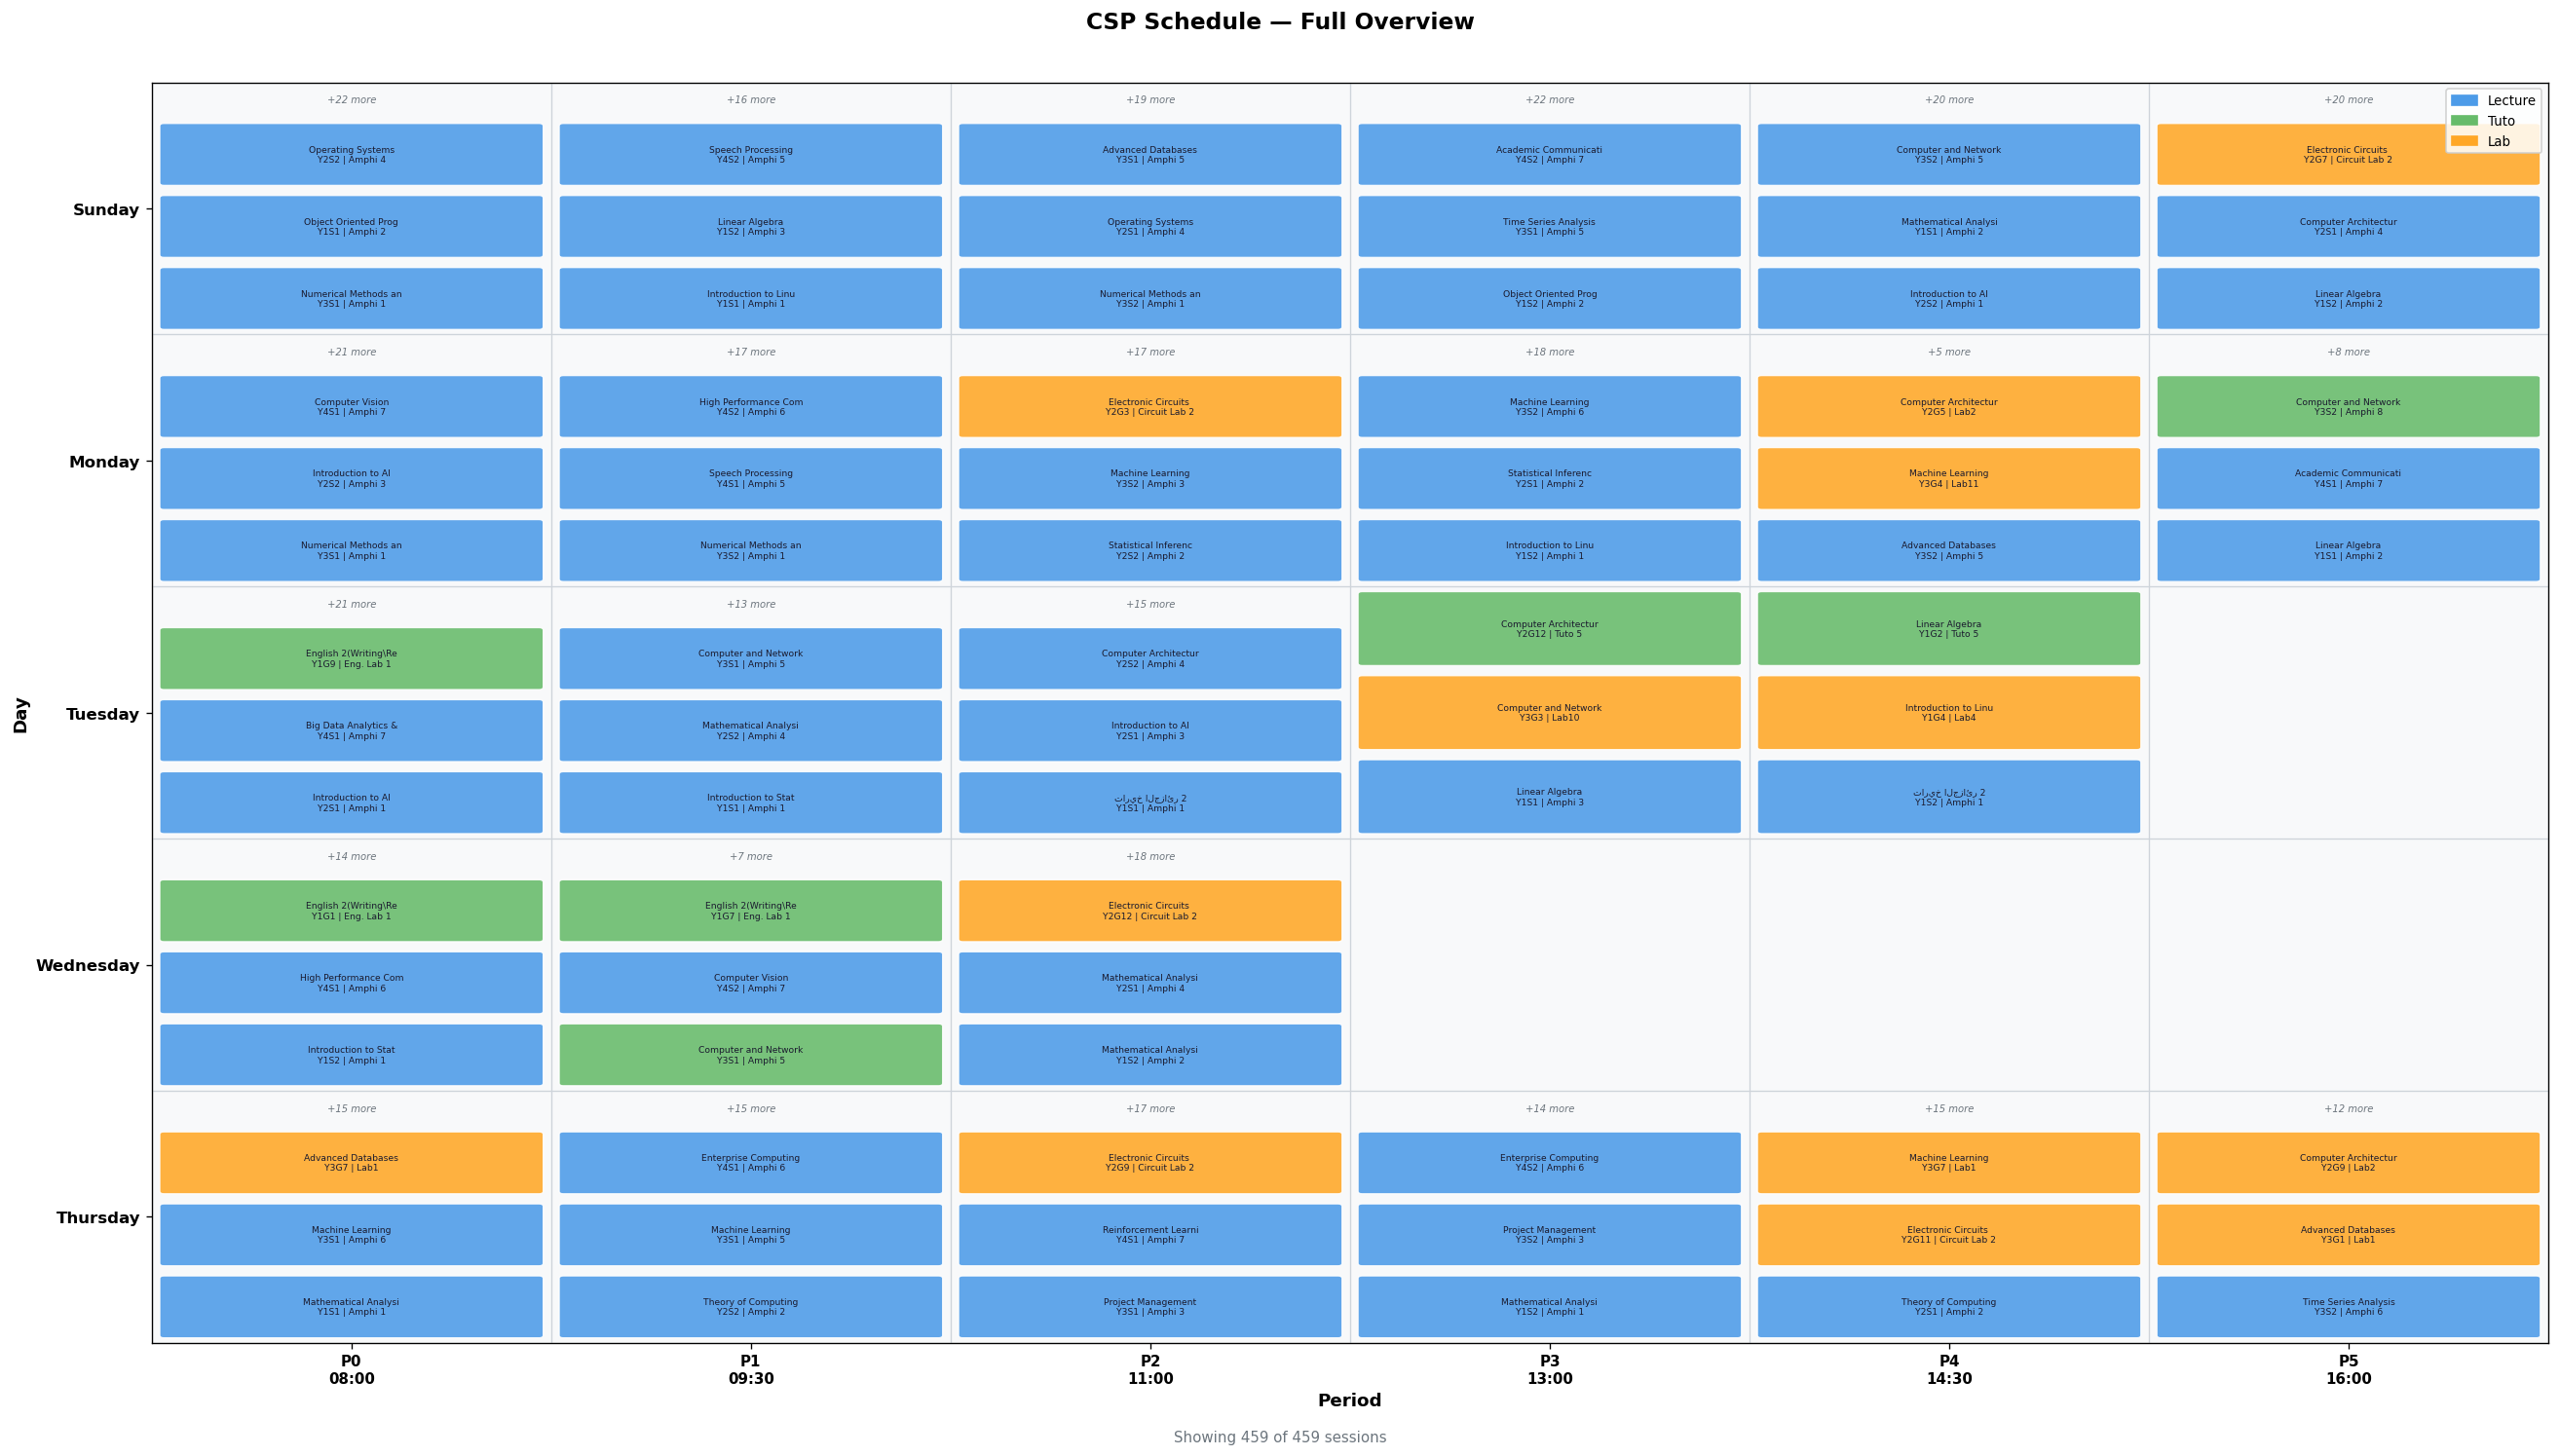

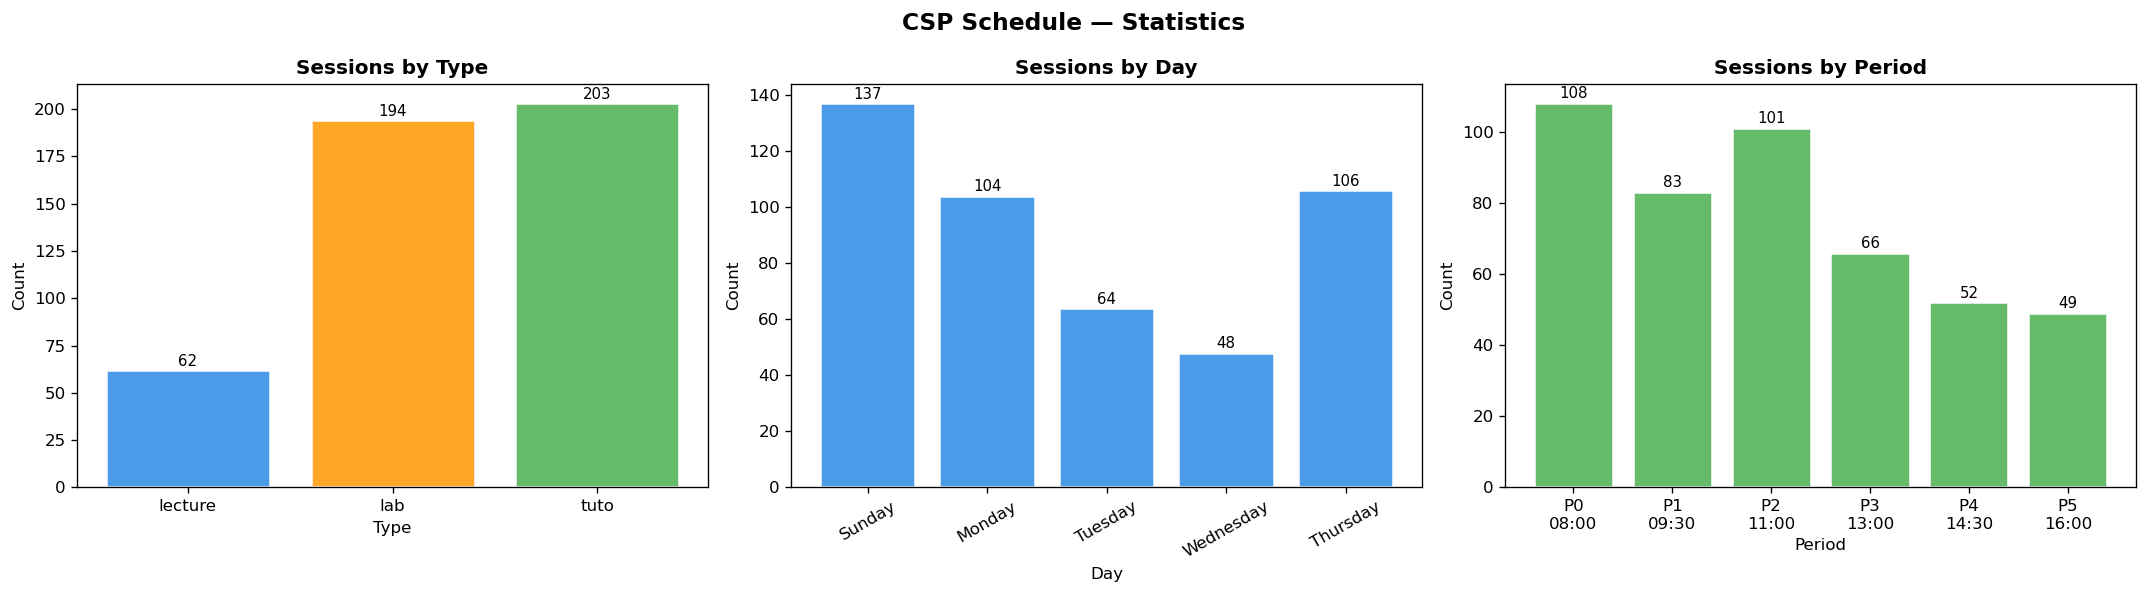

In [38]:
# ── Load CSP rows from file ────────────────────────────────────────────
with open(CSP_OUTPUT, encoding="utf-8") as f:
    csp_rows = json.load(f)

# ── Full overview ──────────────────────────────────────────────────────
print("=" * 50)
print("CSP SCHEDULE — Full Overview")
print("=" * 50)
visualize_timetable(csp_rows, title="CSP Schedule — Full Overview", max_sessions_per_cell=3)
visualize_stats(csp_rows, title="CSP Schedule — Statistics")

Available sections: ['Y1S1', 'Y1S2', 'Y2S1', 'Y2S2', 'Y3S1', 'Y3S2', 'Y4S1', 'Y4S2']


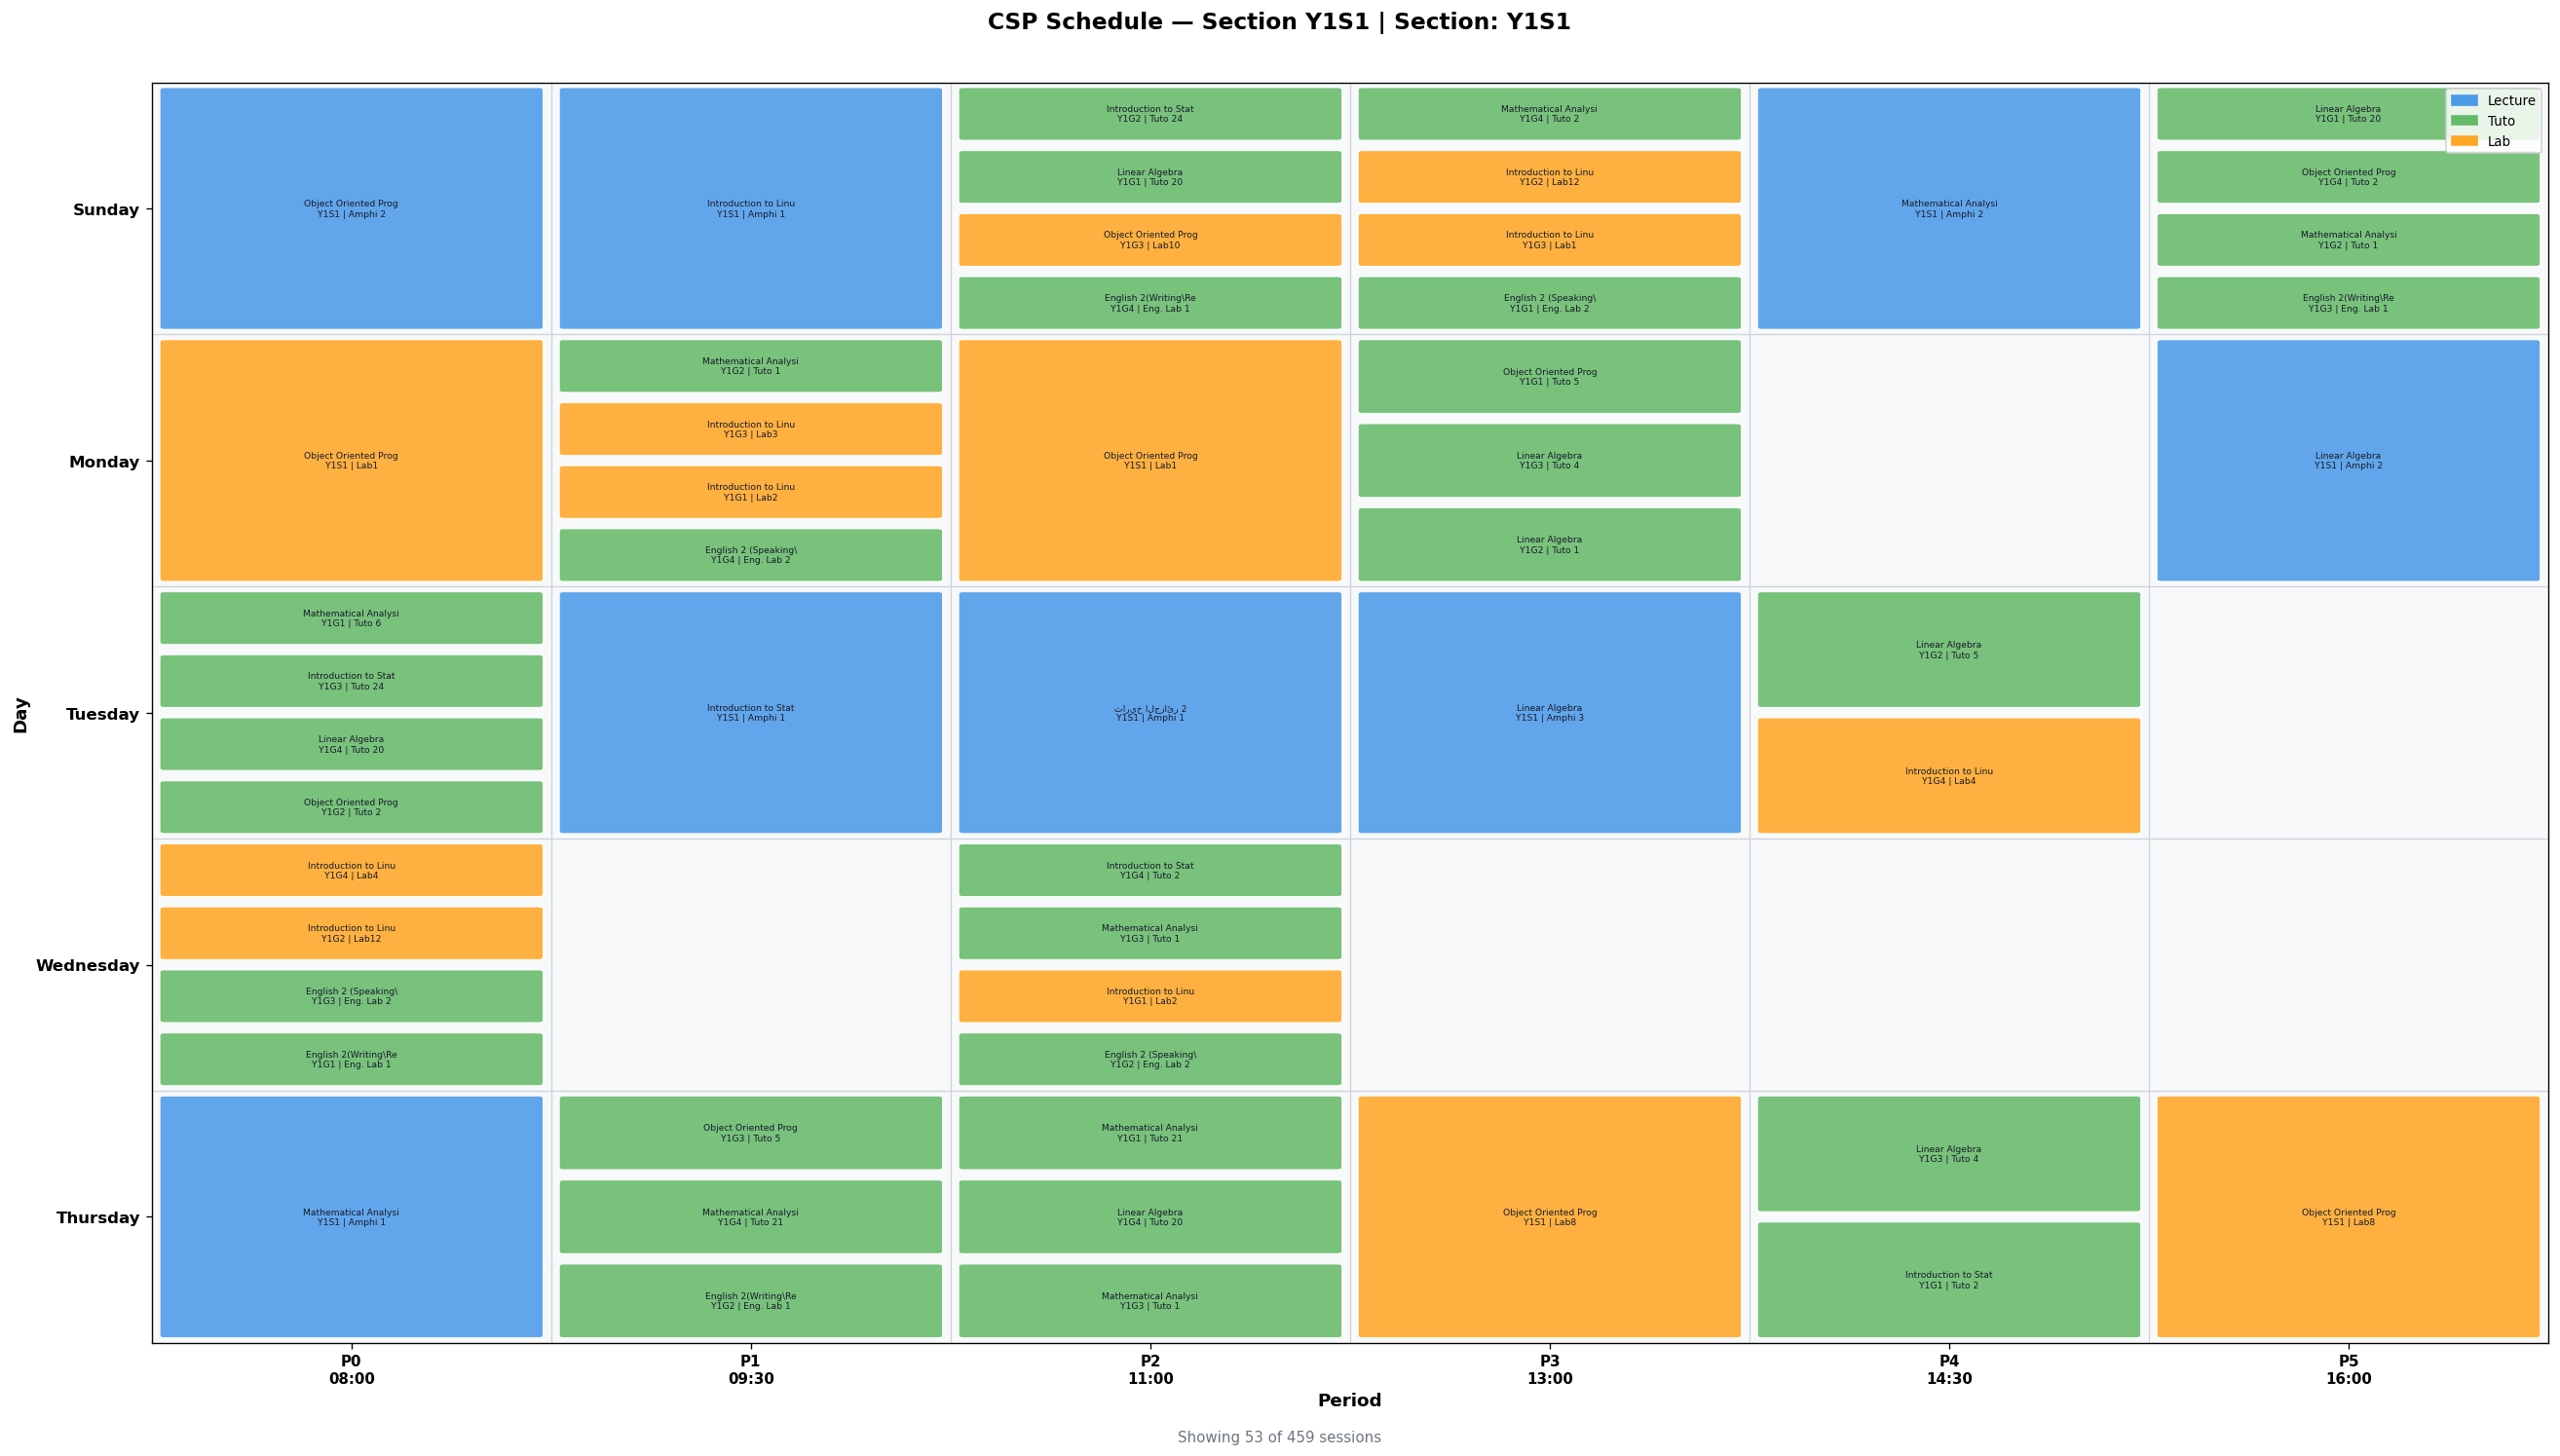

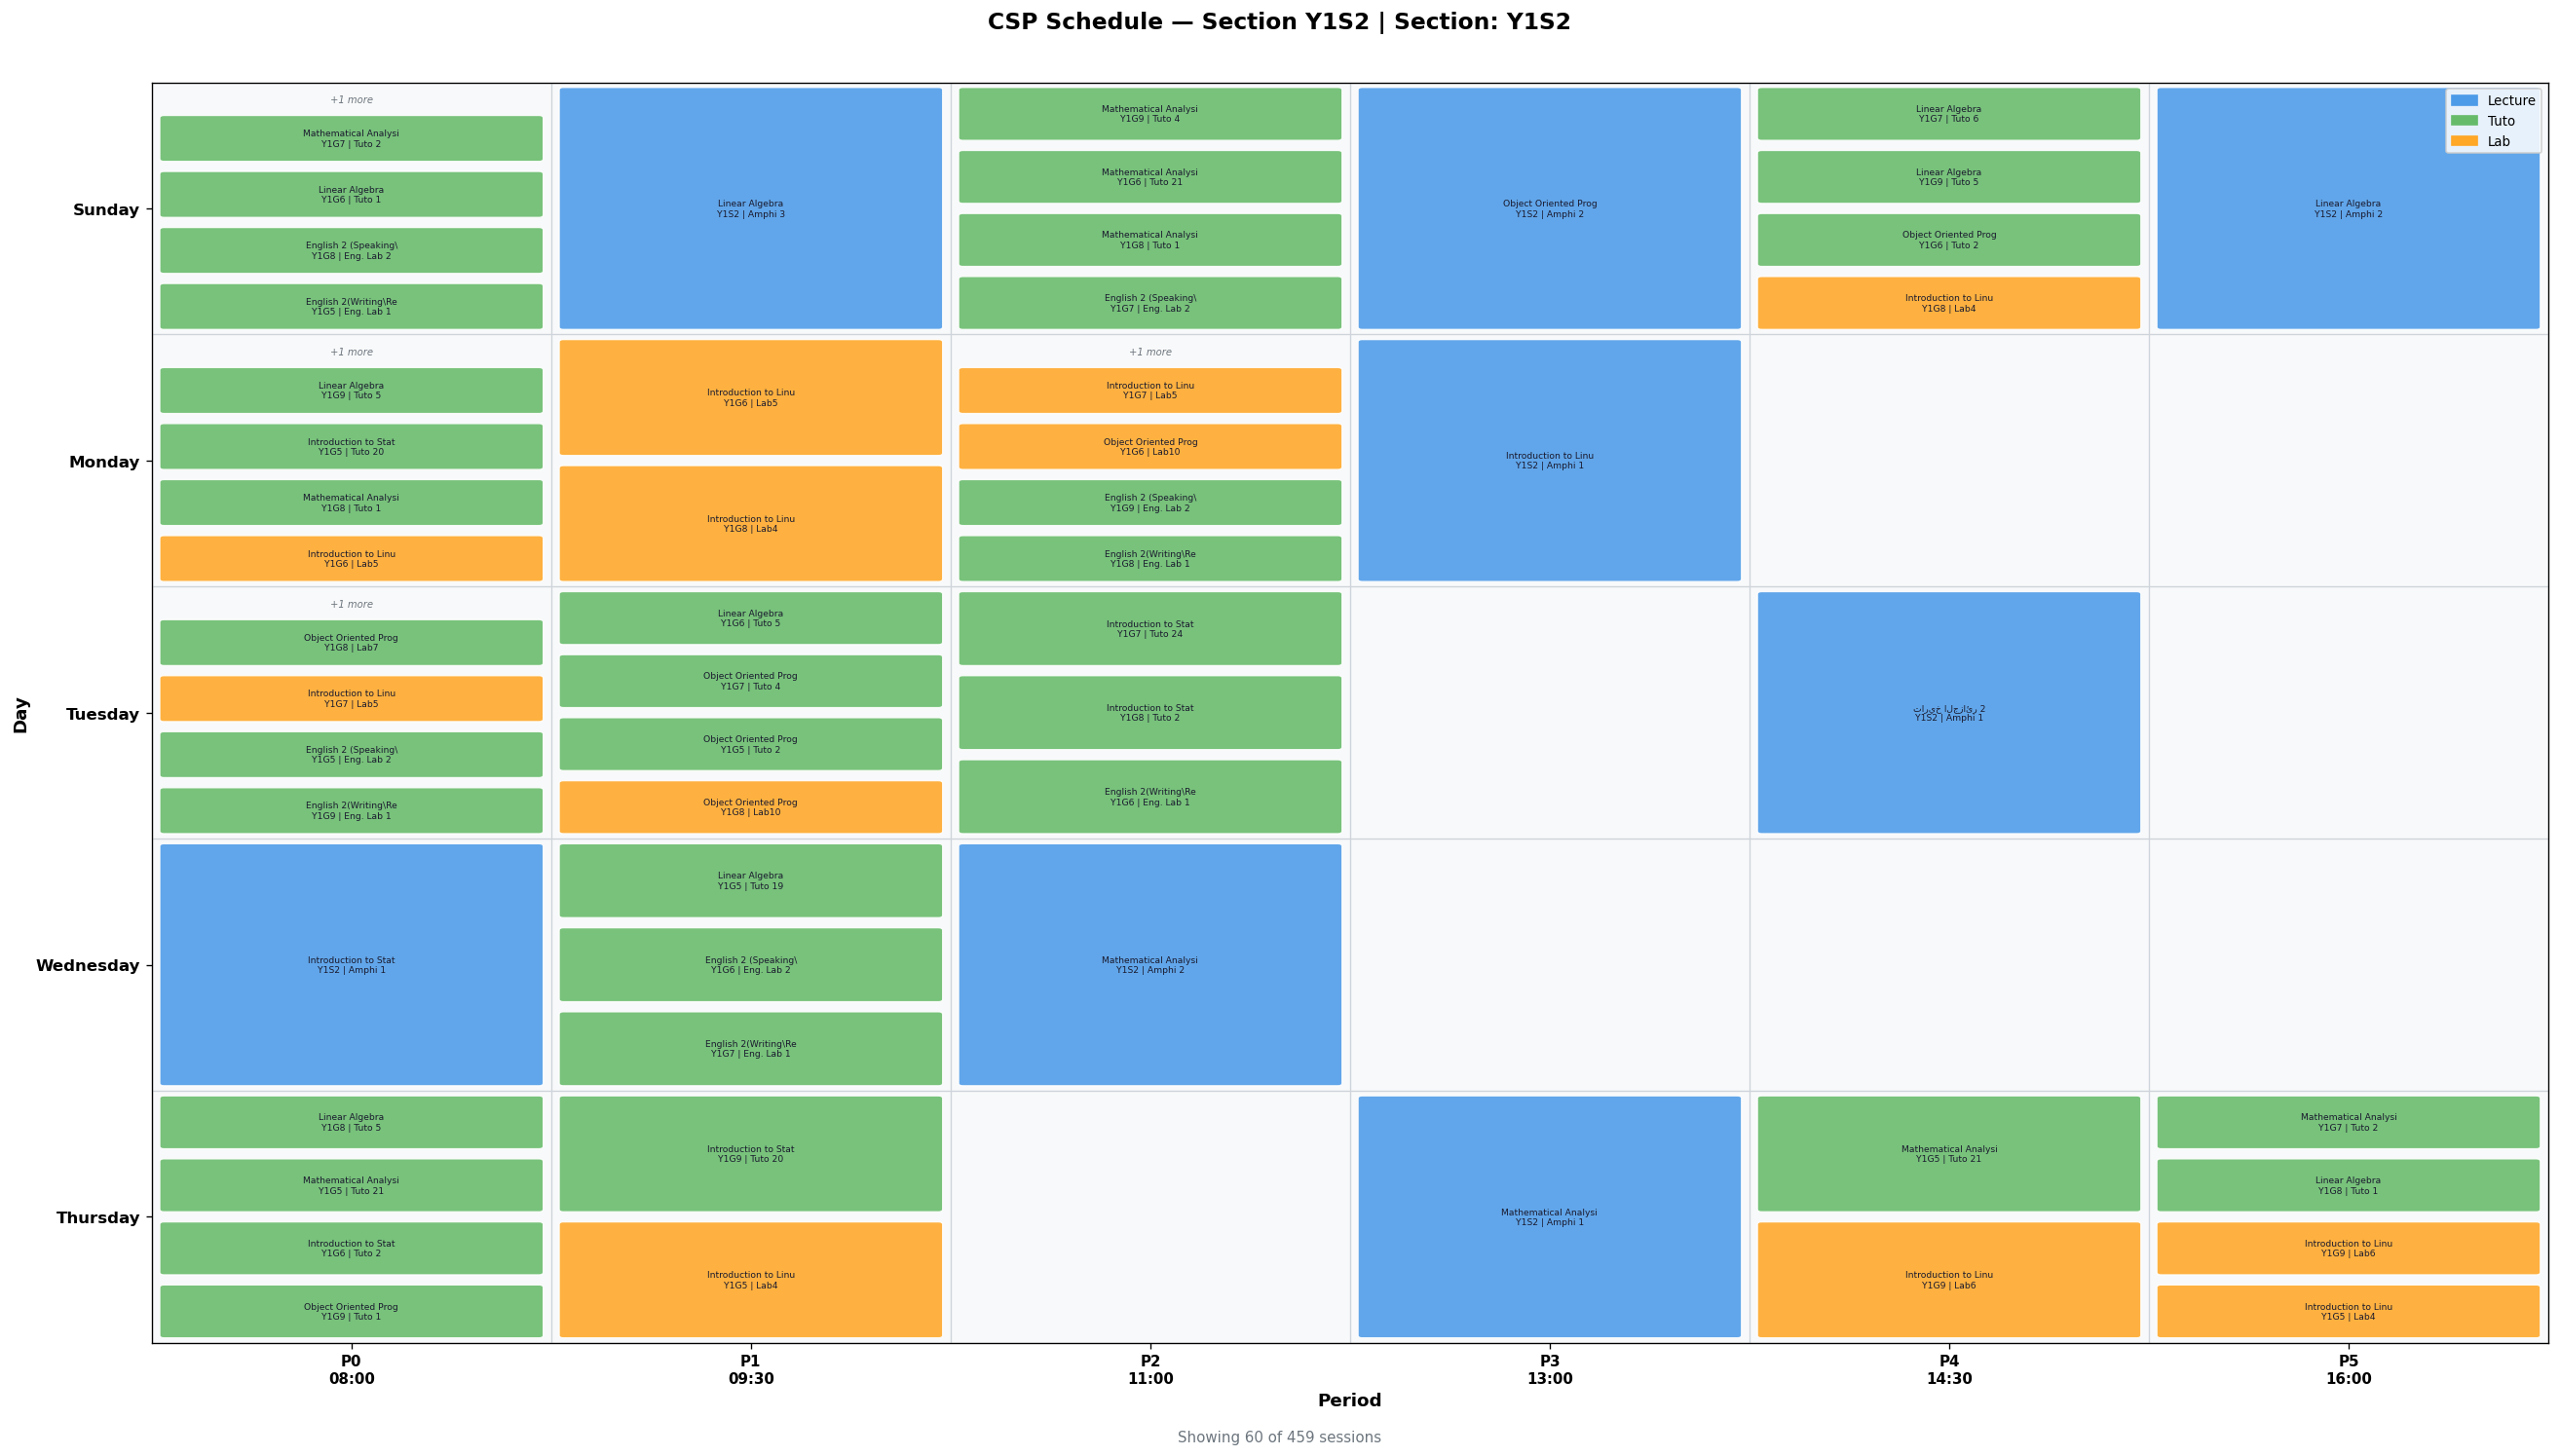

In [39]:
# ── Per-section views ─────────────────────────────────────────────────
# Shows each section's timetable individually
section_ids = sorted(context.section_map.keys())
print(f"Available sections: {section_ids}")

# Show first 2 sections (change as needed)
for sec in section_ids[:2]:
    visualize_section(csp_rows, sec, title_prefix="CSP Schedule")

---
## 🌡️ Cell 10 — SA Optimizer (sa_optimizer.py)

In [40]:
# ═══════════════════════════════════════════════════════════════════════
#  SIMULATED ANNEALING  (from sa_optimizer.py)
#  NOTE: uses sessions.json and rooms.json (NOT clean_sessions / clean_rooms)
# ═══════════════════════════════════════════════════════════════════════

def sa_load_schedule(path):
    """Read a flat schedule JSON and return (slot_of, room_of)."""
    with open(path, encoding="utf-8") as fh:
        rows = json.load(fh)
    slot_of = {row["session_id"]: (row["day"], row["period"]) for row in rows}
    room_of = {row["session_id"]: row["room"]                 for row in rows}
    return slot_of, room_of


def sa_save_schedule(slot_of, room_of, context, path):
    DAYS = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday"]
    rows = []
    for sid, (d, p) in slot_of.items():
        sess = context.session_map[sid]
        rows.append({
            "session_id": sid,
            "module"    : sess.module_name,
            "type"      : sess.session_type,
            "teacher"   : sess.teacher_id,
            "section"   : sess.section_id,
            "group"     : sess.group_id,
            "room"      : room_of[sid],
            "day"       : d,
            "day_name"  : DAYS[d],
            "period"    : p,
        })
    rows.sort(key=lambda x: (x["day"], x["period"], x["room"]))
    with open(path, "w", encoding="utf-8") as fh:
        json.dump(rows, fh, indent=2, ensure_ascii=False)


class SAConflictGraph:
    def __init__(self, context):
        self.conflicts = defaultdict(set)
        self._build(context)

    def _build(self, context):
        by_teacher      = defaultdict(list)
        by_section_wide = defaultdict(list)
        by_group        = defaultdict(list)
        section_tutolab = defaultdict(list)

        for sid, sess in context.session_map.items():
            by_teacher[sess.teacher_id].append(sid)
            if sess.group_id is None:
                by_section_wide[sess.section_id].append(sid)
            else:
                by_group[sess.group_id].append(sid)
                section_tutolab[sess.section_id].append(sid)

        def add_pair(a, b):
            self.conflicts[a].add(b); self.conflicts[b].add(a)

        def add_all_pairs(sids):
            for i in range(len(sids)):
                for j in range(i + 1, len(sids)):
                    add_pair(sids[i], sids[j])

        for sids in by_teacher.values():      add_all_pairs(sids)
        for sids in by_section_wide.values(): add_all_pairs(sids)
        for sids in by_group.values():        add_all_pairs(sids)

        for sec, wide_sids in by_section_wide.items():
            tl_sids = section_tutolab.get(sec, [])
            for w in wide_sids:
                for t in tl_sids:
                    add_pair(w, t)

    def peers(self, sid):
        return self.conflicts.get(sid, set())


class SAHardConstraintChecker:
    def __init__(self, cg, context):
        self.cg = cg; self.context = context

    @staticmethod
    def _build_slot_index(slot_of, room_of):
        idx = {}
        for sid, (d, p) in slot_of.items():
            idx[(d, p, room_of[sid])] = sid
        return idx

    def is_slot_swap_safe(self, sid_a, sid_b, slot_of, room_of):
        slot_a = slot_of[sid_a]; slot_b = slot_of[sid_b]
        if slot_a == slot_b: return False
        room_idx = self._build_slot_index(slot_of, room_of)
        for peer in self.cg.peers(sid_a):
            if peer == sid_b: continue
            if slot_of.get(peer) == slot_b: return False
        for peer in self.cg.peers(sid_b):
            if peer == sid_a: continue
            if slot_of.get(peer) == slot_a: return False
        occupant_b = room_idx.get((*slot_b, room_of[sid_a]))
        if occupant_b is not None and occupant_b != sid_b: return False
        occupant_a = room_idx.get((*slot_a, room_of[sid_b]))
        if occupant_a is not None and occupant_a != sid_a: return False
        return True

    def is_relocate_safe(self, sid, new_slot, slot_of, room_of):
        if slot_of[sid] == new_slot: return False
        d, p = new_slot
        if self.context.is_forbidden(sid, d, p): return False
        room_idx = self._build_slot_index(slot_of, room_of)
        for peer in self.cg.peers(sid):
            if slot_of.get(peer) == new_slot: return False
        occupant = room_idx.get((*new_slot, room_of[sid]))
        if occupant is not None and occupant != sid: return False
        return True

    def is_room_swap_safe(self, sid_a, sid_b, slot_of, room_of):
        if slot_of[sid_a] != slot_of[sid_b]: return False
        room_a = room_of[sid_a]; room_b = room_of[sid_b]
        if room_a == room_b: return False
        sess_a = self.context.session_map[sid_a]
        sess_b = self.context.session_map[sid_b]
        r_a = self.context.room_map.get(room_a)
        r_b = self.context.room_map.get(room_b)
        if r_a is None or r_b is None: return False
        if r_b.room_type != sess_a.required_room_type: return False
        if r_a.room_type != sess_b.required_room_type: return False
        if sess_a.allowed_rooms and room_b not in sess_a.allowed_rooms: return False
        if sess_b.allowed_rooms and room_a not in sess_b.allowed_rooms: return False
        try:
            if r_b.capacity < self.context.get_n_students(sess_a): return False
            if r_a.capacity < self.context.get_n_students(sess_b): return False
        except (KeyError, ValueError):
            return False
        return True


def sa_build_timetable(slot_of, room_of, context):
    sections     = sorted(context.section_map.keys())
    groups       = sorted(context.group_map.keys())
    audience_idx = {a: i for i, a in enumerate(sections + groups)}
    n_aud        = len(sections) + len(groups)
    timetable    = [
        [[(None, None)] * n_aud for _ in range(context.periods_per_day)]
        for _ in range(context.days)
    ]
    for sid, (d, p) in slot_of.items():
        sess     = context.session_map[sid]
        audience = sess.group_id if sess.group_id else sess.section_id
        a_idx    = audience_idx[audience]
        timetable[d][p][a_idx] = (room_of[sid], sid)
    return timetable


class SANeighborGenerator:
    def __init__(self, context, checker, all_slots, rng):
        self.context     = context
        self.checker     = checker
        self.all_slots   = all_slots
        self.session_ids = list(context.session_map.keys())
        self.rng         = rng

    def slot_swap(self, slot_of, room_of, max_attempts=80):
        sids = self.session_ids; n = len(sids)
        for _ in range(max_attempts):
            i = self.rng.randrange(n); j = self.rng.randrange(n)
            if i == j: continue
            sid_a = sids[i]; sid_b = sids[j]
            if not self.checker.is_slot_swap_safe(sid_a, sid_b, slot_of, room_of): continue
            new_slot_of = dict(slot_of)
            new_slot_of[sid_a] = slot_of[sid_b]; new_slot_of[sid_b] = slot_of[sid_a]
            return new_slot_of, room_of
        return None

    def slot_relocate(self, slot_of, room_of, max_attempts=80):
        sids = self.session_ids; n = len(sids); ns = len(self.all_slots)
        for _ in range(max_attempts):
            sid      = sids[self.rng.randrange(n)]
            new_slot = self.all_slots[self.rng.randrange(ns)]
            if not self.checker.is_relocate_safe(sid, new_slot, slot_of, room_of): continue
            new_slot_of = dict(slot_of); new_slot_of[sid] = new_slot
            return new_slot_of, room_of
        return None

    def room_swap(self, slot_of, room_of, max_attempts=80):
        slot_to_sids = defaultdict(list)
        for sid, slot in slot_of.items(): slot_to_sids[slot].append(sid)
        eligible = [s for s, sids in slot_to_sids.items() if len(sids) >= 2]
        if not eligible: return None
        for _ in range(max_attempts):
            slot = self.rng.choice(eligible)
            sids = slot_to_sids[slot]
            sid_a = self.rng.choice(sids); sid_b = self.rng.choice(sids)
            if sid_a == sid_b: continue
            if not self.checker.is_room_swap_safe(sid_a, sid_b, slot_of, room_of): continue
            new_room_of = dict(room_of)
            new_room_of[sid_a] = room_of[sid_b]; new_room_of[sid_b] = room_of[sid_a]
            return slot_of, new_room_of
        return None

    def random_neighbor(self, slot_of, room_of, move_weights=(0.45, 0.45, 0.10)):
        roll = self.rng.random(); w1, w2, _ = move_weights
        if roll < w1:      return self.slot_swap(slot_of, room_of)
        elif roll < w1+w2: return self.slot_relocate(slot_of, room_of)
        else:              return self.room_swap(slot_of, room_of)


def simulated_annealing(
    slot_of, room_of, context,
    t_start=500.0, t_end=0.1, cooling=0.9995,
    max_iter=200_000, move_weights=(0.45, 0.45, 0.10),
    seed=42, log_every=5_000,
):
    rng       = random.Random(seed)
    cg        = SAConflictGraph(context)
    checker   = SAHardConstraintChecker(cg, context)
    all_slots = list(context.valid_slots)
    gen       = SANeighborGenerator(context, checker, all_slots, rng)

    current_tt   = sa_build_timetable(slot_of, room_of, context)
    current_cost = total_soft_cost(current_tt, context)

    best_slot_of = dict(slot_of); best_room_of = dict(room_of); best_cost = current_cost
    current_slot_of = dict(slot_of); current_room_of = dict(room_of)

    T = t_start; accepted = 0; rejected = 0; no_neighbor = 0; t0_wall = time.time()

    print(f"\n{'='*60}")
    print("Simulated Annealing — Soft Cost Optimisation")
    print(f"{'='*60}")
    print(f"  Sessions     : {len(slot_of)}")
    print(f"  T_start      : {t_start}")
    print(f"  T_end        : {t_end}")
    print(f"  Cooling      : {cooling}")
    print(f"  Max iter     : {max_iter:,}")
    print(f"  Seed         : {seed}")
    print(f"{'='*60}")
    print(f"  Initial soft cost : {current_cost:.4f}\n")

    cost_history = [(0, current_cost)]

    for iteration in range(1, max_iter + 1):
        T *= cooling
        if T < t_end:
            print(f"  [iter {iteration:>7,}] Temperature reached T_end={t_end}. Stopping.")
            break

        candidate = gen.random_neighbor(current_slot_of, current_room_of, move_weights)
        if candidate is None:
            no_neighbor += 1; continue

        cand_slot_of, cand_room_of = candidate
        cand_tt   = sa_build_timetable(cand_slot_of, cand_room_of, context)
        cand_cost = total_soft_cost(cand_tt, context)
        delta     = cand_cost - current_cost

        if delta < 0 or rng.random() < math.exp(-delta / T):
            current_slot_of = cand_slot_of; current_room_of = cand_room_of
            current_cost    = cand_cost; accepted += 1
            if cand_cost < best_cost:
                best_slot_of = dict(cand_slot_of); best_room_of = dict(cand_room_of)
                best_cost    = cand_cost
        else:
            rejected += 1

        if iteration % log_every == 0:
            elapsed    = time.time() - t0_wall
            accept_pct = 100 * accepted / (accepted + rejected + no_neighbor)
            print(f"  [iter {iteration:>7,}]  T={T:>8.3f}  "
                  f"cur={current_cost:>10.4f}  best={best_cost:>10.4f}  "
                  f"acc%={accept_pct:>5.1f}  elapsed={elapsed:.1f}s")
            cost_history.append((iteration, best_cost))

    total_iter = accepted + rejected + no_neighbor
    elapsed    = time.time() - t0_wall
    print(f"\n{'='*60}")
    print(f"SA finished after {total_iter:,} effective iterations ({elapsed:.1f}s)")
    print(f"  Best cost    : {best_cost:.4f}")
    cost_history.append((total_iter, best_cost))
    return best_slot_of, best_room_of, best_cost, cost_history


print("✅ Simulated Annealing optimizer defined.")

✅ Simulated Annealing optimizer defined.


---
## 🚀 Cell 11 — Run SA Optimizer

> ⏱️ Adjust `max_iter` and `cooling` to control runtime vs quality.

In [41]:
# Load the CSP schedule as the SA starting point
sa_slot_of, sa_room_of = sa_load_schedule(CSP_OUTPUT)
print(f"SA starting from CSP schedule: {len(sa_slot_of)} sessions")

# Print initial soft costs
init_tt = sa_build_timetable(sa_slot_of, sa_room_of, context)
init_breakdown = soft_cost_breakdown(init_tt, context)
print("\nInitial soft cost breakdown (CSP → SA input):")
for k, v in init_breakdown.items():
    print(f"  {k:<24} : {v}")

# Run SA
sa_best_slot_of, sa_best_room_of, sa_best_cost, sa_cost_history = simulated_annealing(
    slot_of    = sa_slot_of,
    room_of    = sa_room_of,
    context    = context,
    t_start    = 500.0,
    t_end      = 0.1,
    cooling    = 0.9995,
    max_iter   = 200_000,
    seed       = 42,
    log_every  = 10_000,
)

# Final soft cost breakdown
sa_best_tt = sa_build_timetable(sa_best_slot_of, sa_best_room_of, context)
sa_breakdown = soft_cost_breakdown(sa_best_tt, context)
print("\nBest SA soft cost breakdown:")
for k, v in sa_breakdown.items():
    print(f"  {k:<24} : {v}")

# Save output
sa_save_schedule(sa_best_slot_of, sa_best_room_of, context, SA_OUTPUT)
print(f"\n✅ SA schedule saved to '{SA_OUTPUT}'")

SA starting from CSP schedule: 459 sessions

Initial soft cost breakdown (CSP → SA input):
  capacity_waste           : 202.2
  teacher_room_change      : 1048.0
  travel_distance          : 10772.5
  compactness              : 90.0
  teacher_preference       : 2140.0
  total                    : 14252.7

Simulated Annealing — Soft Cost Optimisation
  Sessions     : 459
  T_start      : 500.0
  T_end        : 0.1
  Cooling      : 0.9995
  Max iter     : 200,000
  Seed         : 42
  Initial soft cost : 14252.7000

  [iter  17,031] Temperature reached T_end=0.1. Stopping.

SA finished after 17,030 effective iterations (148.2s)
  Best cost    : 3410.7000

Best SA soft cost breakdown:
  capacity_waste           : 202.2
  teacher_room_change      : 536.0
  travel_distance          : 1322.5
  compactness              : 120.0
  teacher_preference       : 1230.0
  total                    : 3410.7

✅ SA schedule saved to 'schedule_sa_output.json'


---
## ✅ Cell 12 — Validate SA Output

In [42]:
print("=" * 60)
print("HARD CONSTRAINT VALIDATION — SA OUTPUT")
print("=" * 60)

sa_validation = validate_schedule(SA_OUTPUT)
print(sa_validation["message"])
print()
print(f"  Sessions checked : {sa_validation['sessions_checked']}")
print(f"  Total violations : {sa_validation['total_violations']}")
print(f"  Result           : {'PASS ✅' if sa_validation['passed'] else 'FAIL ❌'}")

HARD CONSTRAINT VALIDATION — SA OUTPUT
✅  SCHEDULE VALID
    459 sessions checked — no hard constraint violations found.

  Sessions checked : 459
  Total violations : 0
  Result           : PASS ✅


---
## 📊 Cell 13 — SA Timetable Visualizer

SA SCHEDULE — Full Overview


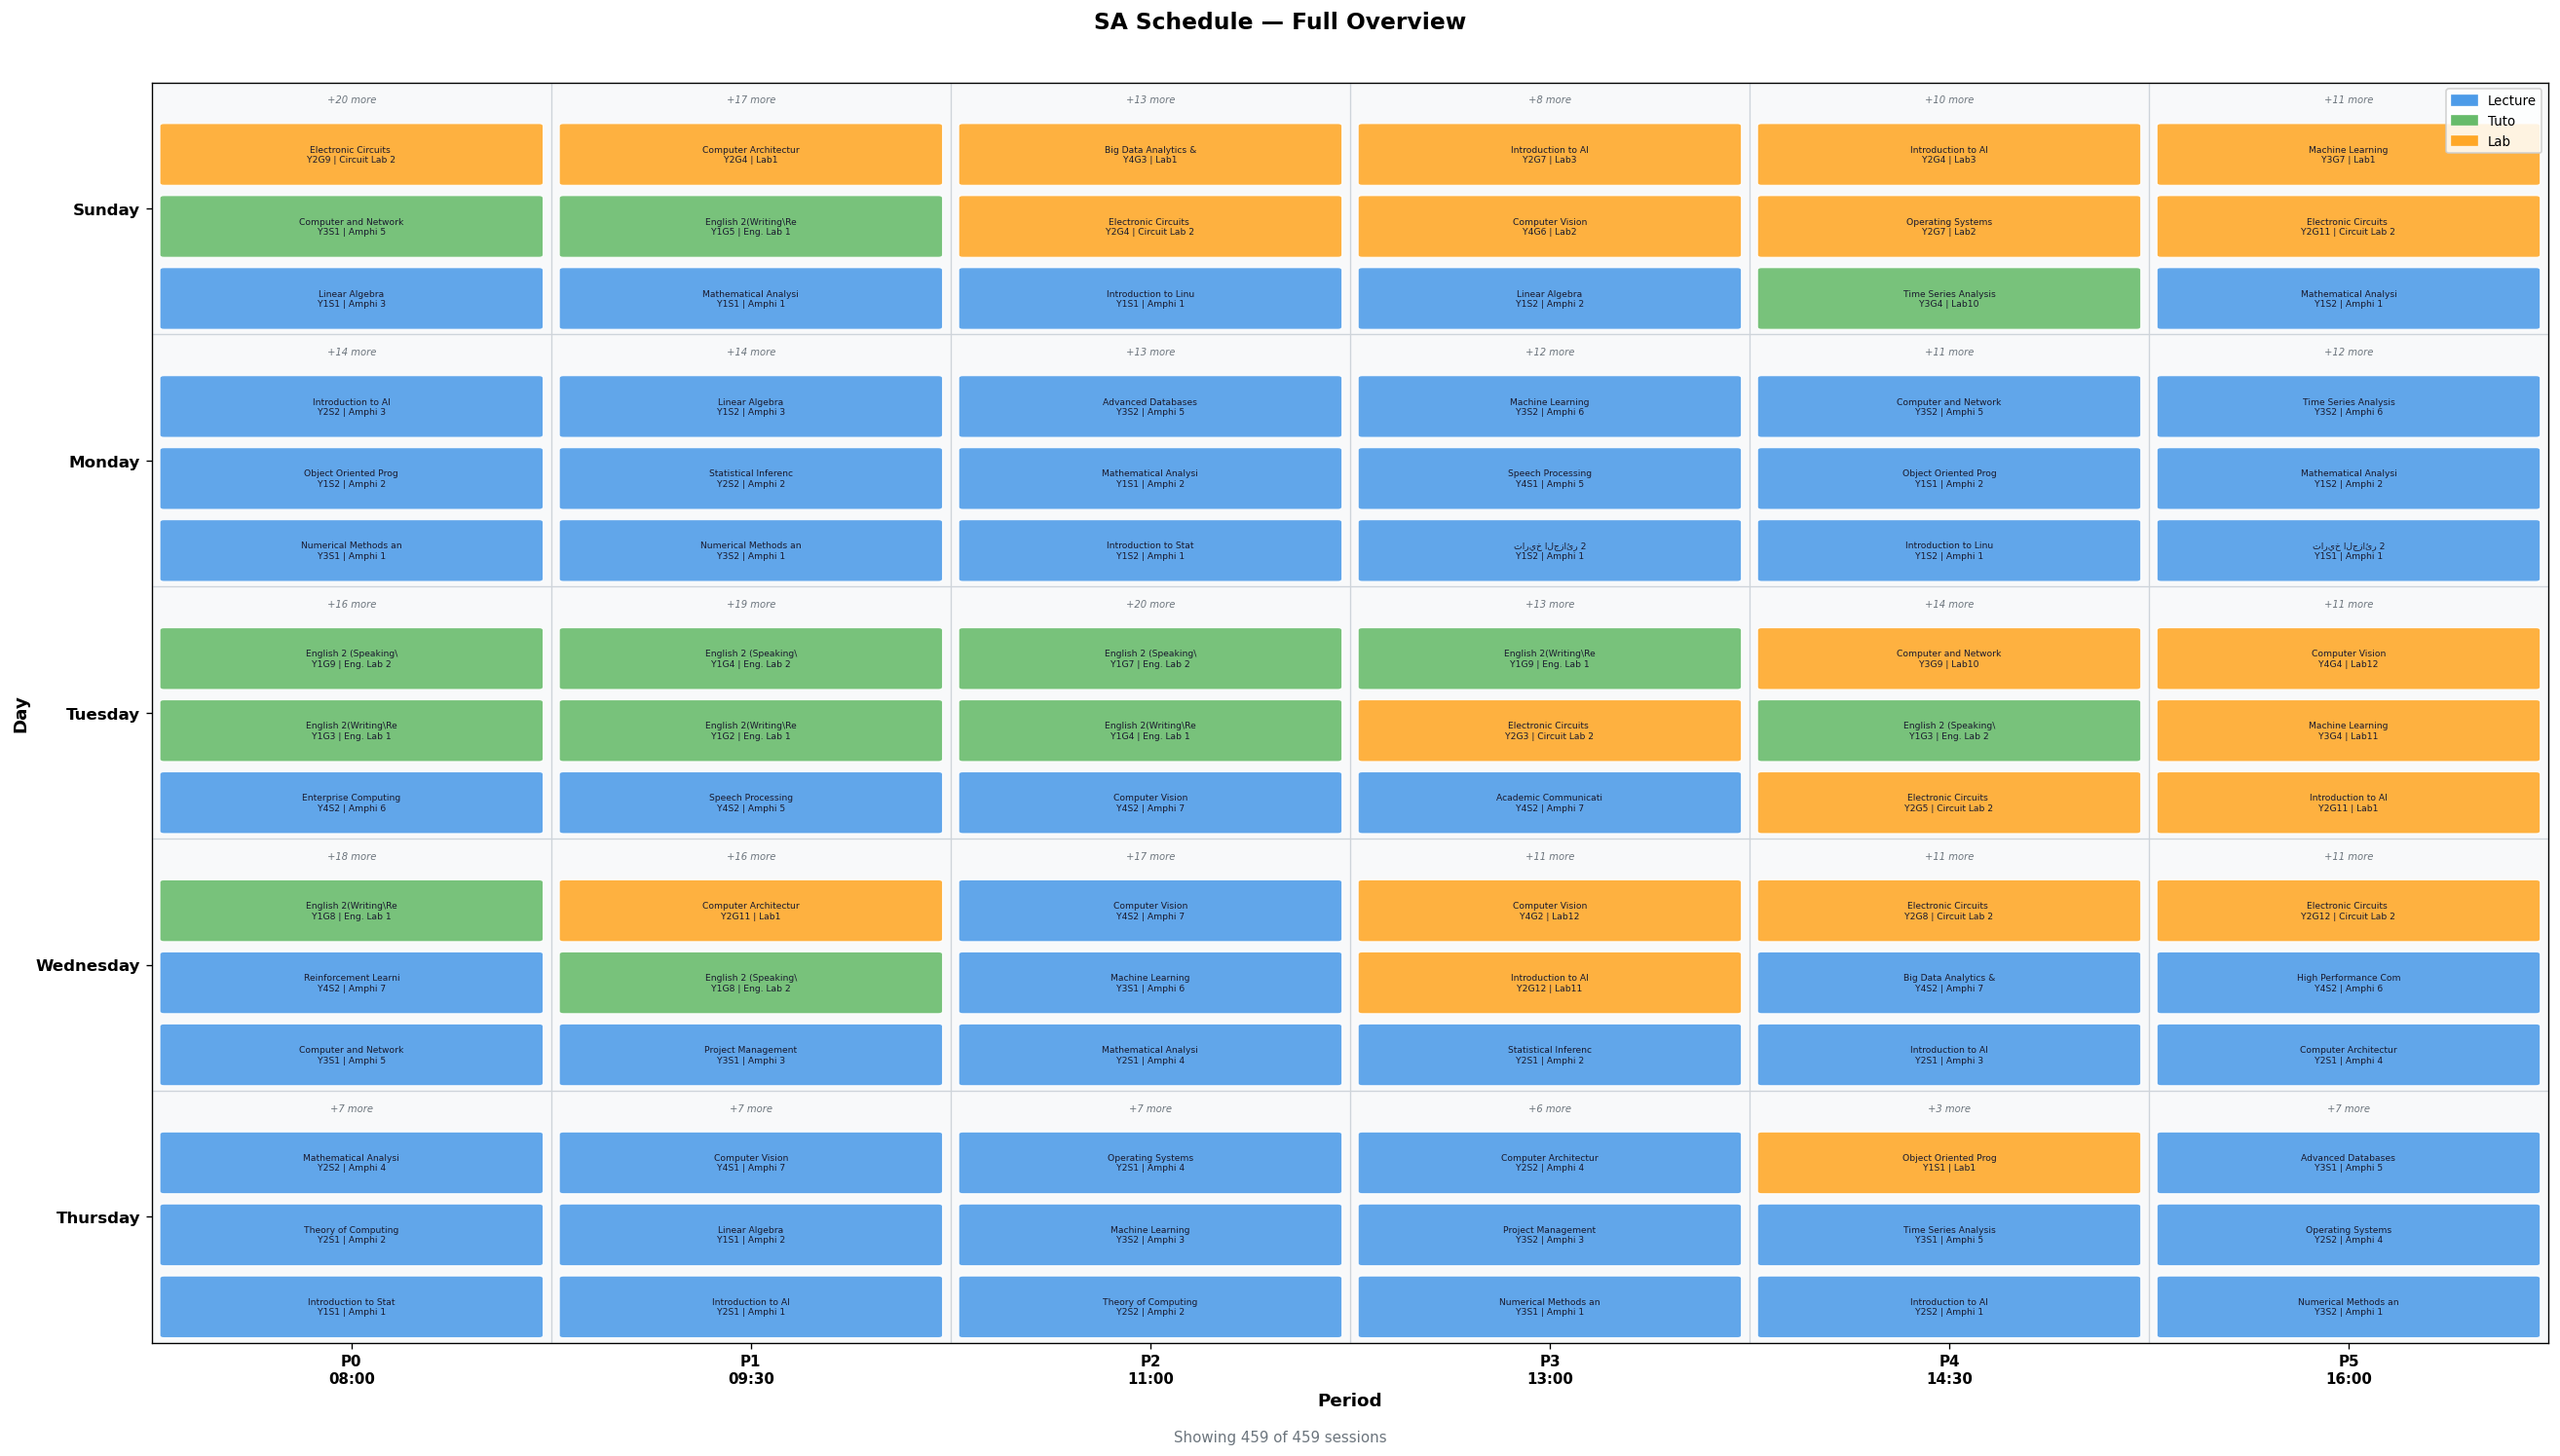

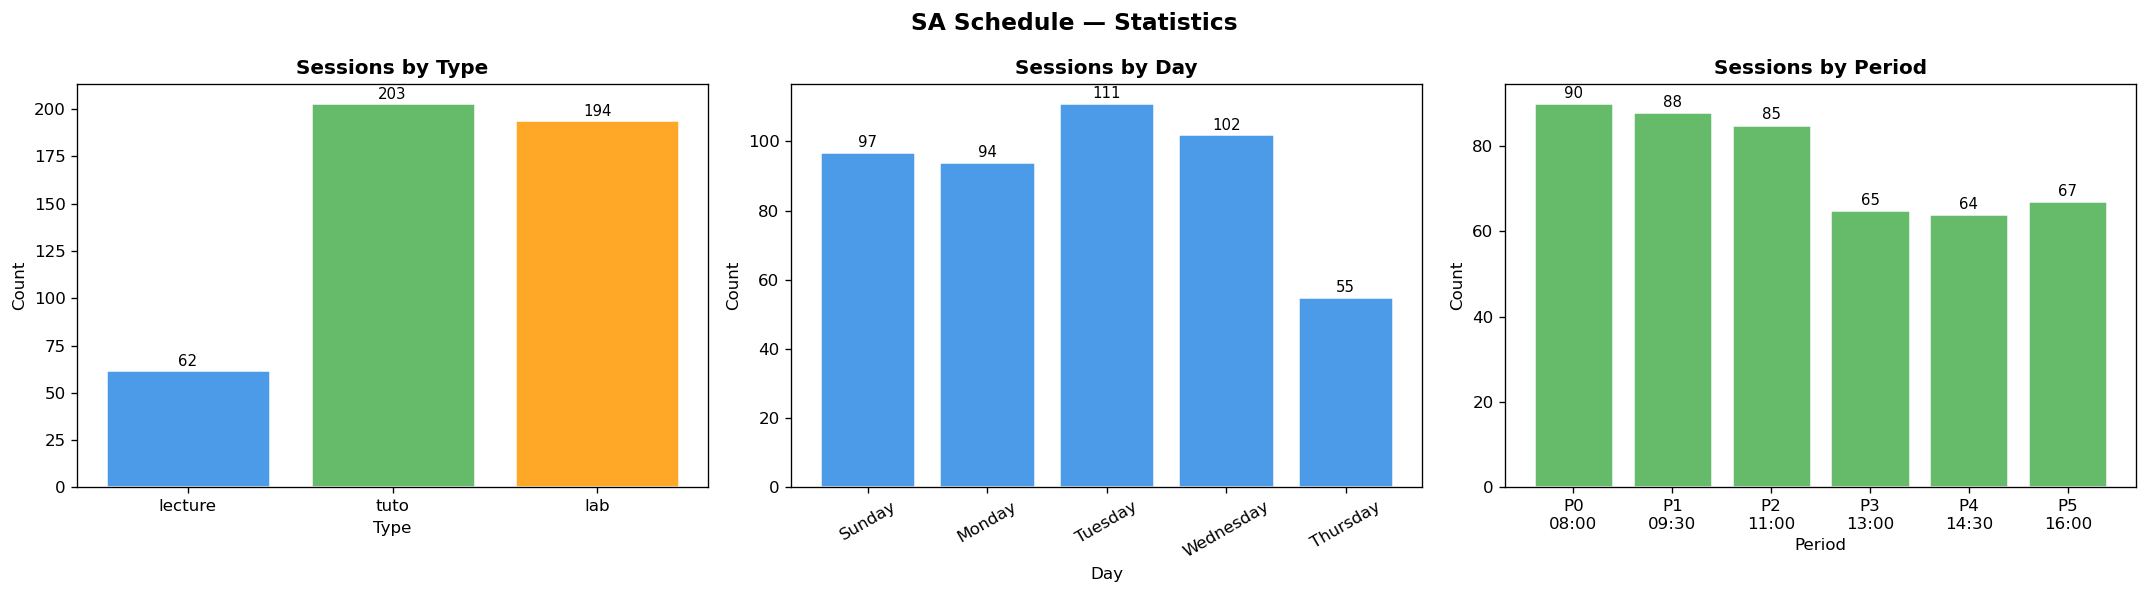

In [43]:
with open(SA_OUTPUT, encoding="utf-8") as f:
    sa_rows = json.load(f)

print("=" * 50)
print("SA SCHEDULE — Full Overview")
print("=" * 50)
visualize_timetable(sa_rows, title="SA Schedule — Full Overview", max_sessions_per_cell=3)
visualize_stats(sa_rows, title="SA Schedule — Statistics")

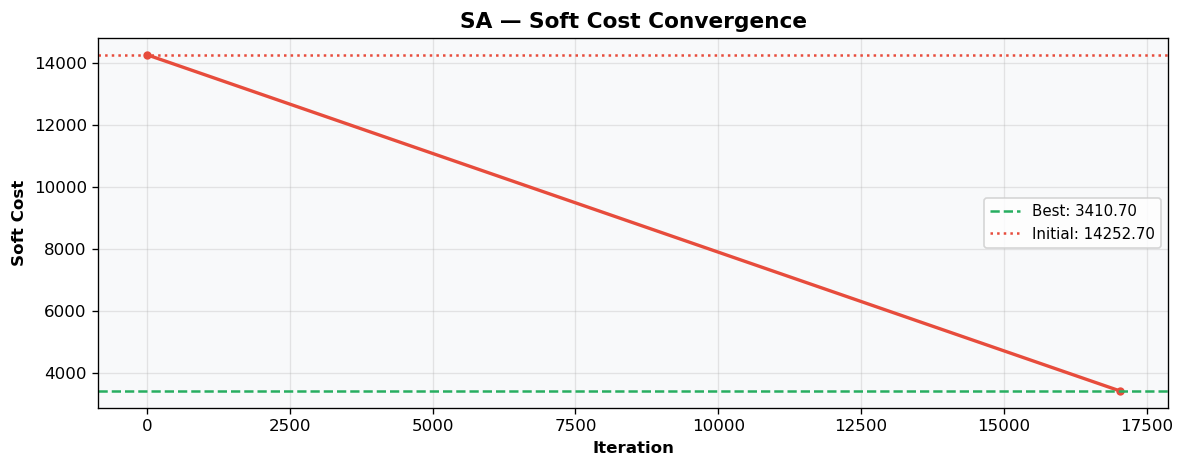

In [44]:
# SA cost convergence plot
if sa_cost_history:
    iters  = [h[0] for h in sa_cost_history]
    costs  = [h[1] for h in sa_cost_history]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(iters, costs, color='#E74C3C', linewidth=2, marker='o', markersize=4)
    ax.axhline(costs[-1], color='#27AE60', linestyle='--', linewidth=1.5,
               label=f'Best: {costs[-1]:.2f}')
    ax.axhline(costs[0], color='#E74C3C', linestyle=':', linewidth=1.5,
               label=f'Initial: {costs[0]:.2f}')
    ax.set_xlabel("Iteration", fontweight='bold')
    ax.set_ylabel("Soft Cost", fontweight='bold')
    ax.set_title("SA — Soft Cost Convergence", fontweight='bold', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#F8F9FA')
    plt.tight_layout()
    plt.show()

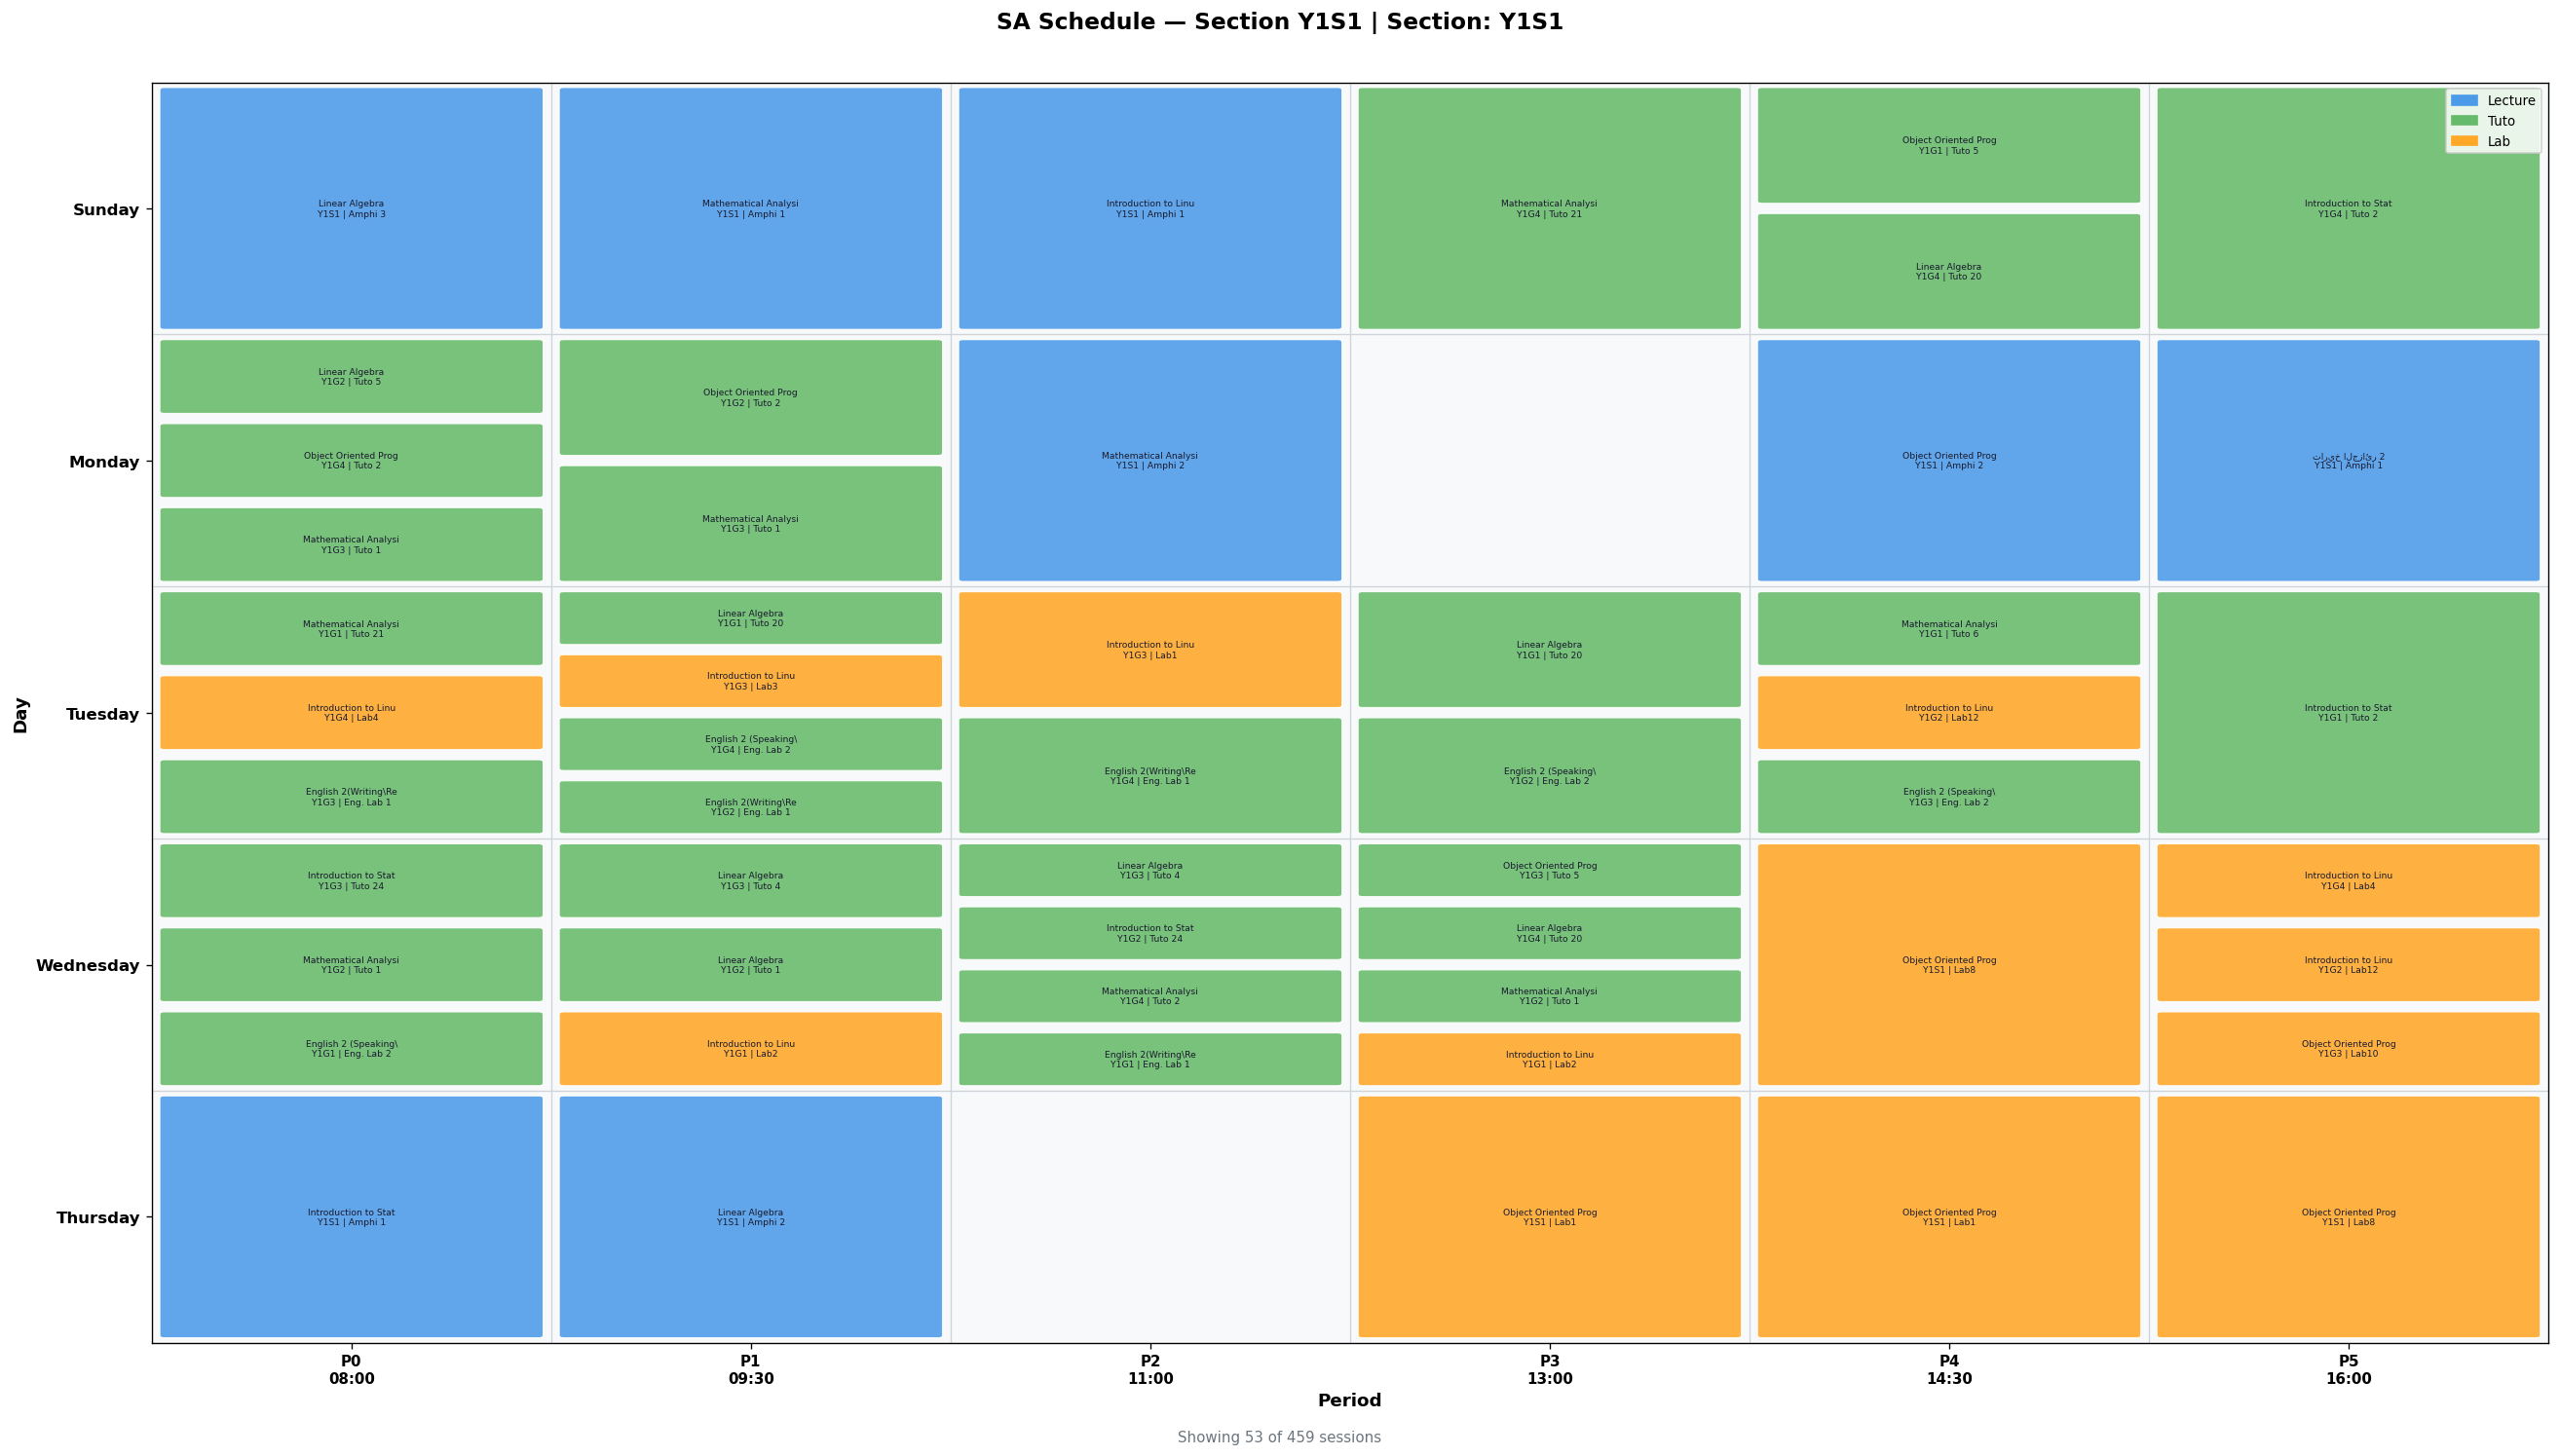

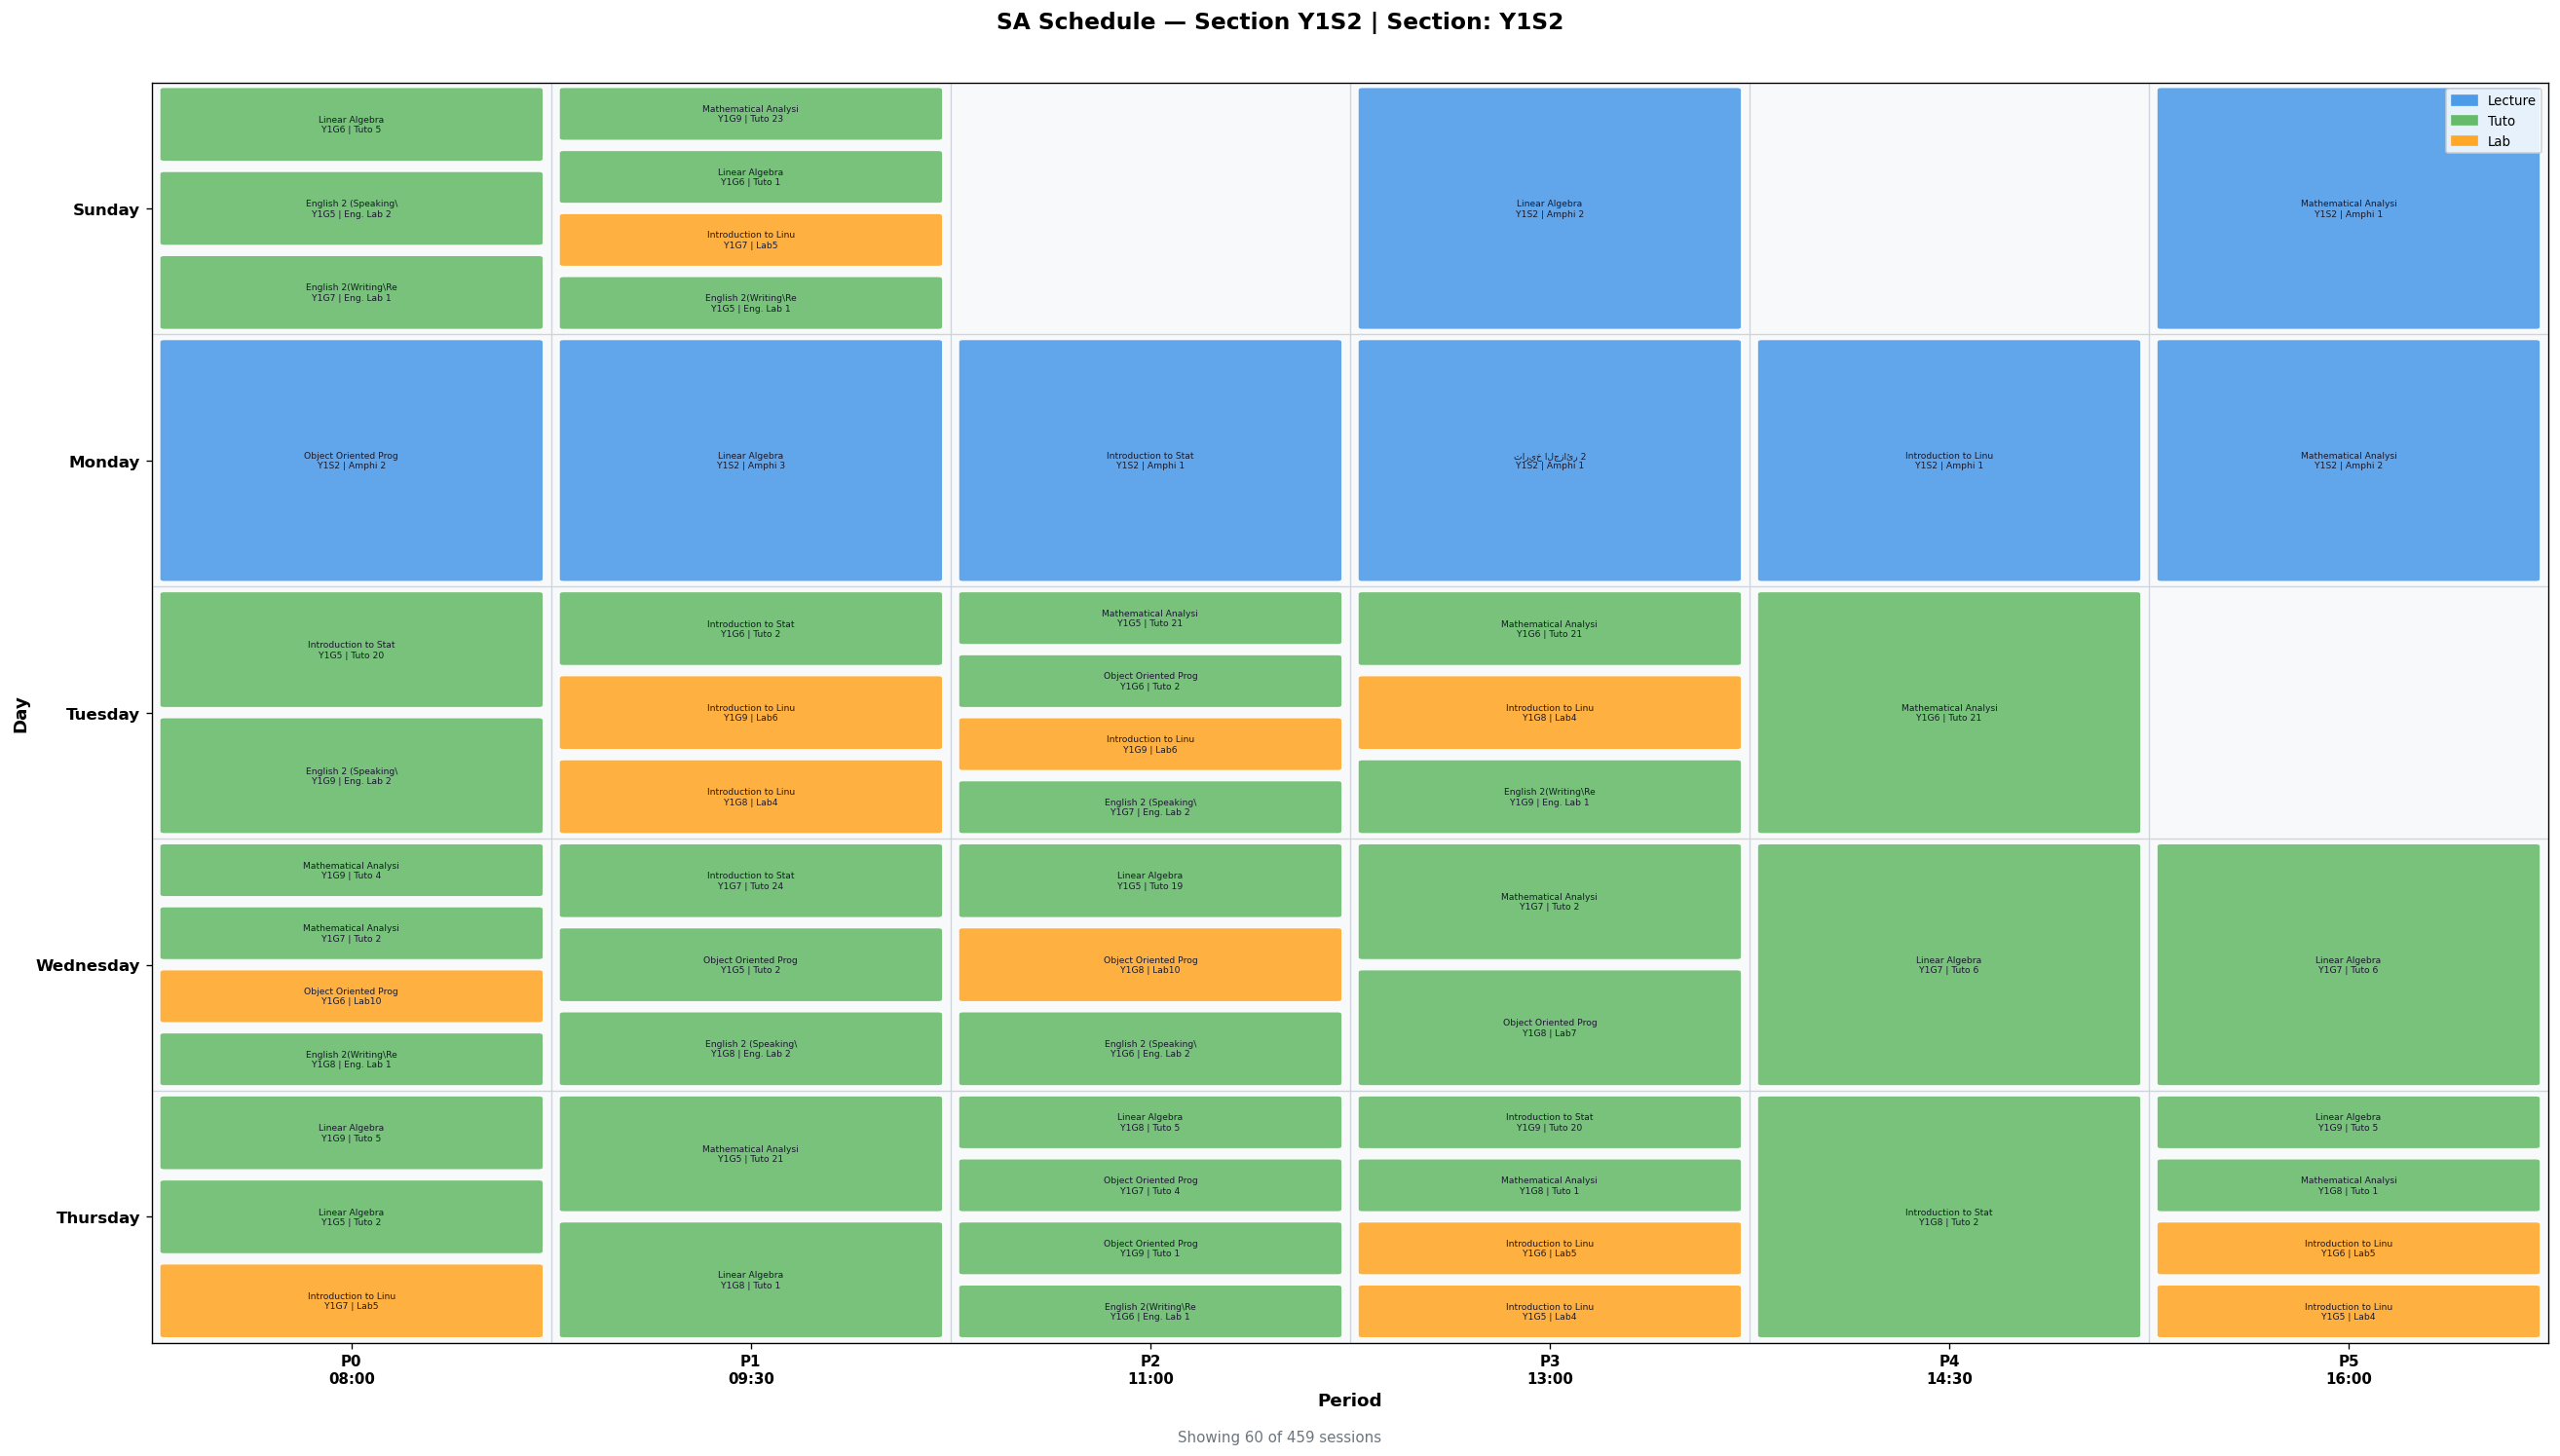

In [45]:
# SA per-section views
for sec in section_ids[:2]:
    visualize_section(sa_rows, sec, title_prefix="SA Schedule")

---
## 🧗 Cell 14 — Hill Climbing Optimizer (hill_climbing.py)

In [46]:
# ═══════════════════════════════════════════════════════════════════════
#  HILL CLIMBING  (from hill_climbing.py)
#  NOTE: uses sessions.json and rooms.json (NOT clean_sessions / clean_rooms)
# ═══════════════════════════════════════════════════════════════════════

class ScheduleState:
    def __init__(self, sessions_json, context, csp_session_data):
        self.context          = context
        self.csp_session_data = csp_session_data
        self.assignment   = {}
        self.room_assign  = {}
        self._room_slot   = {}; self._tchr_slot = {}
        self._sec_slot    = {}; self._grp_slot  = {}
        self.teacher_of   = {}; self.section_of = {}; self.group_of = {}

        for s in sessions_json:
            sid     = s["session_id"]
            day     = s["day"]; period = s["period"]
            room    = s["room"]; teacher = s["teacher"]
            section = s["section"]; group = s.get("group")
            self.assignment[sid]  = (day, period)
            self.room_assign[sid] = room
            self.teacher_of[sid]  = teacher
            self.section_of[sid]  = section
            self.group_of[sid]    = group
            self._room_slot[(day, period, room)]    = sid
            self._tchr_slot[(day, period, teacher)] = sid
            if group is None:
                self._sec_slot[(day, period, section)] = sid
            else:
                self._grp_slot[(day, period, group)] = sid

        self._audience_list, self._audience_idx = build_audience_index(context)
        self._n_aud   = len(self._audience_list)
        self._all_slots = [(d, p) for d in range(context.days)
                           for p in range(context.periods_per_day)]

    def clone(self):
        ns = object.__new__(ScheduleState)
        ns.context          = self.context
        ns.csp_session_data = self.csp_session_data
        ns.assignment       = dict(self.assignment)
        ns.room_assign      = dict(self.room_assign)
        ns._room_slot       = dict(self._room_slot)
        ns._tchr_slot       = dict(self._tchr_slot)
        ns._sec_slot        = dict(self._sec_slot)
        ns._grp_slot        = dict(self._grp_slot)
        ns.teacher_of       = self.teacher_of
        ns.section_of       = self.section_of
        ns.group_of         = self.group_of
        ns._audience_list   = self._audience_list
        ns._audience_idx    = self._audience_idx
        ns._n_aud           = self._n_aud
        ns._all_slots       = self._all_slots
        return ns

    def _remove_from_indexes(self, sid):
        d, p = self.assignment[sid]
        room = self.room_assign[sid]
        tchr = self.teacher_of[sid]
        sec  = self.section_of[sid]
        grp  = self.group_of[sid]
        self._room_slot.pop((d, p, room), None)
        self._tchr_slot.pop((d, p, tchr), None)
        if grp is None:
            self._sec_slot.pop((d, p, sec), None)
        else:
            self._grp_slot.pop((d, p, grp), None)

    def _insert_into_indexes(self, sid, day, period, room):
        tchr = self.teacher_of[sid]; sec = self.section_of[sid]; grp = self.group_of[sid]
        self._room_slot[(day, period, room)]    = sid
        self._tchr_slot[(day, period, tchr)]    = sid
        if grp is None:
            self._sec_slot[(day, period, sec)]  = sid
        else:
            self._grp_slot[(day, period, grp)]  = sid

    def _is_placement_feasible(self, sid, day, period, room, exclude_sids=None):
        allowed = self.csp_session_data[sid].get("allowed_rooms", [])
        if allowed and room not in allowed: return False
        if self.context.is_forbidden(sid, day, period): return False

        def blocked(occ):
            return occ is not None and occ != sid and (exclude_sids is None or occ not in exclude_sids)

        if blocked(self._room_slot.get((day, period, room))): return False
        if blocked(self._tchr_slot.get((day, period, self.teacher_of[sid]))): return False

        grp = self.group_of[sid]; sec = self.section_of[sid]
        if grp is None:
            if blocked(self._sec_slot.get((day, period, sec))): return False
            for g_id, g_obj in self.context.group_map.items():
                if g_obj.section_id == sec:
                    if blocked(self._grp_slot.get((day, period, g_id))): return False
        else:
            if blocked(self._grp_slot.get((day, period, grp))): return False
            if blocked(self._sec_slot.get((day, period, sec))): return False
        return True

    def apply_move_single(self, sid, new_day, new_period, new_room):
        self._remove_from_indexes(sid)
        self.assignment[sid] = (new_day, new_period)
        self.room_assign[sid] = new_room
        self._insert_into_indexes(sid, new_day, new_period, new_room)

    def apply_swap_timeslots(self, sid_a, sid_b):
        da, pa = self.assignment[sid_a]; db, pb = self.assignment[sid_b]
        ra = self.room_assign[sid_a]; rb = self.room_assign[sid_b]
        self._remove_from_indexes(sid_a); self._remove_from_indexes(sid_b)
        self.assignment[sid_a] = (db, pb); self.assignment[sid_b] = (da, pa)
        self._insert_into_indexes(sid_a, db, pb, ra)
        self._insert_into_indexes(sid_b, da, pa, rb)

    def apply_swap_rooms(self, sid_a, sid_b):
        da, pa = self.assignment[sid_a]; db, pb = self.assignment[sid_b]
        ra = self.room_assign[sid_a]; rb = self.room_assign[sid_b]
        self._remove_from_indexes(sid_a); self._remove_from_indexes(sid_b)
        self.room_assign[sid_a] = rb; self.room_assign[sid_b] = ra
        self._insert_into_indexes(sid_a, da, pa, rb)
        self._insert_into_indexes(sid_b, db, pb, ra)

    def _lookup_timetable_cell(self, audience_idx, day, period):
        for sid, (d, p) in self.assignment.items():
            if d != day or p != period: continue
            grp = self.group_of[sid]; sec = self.section_of[sid]
            audience = grp if grp else sec
            a_i = self._audience_idx.get(audience)
            if a_i == audience_idx:
                return (self.room_assign[sid], sid)
        return None

    def to_timetable(self):
        ctx = self.context; aidx = self._audience_idx; n = self._n_aud
        timetable = [[[(None, None)] * n for _ in range(ctx.periods_per_day)]
                     for _ in range(ctx.days)]
        for sid, (d, p) in self.assignment.items():
            grp = self.group_of[sid]; sec = self.section_of[sid]
            audience = grp if grp else sec
            a_i = aidx.get(audience)
            if a_i is not None:
                timetable[d][p][a_i] = (self.room_assign[sid], sid)
        return timetable

    def to_json(self):
        DAYS = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday"]
        rows = []
        for sid, (d, p) in self.assignment.items():
            rows.append({
                "session_id": sid,
                "module"    : self.csp_session_data[sid]["module_name"],
                "type"      : self.csp_session_data[sid]["session_type"],
                "teacher"   : self.teacher_of[sid],
                "section"   : self.section_of[sid],
                "group"     : self.group_of[sid],
                "room"      : self.room_assign[sid],
                "day"       : d,
                "day_name"  : DAYS[d],
                "period"    : p,
            })
        return sorted(rows, key=lambda x: (x["day"], x["period"], x["room"]))


class HCIncrementalCostEngine:
    def __init__(self, context):
        self.context = context

    @staticmethod
    def _room_distance(room_a, room_b, context):
        if room_a == room_b: return 0.0
        ra = context.room_map.get(room_a); rb = context.room_map.get(room_b)
        if ra is None or rb is None: return 0.0
        if ra.building != rb.building: return float(INTER_BUILDING_DIST)
        try:
            return float(abs(int(ra.room_number) - int(rb.room_number)))
        except (TypeError, ValueError):
            return 0.0

    def full_cost(self, state):
        tt = state.to_timetable()
        return total_soft_cost(tt, self.context)

    def _partial_cost_for_audience_days(self, state, audience_days):
        ctx = self.context; aidx = state._audience_idx
        touched_sids = set(); teacher_days = set()
        for sid, (d, _) in state.assignment.items():
            grp = state.group_of[sid]; sec = state.section_of[sid]
            audience = grp if grp else sec
            if (audience, d) in audience_days:
                touched_sids.add(sid)
                teacher_days.add((state.teacher_of[sid], d))

        all_sids_for_s2 = defaultdict(set)
        for sid, (d, _) in state.assignment.items():
            key = (state.teacher_of[sid], d)
            if key in teacher_days:
                all_sids_for_s2[key].add(sid)

        cost = 0.0

        # S1 capacity waste
        for sid in touched_sids:
            room    = ctx.room_map.get(state.room_assign[sid])
            session = ctx.session_map.get(sid)
            if room is None or session is None: continue
            try:
                n_stud = ctx.get_n_students(session)
            except (KeyError, ValueError): continue
            waste = room.capacity - n_stud
            if waste > 0:
                cost += ALPHA_CAPACITY_WASTE * waste

        # S2 teacher room change
        for (tchr, day), sids in all_sids_for_s2.items():
            rooms_used = {state.room_assign[s] for s in sids}
            if len(rooms_used) > 1:
                cost += ALPHA_ROOM_CHANGE * (len(rooms_used) - 1)

        # S3 + S4 travel and compactness
        processed = set()
        for audience_id, day in audience_days:
            if audience_id in ctx.group_map:
                group = ctx.group_map[audience_id]
                g_idx = aidx.get(audience_id); s_idx = aidx.get(group.section_id)
                if g_idx is None or s_idx is None: continue
                pair_key = (audience_id, day)
                if pair_key in processed: continue
                processed.add(pair_key)

                busy = []
                for p in range(ctx.periods_per_day):
                    for idx, aud in [(g_idx, audience_id), (s_idx, group.section_id)]:
                        cell = state._lookup_timetable_cell(idx, day, p)
                        if cell is not None:
                            busy.append((p, cell[0]))
                if not busy: continue
                busy.sort(key=lambda x: x[0])
                periods_only = [b[0] for b in busy]

                for i in range(len(busy) - 1):
                    p_a, r_a = busy[i]; p_b, r_b = busy[i + 1]
                    dist = self._room_distance(r_a, r_b, ctx)
                    if dist > 0.0:
                        cost += ALPHA_TRAVEL * dist / (p_b - p_a)

                has_morning   = any(p < AFTERNOON_START for p in periods_only)
                all_afternoon = all(p >= AFTERNOON_START for p in periods_only)
                if all_afternoon and not has_morning:
                    cost += ALPHA_COMPACTNESS * 1.0
                else:
                    sp = sorted(periods_only)
                    for i in range(len(sp) - 1):
                        if sp[i + 1] - sp[i] >= 3:
                            cost += ALPHA_COMPACTNESS * 0.5

        # S5 teacher preference
        prefs = getattr(ctx, 'teacher_preferences', {})
        for sid in touched_sids:
            session = ctx.session_map.get(sid)
            if session is None: continue
            pref = prefs.get(state.teacher_of[sid])
            if pref is None: continue
            _, p = state.assignment[sid]
            is_afternoon = (p >= AFTERNOON_START)
            if pref == 'morning' and is_afternoon:
                cost += ALPHA_TEACHER_PREFERENCE
            elif pref == 'afternoon' and not is_afternoon:
                cost += ALPHA_TEACHER_PREFERENCE

        return cost

    def partial_cost_before(self, state, touched_sids, new_days=None):
        audience_days = set()
        for i, sid in enumerate(touched_sids):
            old_d, _ = state.assignment[sid]
            grp = state.group_of[sid]; sec = state.section_of[sid]
            aud = grp if grp else sec
            audience_days.add((aud, old_d))
            if new_days and i < len(new_days):
                audience_days.add((aud, new_days[i]))
        return self._partial_cost_for_audience_days(state, audience_days), audience_days


class HCNeighbourGenerator:
    def __init__(self, state, rng):
        self.state = state; self.rng = rng
        self._sids = list(state.assignment.keys())

    def op_swap_timeslots(self, n_tries=30):
        s = self.state
        for _ in range(n_tries):
            sid_a, sid_b = self.rng.sample(self._sids, 2)
            da, pa = s.assignment[sid_a]; db, pb = s.assignment[sid_b]
            if (da, pa) == (db, pb): continue
            ex = {sid_a, sid_b}
            if (s._is_placement_feasible(sid_a, db, pb, s.room_assign[sid_a], exclude_sids=ex) and
                s._is_placement_feasible(sid_b, da, pa, s.room_assign[sid_b], exclude_sids=ex)):
                return ("swap_timeslots", sid_a, sid_b)
        return None

    def op_move_timeslot(self, n_tries=30):
        s = self.state
        for _ in range(n_tries):
            sid = self.rng.choice(self._sids)
            d_new, p_new = self.rng.choice(s._all_slots)
            d_old, p_old = s.assignment[sid]
            if (d_new, p_new) == (d_old, p_old): continue
            room = s.room_assign[sid]
            if s._is_placement_feasible(sid, d_new, p_new, room, exclude_sids={sid}):
                return ("move_timeslot", sid, d_new, p_new, room, d_old, p_old)
        return None

    def op_swap_rooms(self, n_tries=30):
        s = self.state
        for _ in range(n_tries):
            sid_a, sid_b = self.rng.sample(self._sids, 2)
            ra = s.room_assign[sid_a]; rb = s.room_assign[sid_b]
            if ra == rb: continue
            da, pa = s.assignment[sid_a]; db, pb = s.assignment[sid_b]
            ex = {sid_a, sid_b}
            if (s._is_placement_feasible(sid_a, da, pa, rb, exclude_sids=ex) and
                s._is_placement_feasible(sid_b, db, pb, ra, exclude_sids=ex)):
                return ("swap_rooms", sid_a, sid_b)
        return None

    def op_compact_isolated(self, n_tries=30):
        s = self.state; ctx = s.context
        aud_day = defaultdict(lambda: defaultdict(list))
        for sid, (d, _) in s.assignment.items():
            grp = s.group_of[sid]; sec = s.section_of[sid]
            aud = grp if grp else sec
            aud_day[aud][d].append(sid)
        isolated = []
        for aud, days in aud_day.items():
            for d, sids_on_day in days.items():
                if len(sids_on_day) == 1:
                    isolated.extend(sids_on_day)
        if not isolated: return None
        self.rng.shuffle(isolated)
        for sid in isolated[:n_tries]:
            grp = s.group_of[sid]; sec = s.section_of[sid]
            aud = grp if grp else sec
            room = s.room_assign[sid]; d_old, p_old = s.assignment[sid]
            busy_days = [d for d, sids_list in aud_day[aud].items()
                         if len(sids_list) > 1 and d != d_old]
            if not busy_days: continue
            target_day = self.rng.choice(busy_days)
            periods = list(range(ctx.periods_per_day))
            self.rng.shuffle(periods)
            for p in periods:
                if s._is_placement_feasible(sid, target_day, p, room, exclude_sids={sid}):
                    return ("move_timeslot", sid, target_day, p, room, d_old, p_old)
        return None


def _hc_apply_move(state, move):
    mtype = move[0]
    if mtype == "swap_timeslots":
        _, sid_a, sid_b = move; state.apply_swap_timeslots(sid_a, sid_b)
    elif mtype == "move_timeslot":
        sid, d_new, p_new, room = move[1], move[2], move[3], move[4]
        state.apply_move_single(sid, d_new, p_new, room)
    elif mtype == "swap_rooms":
        _, sid_a, sid_b = move; state.apply_swap_rooms(sid_a, sid_b)


def _hc_undo_move(state, move):
    mtype = move[0]
    if mtype == "swap_timeslots":
        _, sid_a, sid_b = move; state.apply_swap_timeslots(sid_a, sid_b)
    elif mtype == "move_timeslot":
        sid, d_old, p_old, room = move[1], move[5], move[6], move[4]
        state.apply_move_single(sid, d_old, p_old, room)
    elif mtype == "swap_rooms":
        _, sid_a, sid_b = move; state.apply_swap_rooms(sid_a, sid_b)


def hc_valid_shuffle(state, rng, n_swaps=200):
    new_state = state.clone(); gen = HCNeighbourGenerator(new_state, rng)
    applied = 0; attempts = 0; max_attempts = n_swaps * 20
    while applied < n_swaps and attempts < max_attempts:
        attempts += 1; r = rng.random()
        if r < 0.5:   move = gen.op_swap_timeslots(n_tries=5)
        elif r < 0.8: move = gen.op_move_timeslot(n_tries=5)
        else:         move = gen.op_swap_rooms(n_tries=5)
        if move is None: continue
        _hc_apply_move(new_state, move); applied += 1
    return new_state


def hill_climb_one_restart(state, engine, rng, max_iter=2000, n_neighbours=40, verbose=True):
    cost = engine.full_cost(state)
    best_state = state.clone(); best_cost = cost
    operators  = [gen_op for gen_op in [None]]  # placeholder rebuilt per call

    for iteration in range(max_iter):
        gen = HCNeighbourGenerator(state, rng)
        ops = [gen.op_swap_timeslots, gen.op_move_timeslot,
               gen.op_swap_rooms, gen.op_compact_isolated]

        best_delta = 0.0; best_move = None; best_partial_before = 0.0; best_partial_after = 0.0

        for _ in range(n_neighbours):
            op = rng.choice(ops)
            move = op(n_tries=10)
            if move is None: continue

            mtype = move[0]
            if mtype == "swap_timeslots":
                sid_a, sid_b = move[1], move[2]
                touched  = [sid_a, sid_b]
                new_days = [state.assignment[sid_b][0], state.assignment[sid_a][0]]
            elif mtype == "move_timeslot":
                touched  = [move[1]]
                new_days = [move[2]]
            else:
                sid_a, sid_b = move[1], move[2]
                touched  = [sid_a, sid_b]; new_days = None

            partial_before, affected_aud_days = engine.partial_cost_before(
                state, touched, new_days
            )
            _hc_apply_move(state, move)
            partial_after = engine._partial_cost_for_audience_days(state, affected_aud_days)
            delta = partial_after - partial_before

            if delta < best_delta:
                best_delta         = delta
                best_move          = move
                best_partial_before = partial_before
                best_partial_after  = partial_after

            _hc_undo_move(state, move)

        if best_move is None:
            if verbose: print(f"    Local optimum at iter {iteration}, cost={cost:.4f}")
            break

        _hc_apply_move(state, best_move)
        cost += best_delta

        if cost < best_cost:
            best_cost  = cost; best_state = state.clone()

        if verbose and iteration % 100 == 0:
            print(f"    iter {iteration:4d}  cost={cost:.4f}  best={best_cost:.4f}")

    return best_state, best_cost, iteration + 1


def randomised_restart_hill_climbing(
    initial_state, context,
    max_restarts=50, max_iter_per_restart=2000,
    n_neighbours=40, shuffle_moves=200,
    seed=42, verbose=True,
):
    rng    = random.Random(seed)
    engine = HCIncrementalCostEngine(context)
    t_start = time.time()

    current_state = initial_state.clone()
    current_cost  = engine.full_cost(current_state)

    if verbose:
        print(f"\n{'='*60}")
        print("Randomised-Restart Hill Climbing")
        print(f"{'='*60}")
        print(f"  Initial CSP cost : {current_cost:.4f}")
        print(f"  Max restarts     : {max_restarts}")
        print(f"  Iters/restart    : {max_iter_per_restart}")
        print(f"  Neighbours/iter  : {n_neighbours}")
        print(f"  Shuffle moves    : {shuffle_moves}")
        print(f"{'='*60}")

    best_state = current_state.clone(); best_cost = current_cost
    cost_history = [(0, current_cost)]

    for restart in range(max_restarts + 1):
        label = "CSP start" if restart == 0 else f"restart {restart}"
        if verbose:
            elapsed = time.time() - t_start
            print(f"\n[{label}]  start_cost={current_cost:.4f}  "
                  f"global_best={best_cost:.4f}  elapsed={elapsed:.1f}s")

        local_best, local_cost, iters = hill_climb_one_restart(
            current_state, engine, rng,
            max_iter=max_iter_per_restart, n_neighbours=n_neighbours, verbose=verbose,
        )

        if verbose:
            print(f"  → local best: {local_cost:.4f}  (Δ={local_cost-current_cost:+.4f}, {iters} iters)")

        if local_cost < best_cost:
            best_cost  = local_cost; best_state = local_best.clone()
            if verbose: print(f"  ★ NEW GLOBAL BEST: {best_cost:.4f}")
        cost_history.append((restart, best_cost))

        if restart == max_restarts: break

        current_state = hc_valid_shuffle(local_best, rng, n_swaps=shuffle_moves)
        current_cost  = engine.full_cost(current_state)

    elapsed = time.time() - t_start
    if verbose:
        print(f"\n{'='*60}")
        print(f"RRHC finished in {elapsed:.1f}s")
        print(f"  Best cost found : {best_cost:.4f}")
        print(f"{'='*60}")

    return best_state, best_cost, cost_history


def hc_load_initial_state(schedule_path, context, csp_session_data):
    with open(schedule_path, encoding="utf-8") as f:
        sessions_json = json.load(f)
    return ScheduleState(sessions_json, context, csp_session_data)


print("✅ Hill Climbing optimizer defined.")

✅ Hill Climbing optimizer defined.


---
## 🚀 Cell 15 — Run Hill Climbing

> ⏱️ Adjust `max_restarts`, `max_iter_per_restart`, and `n_neighbours` to control runtime.

In [47]:
# Build csp_session_data (allowed_rooms + metadata) from sessions list
# Uses the same sessions.json (NOT clean_sessions.json)
csp_session_data = {
    s.session_id: {
        "session_id"   : s.session_id,
        "module_name"  : s.module_name,
        "session_type" : s.session_type,
        "teacher_id"   : s.teacher_id,
        "section_id"   : s.section_id,
        "group_id"     : s.group_id,
        "allowed_rooms": s.allowed_rooms,
    }
    for s in sessions
}

print(f"Loading CSP schedule for Hill Climbing from '{CSP_OUTPUT}'...")
hc_initial_state = hc_load_initial_state(CSP_OUTPUT, context, csp_session_data)
print(f"  {len(hc_initial_state.assignment)} sessions loaded.")

# Run RRHC
hc_best_state, hc_best_cost, hc_cost_history = randomised_restart_hill_climbing(
    initial_state        = hc_initial_state,
    context              = context,
    max_restarts         = 50,
    max_iter_per_restart = 2000,
    n_neighbours         = 40,
    shuffle_moves        = 200,
    seed                 = 42,
    verbose              = True,
)

# Save output
hc_output_rows = hc_best_state.to_json()
with open(HC_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(hc_output_rows, f, indent=2, ensure_ascii=False)
print(f"\n✅ Hill Climbing schedule saved to '{HC_OUTPUT}'")

# Soft cost breakdown
hc_tt = hc_best_state.to_timetable()
hc_costs = soft_cost_breakdown(hc_tt, context)
print("\nSoft cost breakdown (Hill Climbing):")
for k, v in hc_costs.items():
    print(f"  {k:<24} : {v}")

Loading CSP schedule for Hill Climbing from 'schedule_output.json'...
  459 sessions loaded.

Randomised-Restart Hill Climbing
  Initial CSP cost : 14252.7000
  Max restarts     : 50
  Iters/restart    : 2000
  Neighbours/iter  : 40
  Shuffle moves    : 200

[CSP start]  start_cost=14252.7000  global_best=14252.7000  elapsed=0.0s
    iter    0  cost=14202.7000  best=14202.7000
    iter  100  cost=10664.7000  best=10664.7000
    Local optimum at iter 150, cost=9542.7000
  → local best: 9542.7000  (Δ=-4710.0000, 151 iters)
  ★ NEW GLOBAL BEST: 9542.7000

[restart 1]  start_cost=11062.2000  global_best=9542.7000  elapsed=8.9s
    iter    0  cost=11032.2000  best=11032.2000
    Local optimum at iter 60, cost=9497.2000
  → local best: 9497.2000  (Δ=-1565.0000, 61 iters)
  ★ NEW GLOBAL BEST: 9497.2000

[restart 2]  start_cost=11777.7000  global_best=9497.2000  elapsed=13.9s
    iter    0  cost=11710.2000  best=11710.2000
    Local optimum at iter 52, cost=9871.7000
  → local best: 9871.7000 

---
## ✅ Cell 16 — Validate Hill Climbing Output

In [48]:
print("=" * 60)
print("HARD CONSTRAINT VALIDATION — HILL CLIMBING OUTPUT")
print("=" * 60)

hc_validation = validate_schedule(HC_OUTPUT)
print(hc_validation["message"])
print()
print(f"  Sessions checked : {hc_validation['sessions_checked']}")
print(f"  Total violations : {hc_validation['total_violations']}")
print(f"  Result           : {'PASS ✅' if hc_validation['passed'] else 'FAIL ❌'}")

HARD CONSTRAINT VALIDATION — HILL CLIMBING OUTPUT
✅  SCHEDULE VALID
    459 sessions checked — no hard constraint violations found.

  Sessions checked : 459
  Total violations : 0
  Result           : PASS ✅


---
## 📊 Cell 17 — Hill Climbing Timetable Visualizer

HILL CLIMBING SCHEDULE — Full Overview


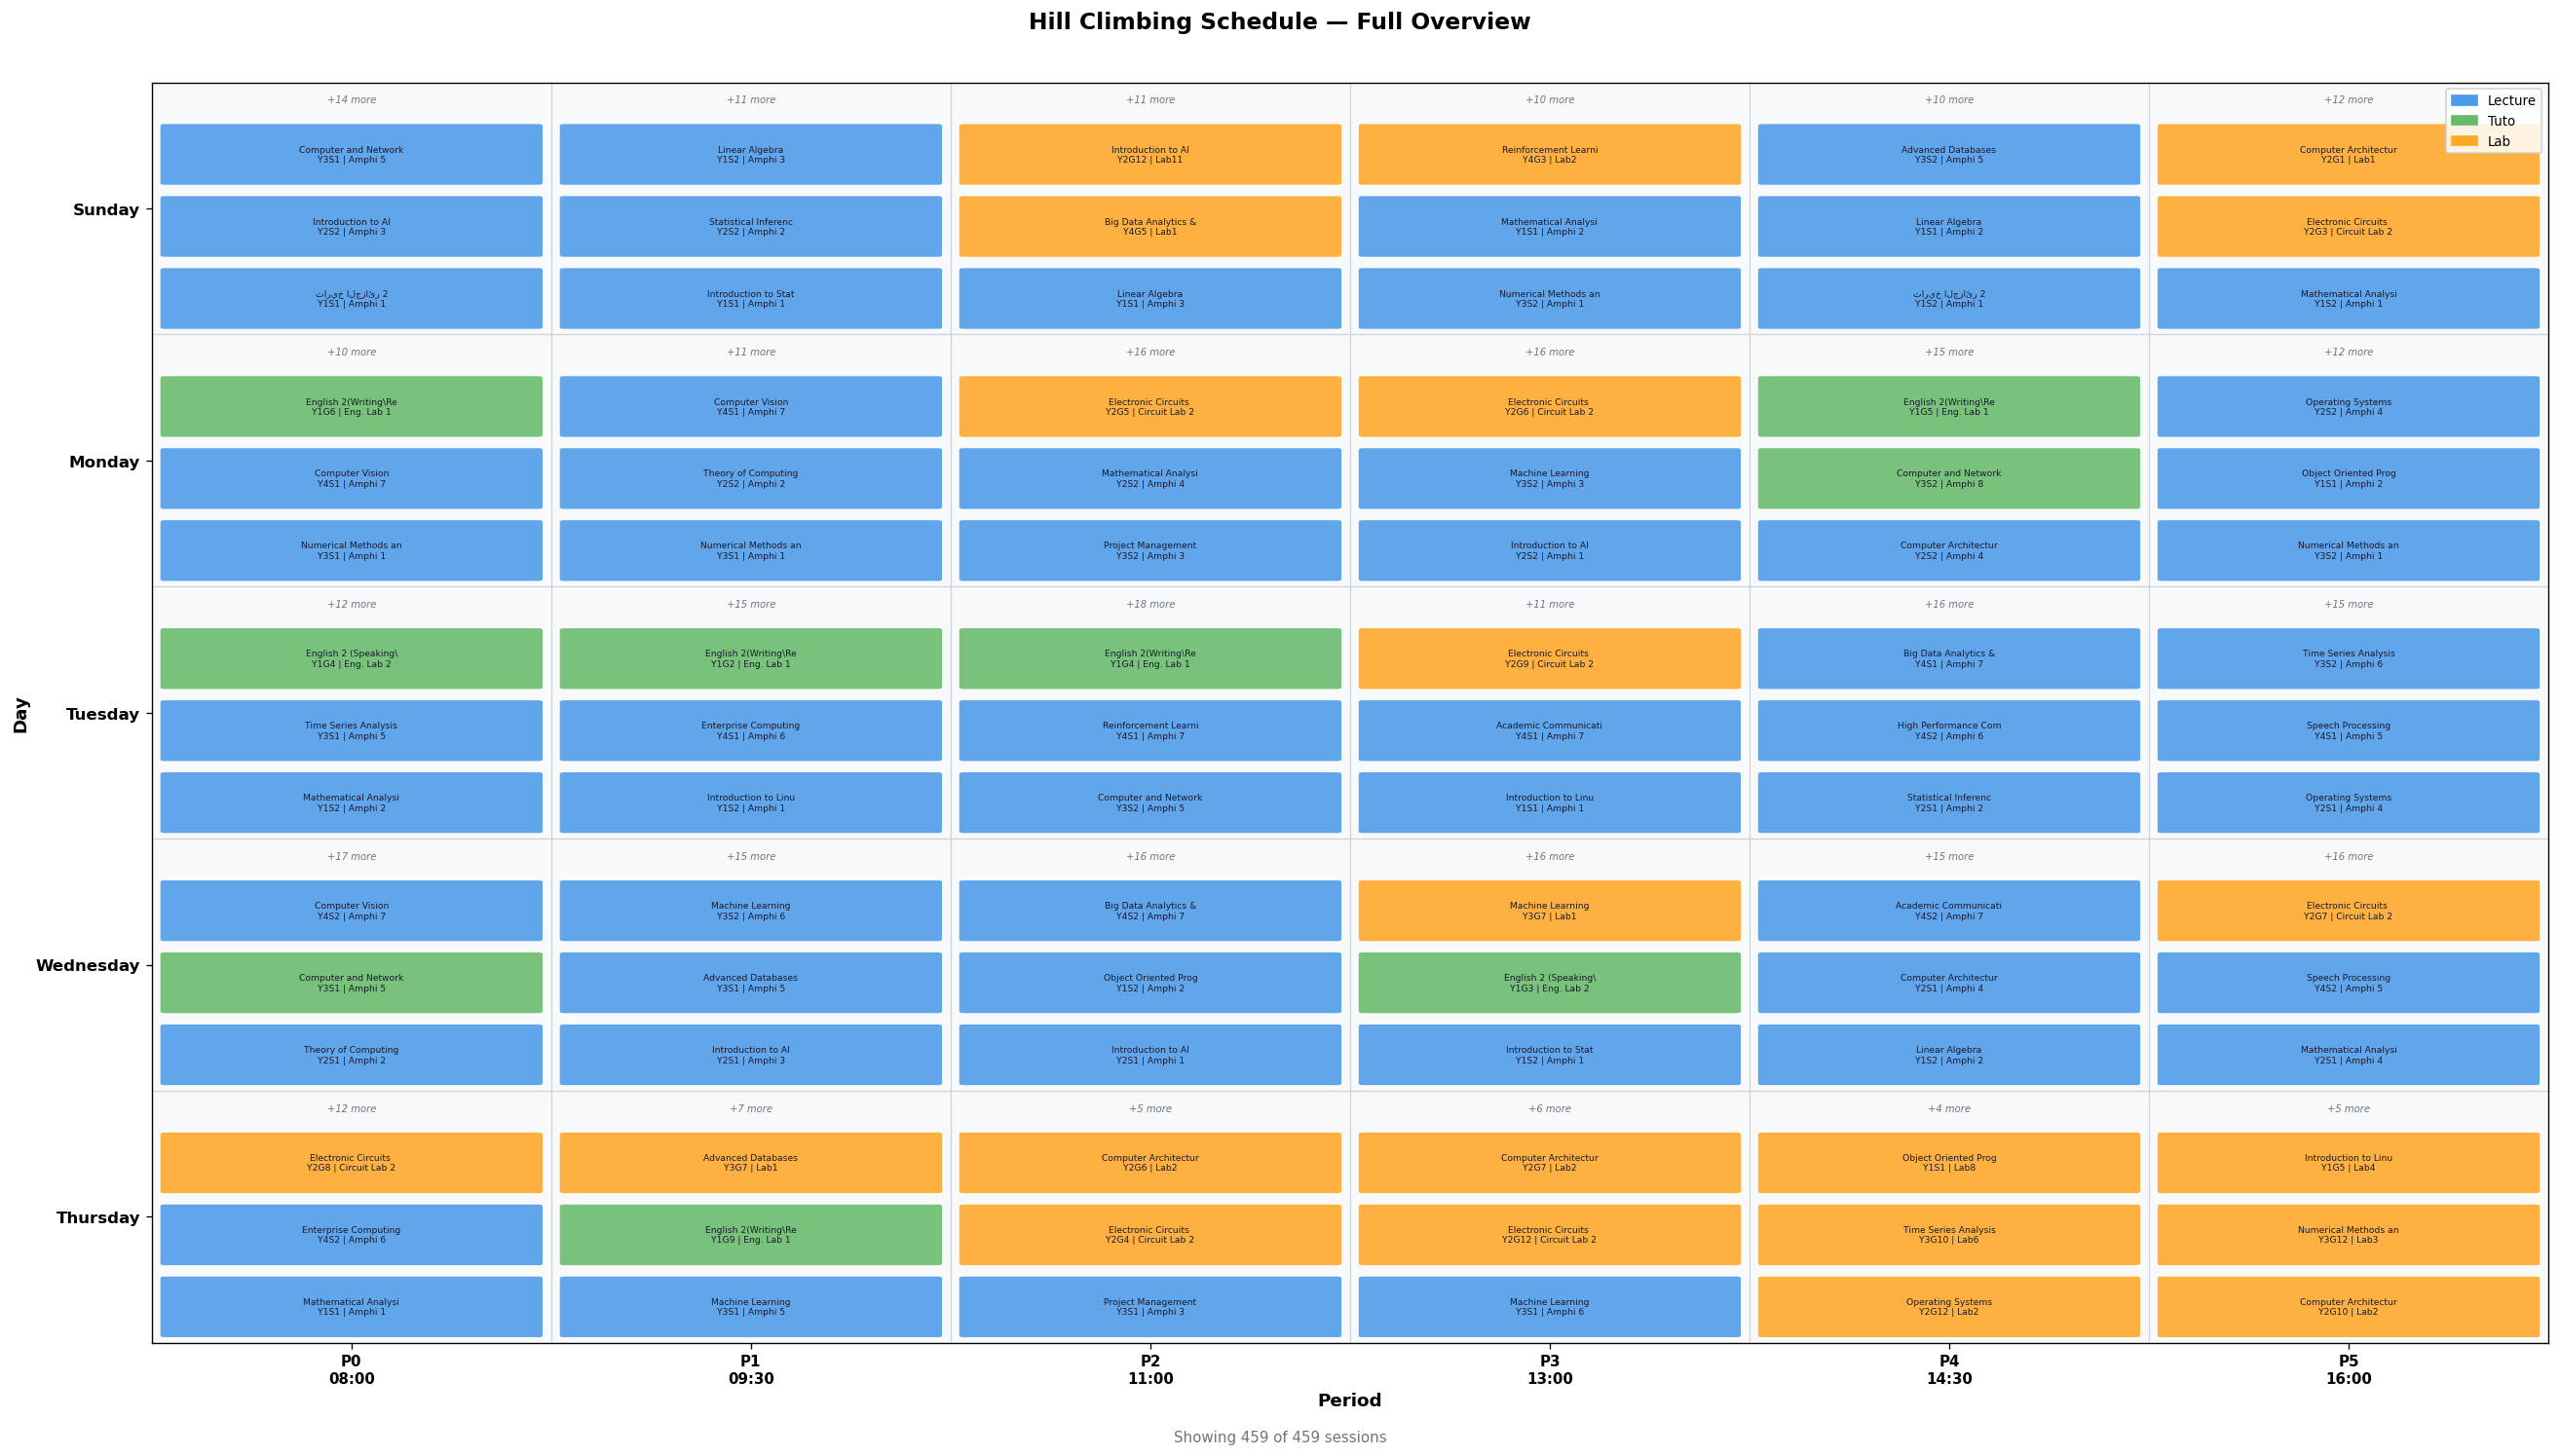

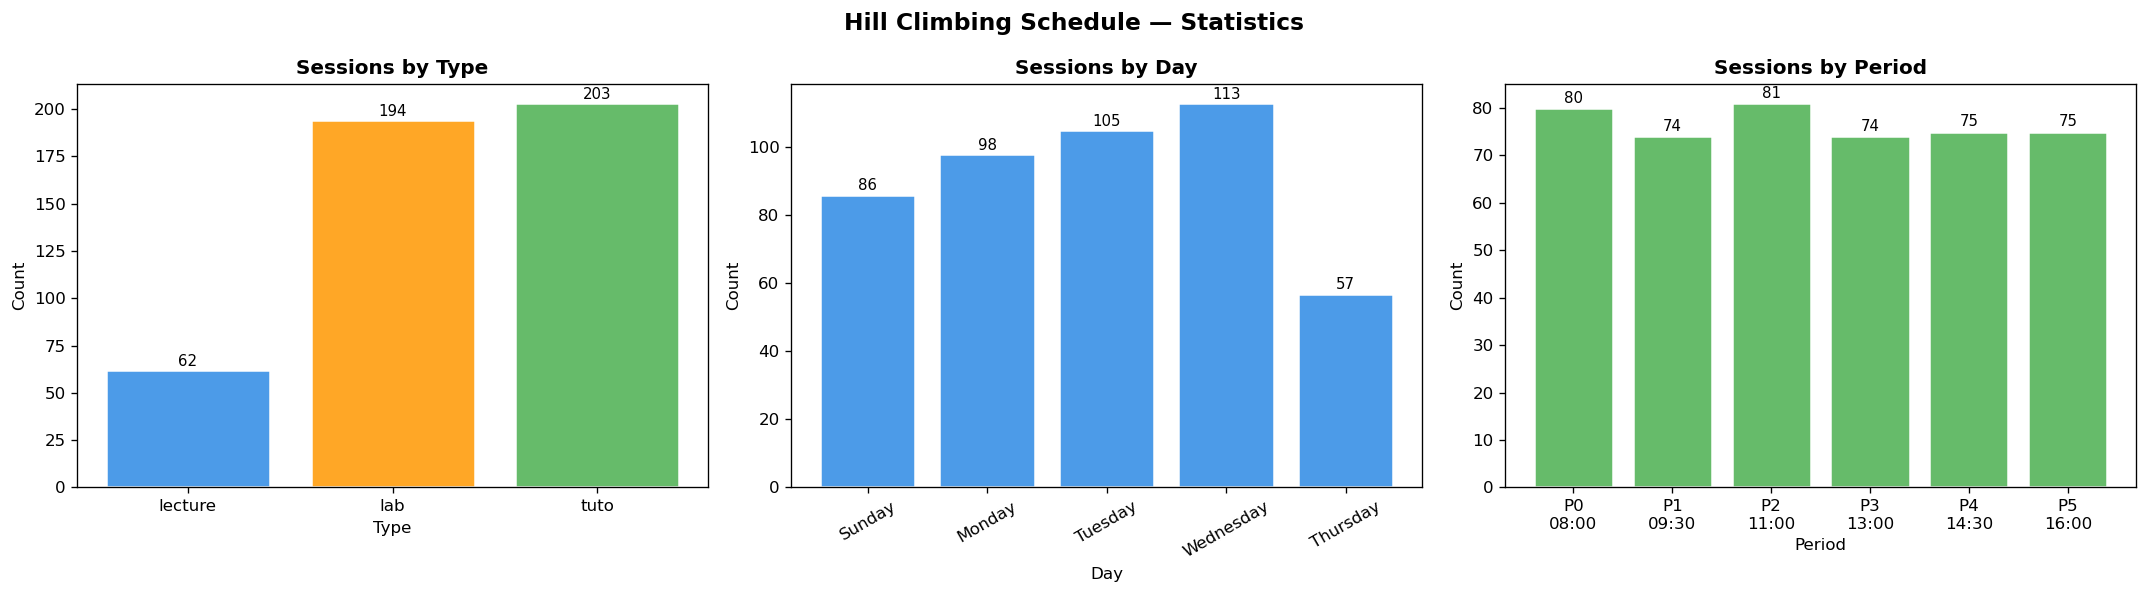

In [49]:
with open(HC_OUTPUT, encoding="utf-8") as f:
    hc_rows = json.load(f)

print("=" * 50)
print("HILL CLIMBING SCHEDULE — Full Overview")
print("=" * 50)
visualize_timetable(hc_rows, title="Hill Climbing Schedule — Full Overview", max_sessions_per_cell=3)
visualize_stats(hc_rows, title="Hill Climbing Schedule — Statistics")

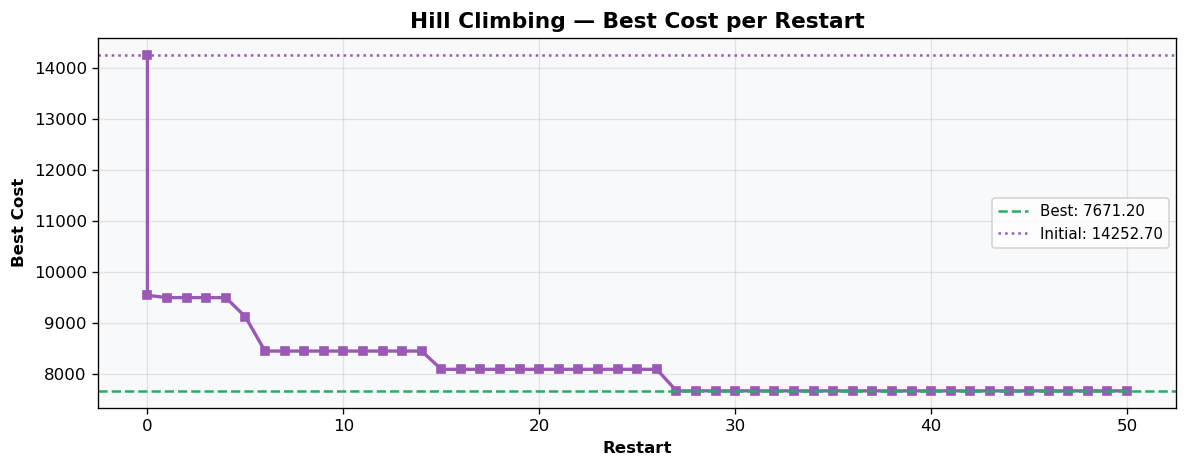

In [50]:
# HC cost convergence across restarts
if hc_cost_history:
    restarts = [h[0] for h in hc_cost_history]
    hc_hist_costs = [h[1] for h in hc_cost_history]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(restarts, hc_hist_costs, color='#9B59B6', linewidth=2, marker='s', markersize=5)
    ax.axhline(hc_hist_costs[-1], color='#27AE60', linestyle='--', linewidth=1.5,
               label=f'Best: {hc_hist_costs[-1]:.2f}')
    ax.axhline(hc_hist_costs[0], color='#9B59B6', linestyle=':', linewidth=1.5,
               label=f'Initial: {hc_hist_costs[0]:.2f}')
    ax.set_xlabel("Restart", fontweight='bold')
    ax.set_ylabel("Best Cost", fontweight='bold')
    ax.set_title("Hill Climbing — Best Cost per Restart", fontweight='bold', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#F8F9FA')
    plt.tight_layout()
    plt.show()

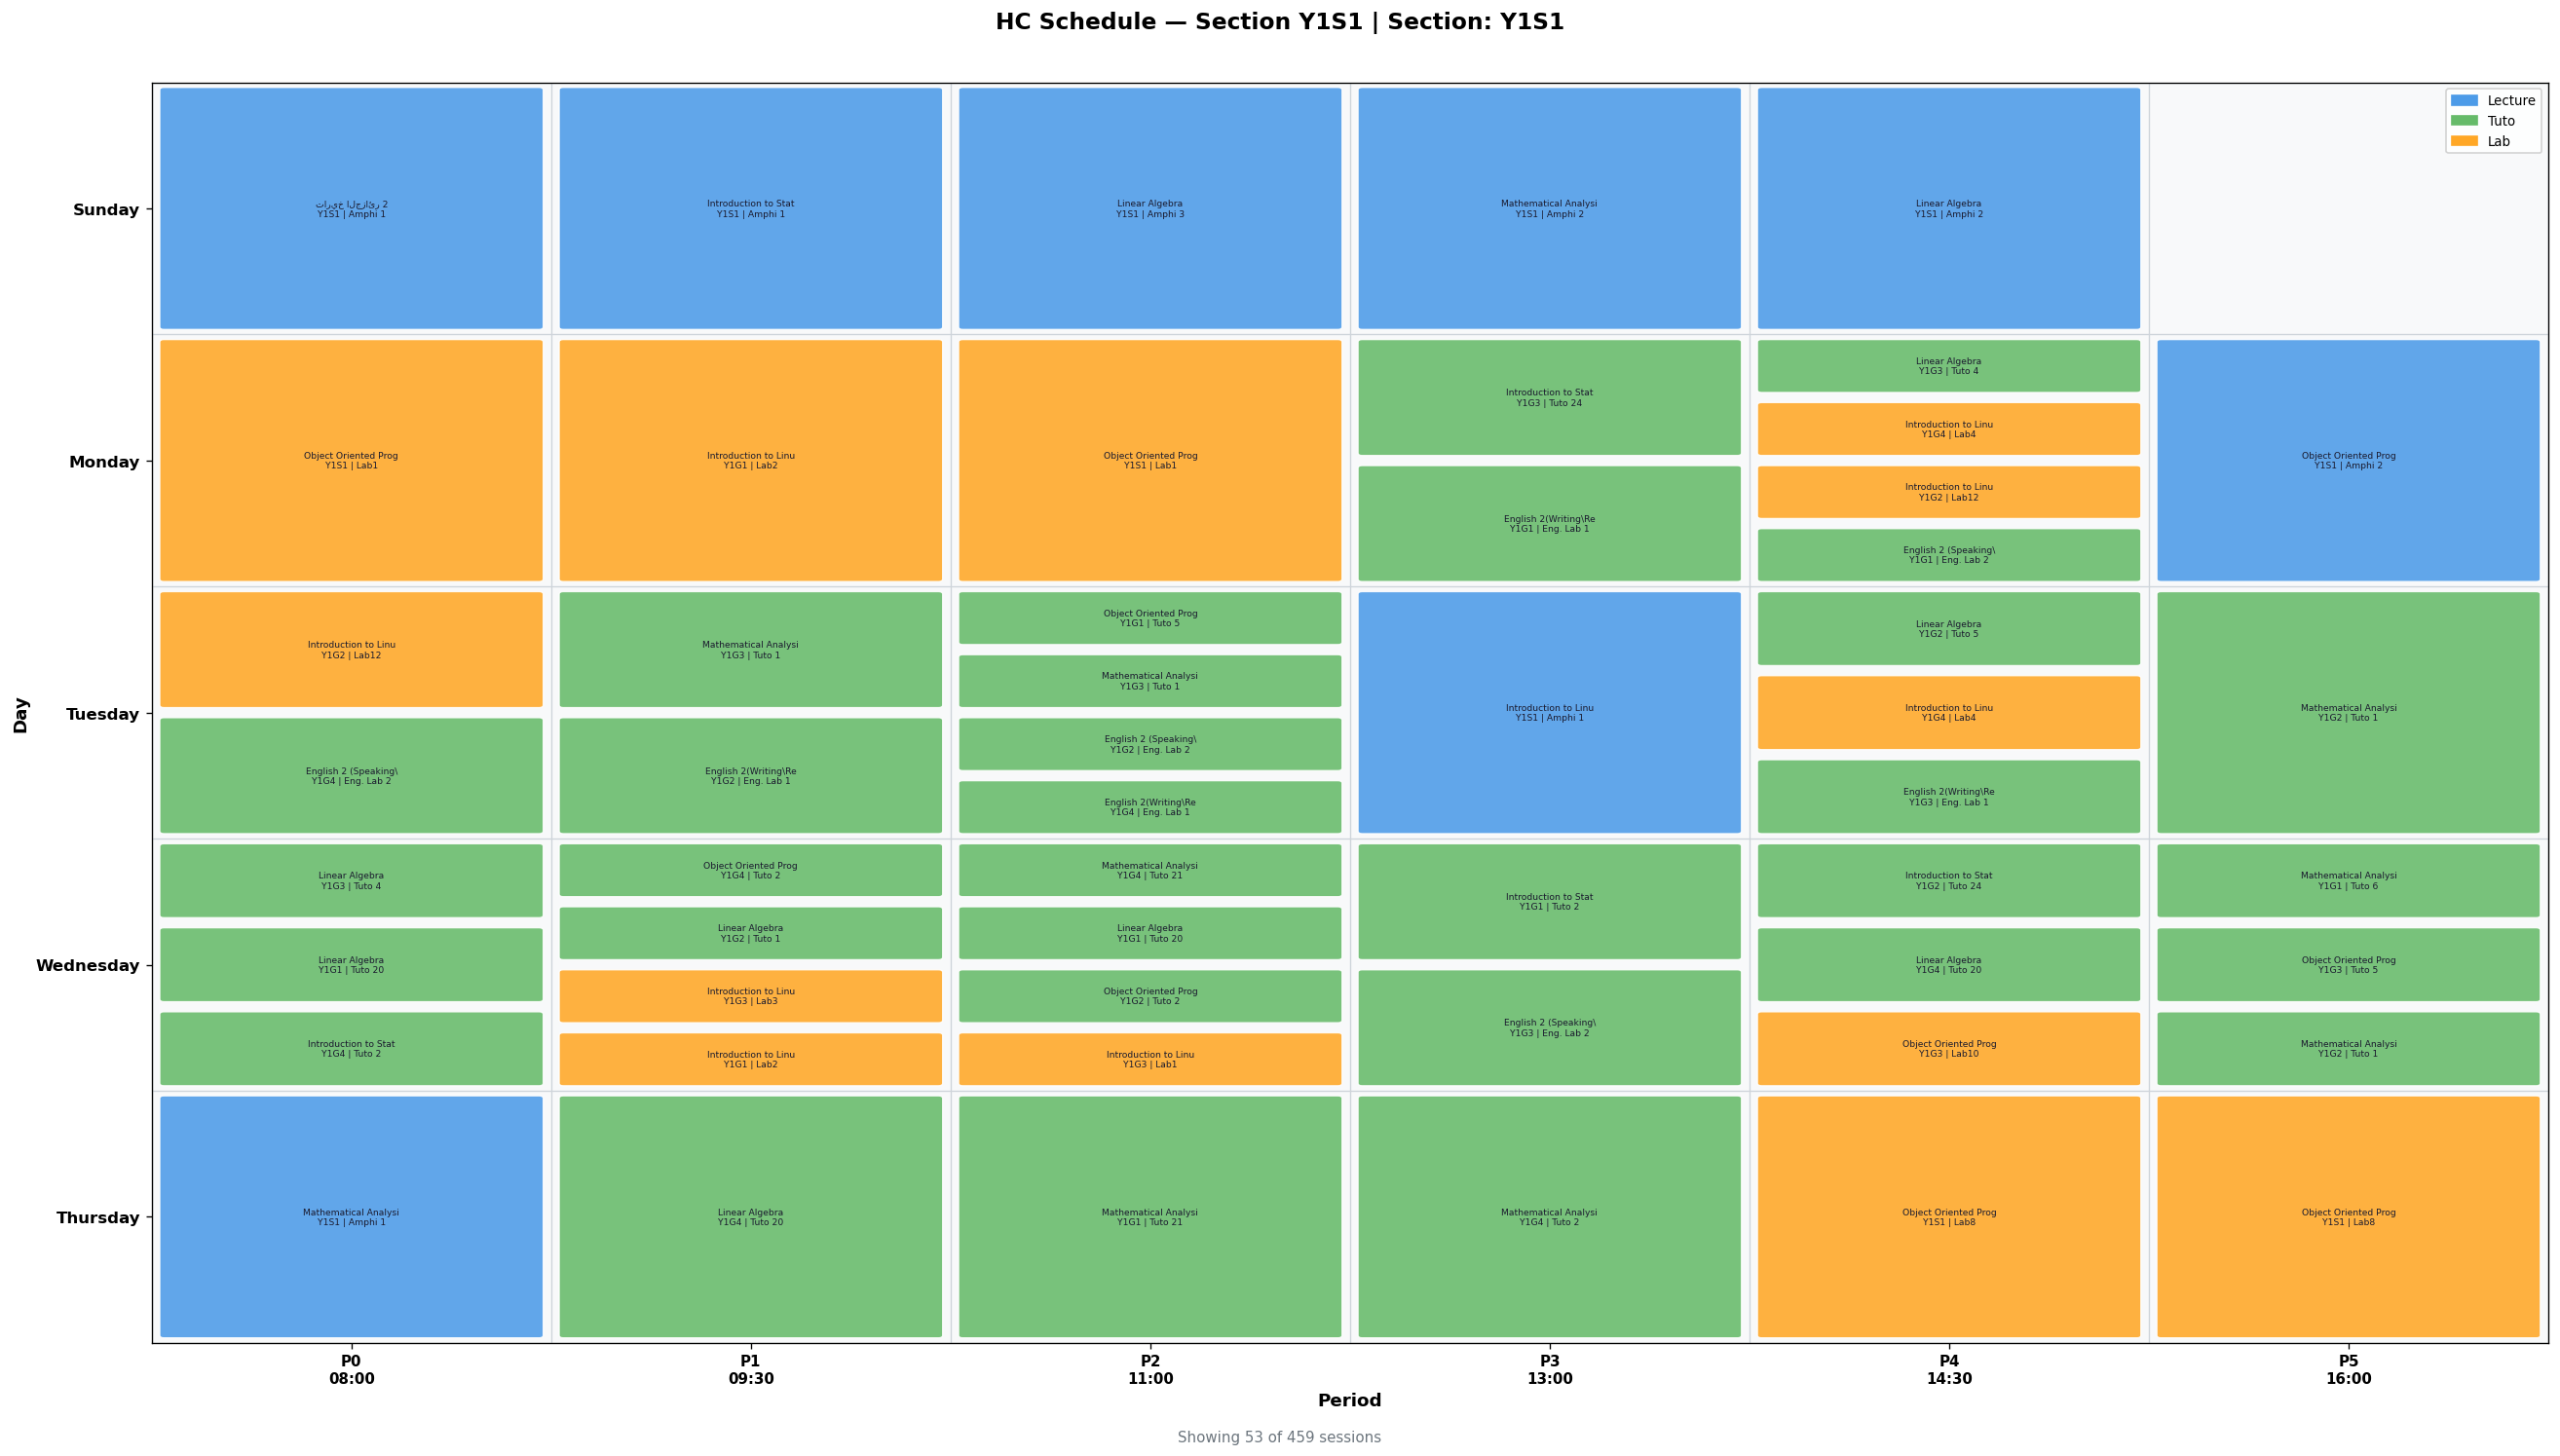

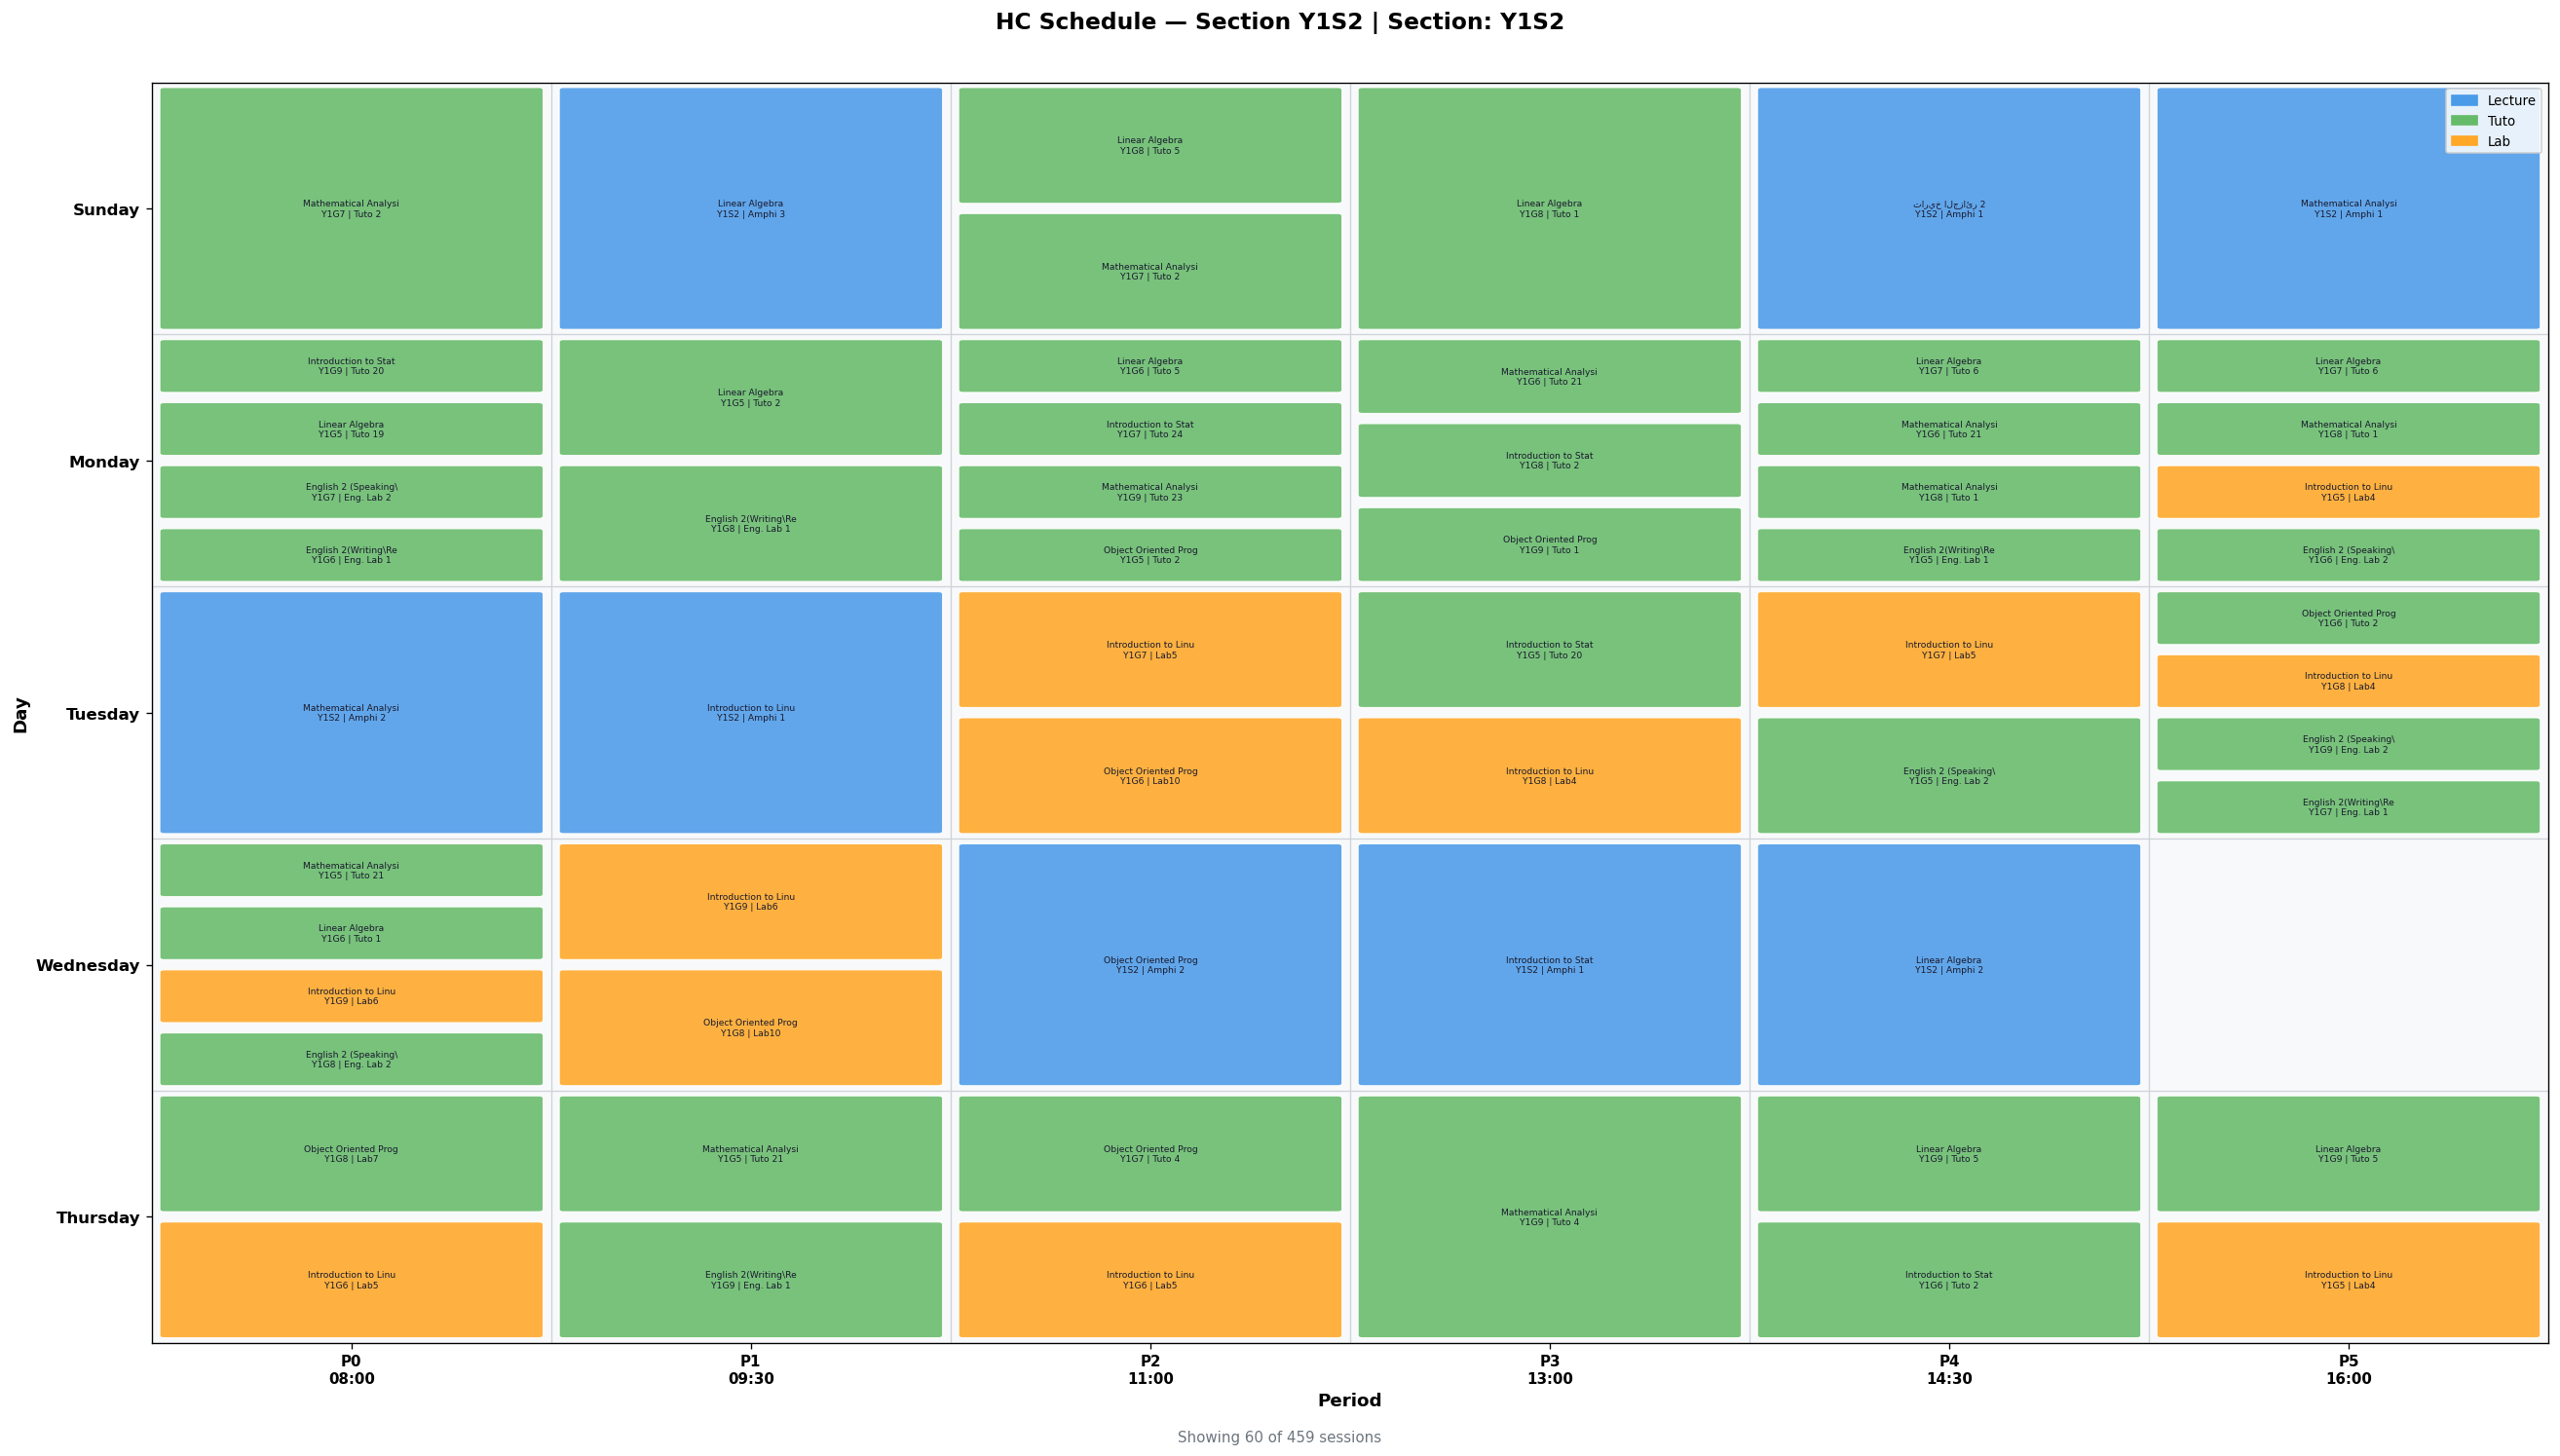

In [51]:
# HC per-section views
for sec in section_ids[:2]:
    visualize_section(hc_rows, sec, title_prefix="HC Schedule")

---
## 🏆 Cell 18 — Three-Way Comparison: CSP vs SA vs Hill Climbing

In [52]:
# ── Gather all breakdowns ──────────────────────────────────────────────
print("=" * 70)
print("THREE-WAY SOFT COST COMPARISON: CSP → SA → Hill Climbing")
print("=" * 70)

def load_and_compute_costs(path, context):
    with open(path, encoding="utf-8") as f:
        rows = json.load(f)
    sections     = sorted(context.section_map.keys())
    groups       = sorted(context.group_map.keys())
    audience_idx = {a: i for i, a in enumerate(sections + groups)}
    n_aud        = len(sections) + len(groups)
    tt = [
        [[(None, None)] * n_aud for _ in range(context.periods_per_day)]
        for _ in range(context.days)
    ]
    for row in rows:
        sid      = row["session_id"]
        sess     = context.session_map.get(sid)
        if sess is None: continue
        audience = sess.group_id if sess.group_id else sess.section_id
        a_idx    = audience_idx.get(audience)
        if a_idx is None: continue
        tt[row["day"]][row["period"]][a_idx] = (row["room"], sid)
    return soft_cost_breakdown(tt, context)

bd_csp = load_and_compute_costs(CSP_OUTPUT, context)
bd_sa  = load_and_compute_costs(SA_OUTPUT,  context)
bd_hc  = load_and_compute_costs(HC_OUTPUT,  context)

print(f"\n{'Component':<26} {'CSP':>12} {'SA':>12} {'HC':>12} {'SA Δ':>10} {'HC Δ':>10}")
print("  " + "─" * 82)

for key in bd_csp:
    v_csp = bd_csp[key]; v_sa = bd_sa[key]; v_hc = bd_hc[key]
    delta_sa = v_sa - v_csp; delta_hc = v_hc - v_csp
    arrow_sa = "▼" if delta_sa < 0 else ("▲" if delta_sa > 0 else "─")
    arrow_hc = "▼" if delta_hc < 0 else ("▲" if delta_hc > 0 else "─")
    bold = "**" if key == "total" else ""
    print(f"  {key:<26} {v_csp:>12.4f} {v_sa:>12.4f} {v_hc:>12.4f} "
          f"{arrow_sa} {abs(delta_sa):>8.4f} {arrow_hc} {abs(delta_hc):>8.4f}")

print()
print(f"Validation summary:")
print(f"  CSP : {'PASS ✅' if csp_validation['passed'] else 'FAIL ❌'} "
      f"({csp_validation['sessions_checked']} sessions, {csp_validation['total_violations']} violations)")
print(f"  SA  : {'PASS ✅' if sa_validation['passed'] else 'FAIL ❌'} "
      f"({sa_validation['sessions_checked']} sessions, {sa_validation['total_violations']} violations)")
print(f"  HC  : {'PASS ✅' if hc_validation['passed'] else 'FAIL ❌'} "
      f"({hc_validation['sessions_checked']} sessions, {hc_validation['total_violations']} violations)")

THREE-WAY SOFT COST COMPARISON: CSP → SA → Hill Climbing

Component                           CSP           SA           HC       SA Δ       HC Δ
  ──────────────────────────────────────────────────────────────────────────────────
  capacity_waste                 202.2000     202.2000     202.2000 ─   0.0000 ─   0.0000
  teacher_room_change           1048.0000     536.0000     952.0000 ▼ 512.0000 ▼  96.0000
  travel_distance              10772.5000    1322.5000    3920.0000 ▼ 9450.0000 ▼ 6852.5000
  compactness                     90.0000     120.0000     315.0000 ▲  30.0000 ▲ 225.0000
  teacher_preference            2140.0000    1230.0000    2030.0000 ▼ 910.0000 ▼ 110.0000
  total                        14252.7000    3410.7000    7419.2000 ▼ 10842.0000 ▼ 6833.5000

Validation summary:
  CSP : PASS ✅ (459 sessions, 0 violations)
  SA  : PASS ✅ (459 sessions, 0 violations)
  HC  : PASS ✅ (459 sessions, 0 violations)


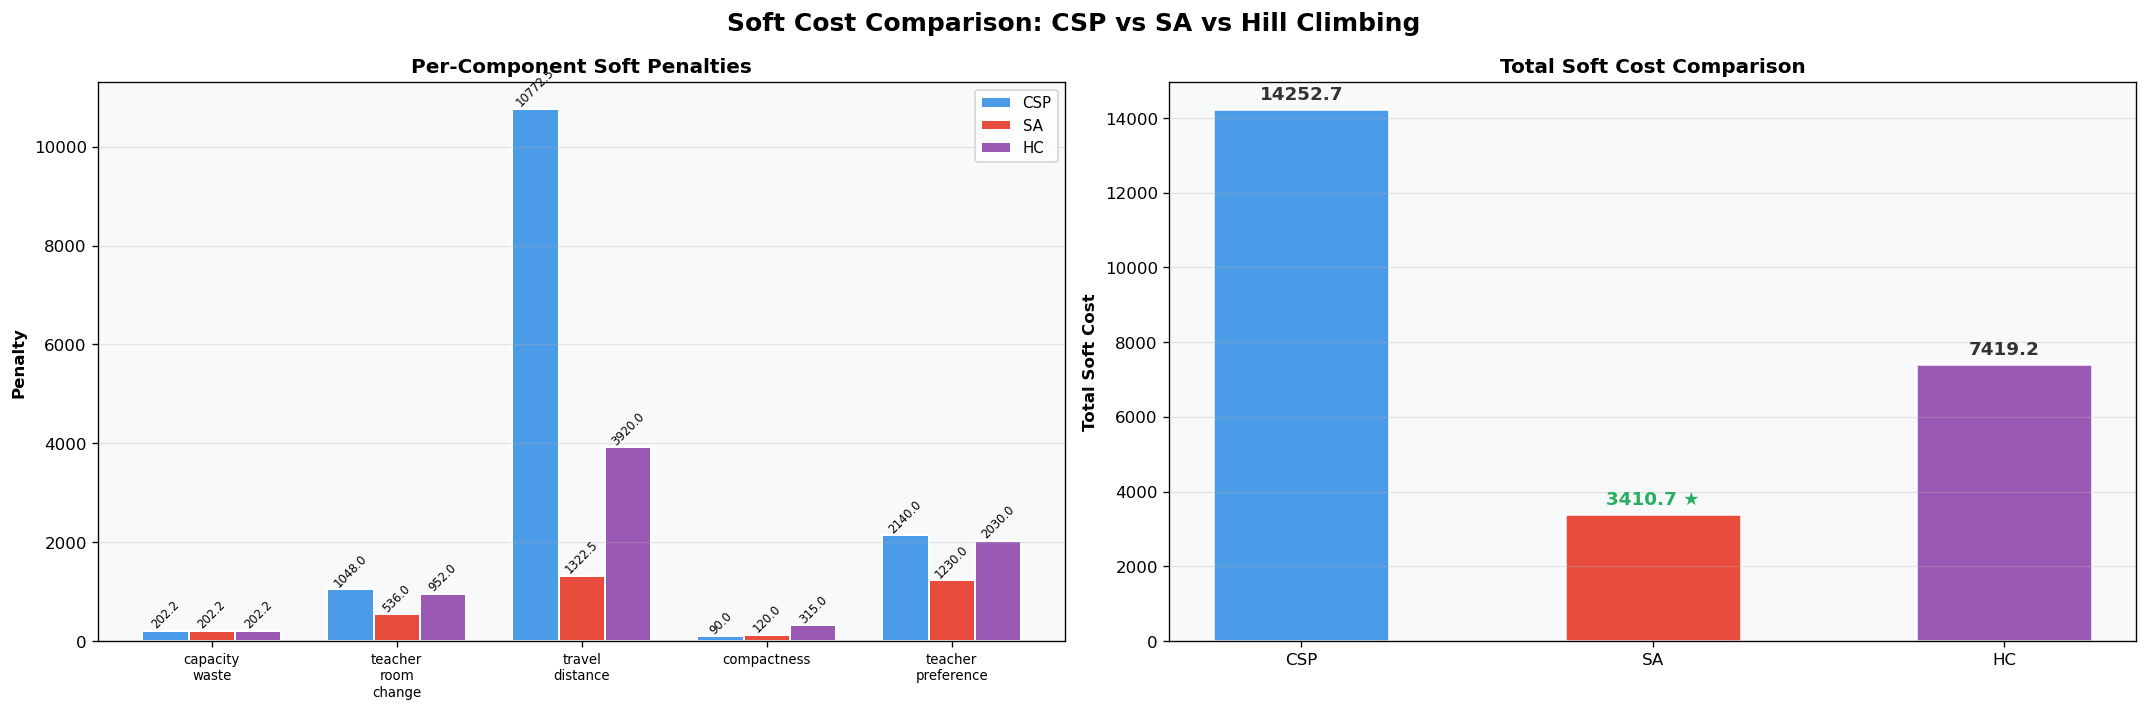


🏆 Best method by total soft cost: SA (3410.7000)
   CSP baseline: 14252.7000
   SA improvement : +10842.0000 (76.1%)
   HC improvement : +6833.5000 (47.9%)


In [53]:
# ── Visual comparison charts ───────────────────────────────────────────
components = [k for k in bd_csp.keys() if k != 'total']
x          = np.arange(len(components))
width      = 0.25

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Soft Cost Comparison: CSP vs SA vs Hill Climbing",
             fontsize=15, fontweight='bold')

# ── Left: grouped bar chart ────────────────────────────────────────────
ax = axes[0]
vals_csp = [bd_csp[k] for k in components]
vals_sa  = [bd_sa[k]  for k in components]
vals_hc  = [bd_hc[k]  for k in components]

bars1 = ax.bar(x - width, vals_csp, width, label="CSP", color="#4C9BE8",
               edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x,          vals_sa,  width, label="SA",  color="#E74C3C",
               edgecolor='white', linewidth=1.2)
bars3 = ax.bar(x + width, vals_hc,  width, label="HC",  color="#9B59B6",
               edgecolor='white', linewidth=1.2)

ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', '\n') for c in components], fontsize=8)
ax.set_ylabel("Penalty", fontweight='bold')
ax.set_title("Per-Component Soft Penalties", fontweight='bold')
ax.legend(fontsize=9)
ax.set_facecolor('#F8F9FA')
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                    f'{h:.1f}', ha='center', va='bottom', fontsize=7, rotation=45)

# ── Right: total cost pie/bar ──────────────────────────────────────────
ax = axes[1]
labels = ["CSP", "SA", "HC"]
totals = [bd_csp['total'], bd_sa['total'], bd_hc['total']]
colors = ["#4C9BE8", "#E74C3C", "#9B59B6"]

bars = ax.bar(labels, totals, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
ax.set_ylabel("Total Soft Cost", fontweight='bold')
ax.set_title("Total Soft Cost Comparison", fontweight='bold')
ax.set_facecolor('#F8F9FA')
ax.grid(axis='y', alpha=0.3)

best_total = min(totals)
for bar, val, label in zip(bars, totals, labels):
    colour = '#27AE60' if val == best_total else '#333333'
    star   = " ★" if val == best_total else ""
    ax.text(bar.get_x() + bar.get_width()/2, val + max(totals)*0.01,
            f"{val:.1f}{star}", ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=colour)

plt.tight_layout()
plt.show()

# Summary
best_method = labels[totals.index(min(totals))]
print(f"\n🏆 Best method by total soft cost: {best_method} ({min(totals):.4f})")
print(f"   CSP baseline: {totals[0]:.4f}")
print(f"   SA improvement : {totals[0] - totals[1]:+.4f} ({100*(totals[0]-totals[1])/max(totals[0],1e-9):.1f}%)")
print(f"   HC improvement : {totals[0] - totals[2]:+.4f} ({100*(totals[0]-totals[2])/max(totals[0],1e-9):.1f}%)")

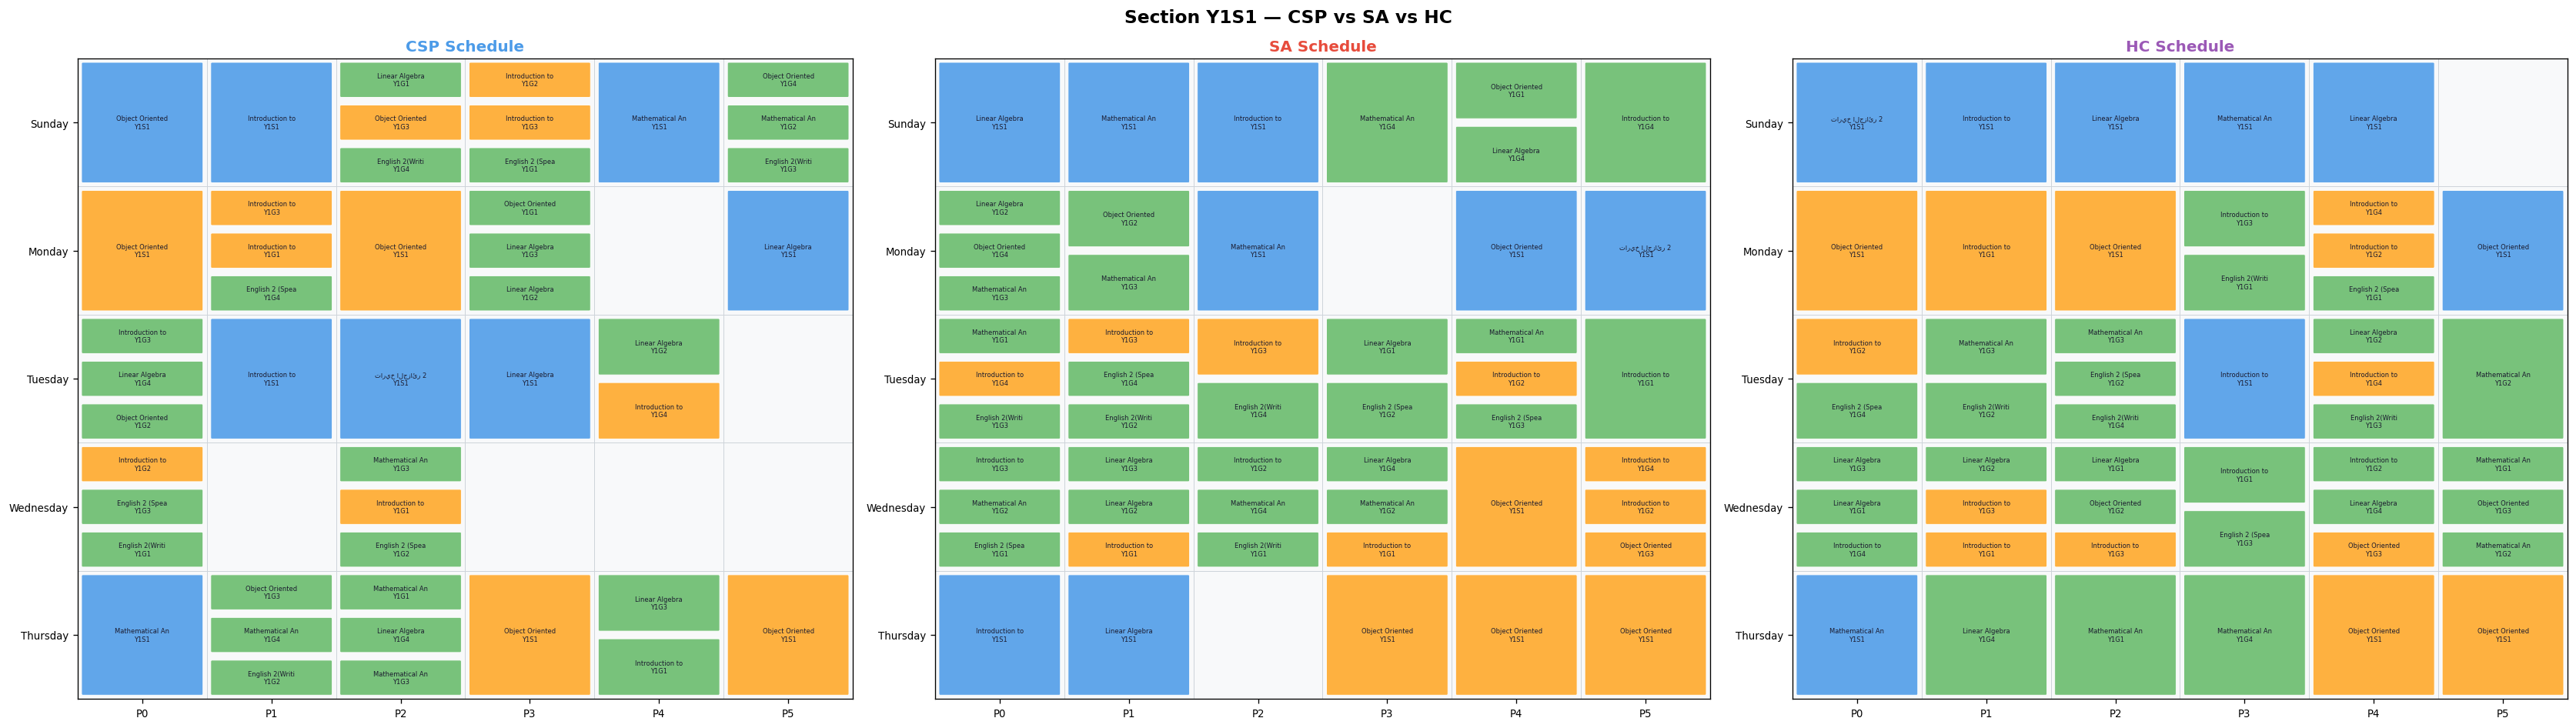

In [54]:
# ── Side-by-side timetable comparison for one section ─────────────────
compare_section = section_ids[0] if section_ids else None

if compare_section:
    fig, axes = plt.subplots(1, 3, figsize=(28, 8))
    fig.suptitle(f"Section {compare_section} — CSP vs SA vs HC",
                 fontsize=14, fontweight='bold')

    datasets = [
        (csp_rows, "CSP Schedule", "#4C9BE8"),
        (sa_rows,  "SA Schedule",  "#E74C3C"),
        (hc_rows,  "HC Schedule",  "#9B59B6"),
    ]

    for (rows, title, accent_color), ax in zip(datasets, axes):
        filtered = [r for r in rows if r.get("section") == compare_section]
        grid = _sessions_by_slot(filtered)
        n_per = 6; n_days = 5

        ax.set_xlim(0, n_per); ax.set_ylim(0, n_days)
        ax.set_facecolor("#F8F9FA")
        ax.set_xticks([i + 0.5 for i in range(n_per)])
        ax.set_xticklabels([f"P{i}" for i in range(n_per)], fontsize=8)
        ax.set_yticks([i + 0.5 for i in range(n_days)])
        ax.set_yticklabels(list(reversed(DAY_NAMES)), fontsize=8)
        ax.set_title(title, fontweight='bold', color=accent_color, fontsize=12)

        for x in range(n_per + 1): ax.axvline(x, color='#CED4DA', linewidth=0.6)
        for y in range(n_days + 1): ax.axhline(y, color='#CED4DA', linewidth=0.6)

        for day in range(n_days):
            row_y = n_days - 1 - day
            for p in range(n_per):
                cell_sessions = grid.get((day, p), [])
                if not cell_sessions: continue
                n_show = min(len(cell_sessions), 3)
                h = 1.0 / n_show
                for j, sess in enumerate(cell_sessions[:n_show]):
                    stype = sess.get("type", "lecture")
                    color = TYPE_COLORS.get(stype, DEFAULT_COLOR)
                    rect  = mpatches.FancyBboxPatch(
                        (p + 0.04, row_y + j * h + 0.04), 0.92, h - 0.08,
                        boxstyle="round,pad=0.01",
                        facecolor=color, edgecolor='white', linewidth=0.6, alpha=0.88,
                    )
                    ax.add_patch(rect)
                    module   = str(sess.get("module", ""))[:15]
                    audience = sess.get("group") or sess.get("section") or ""
                    ax.text(
                        p + 0.5, row_y + j * h + h / 2,
                        f"{module}\n{audience}",
                        ha='center', va='center', fontsize=5, color='#1a1a2e',
                    )

    plt.tight_layout()
    plt.show()

---
## 📁 Cell 19 — Output File Summary

In [55]:
import os

print("=" * 60)
print("OUTPUT FILES SUMMARY")
print("=" * 60)

outputs = [
    (CSP_OUTPUT, "CSP Solver Output",       csp_validation),
    (SA_OUTPUT,  "SA Optimizer Output",     sa_validation),
    (HC_OUTPUT,  "Hill Climbing Output",    hc_validation),
]

for path, label, val in outputs:
    exists = Path(path).exists()
    size   = f"{os.path.getsize(path) / 1024:.1f} KB" if exists else "N/A"
    status = '✅ PASS' if val['passed'] else '❌ FAIL'
    print(f"  {label:<30} : {path:<35} [{size}]  Hard constraints: {status}")

print()
print("Soft cost summary:")
print(f"  {'Method':<15} {'Total Cost':>12}")
print(f"  {'─'*30}")
print(f"  {'CSP':<15} {bd_csp['total']:>12.4f}")
print(f"  {'SA':<15} {bd_sa['total']:>12.4f}")
print(f"  {'Hill Climbing':<15} {bd_hc['total']:>12.4f}")
print()
print("Pipeline complete! 🎉")

OUTPUT FILES SUMMARY
  CSP Solver Output              : schedule_output.json                [133.3 KB]  Hard constraints: ✅ PASS
  SA Optimizer Output            : schedule_sa_output.json             [133.4 KB]  Hard constraints: ✅ PASS
  Hill Climbing Output           : hc_schedule_output.json             [133.5 KB]  Hard constraints: ✅ PASS

Soft cost summary:
  Method            Total Cost
  ──────────────────────────────
  CSP               14252.7000
  SA                 3410.7000
  Hill Climbing      7419.2000

Pipeline complete! 🎉
